# Abschnitt 1: Entwicklung des Modells

In [104]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split  
from sklearn.compose import ColumnTransformer  
from sklearn.preprocessing import OneHotEncoder  
from sklearn.preprocessing import StandardScaler  
from sklearn.pipeline import Pipeline 
from sklearn.metrics import accuracy_score  
from sklearn.metrics import classification_report  
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import recall_score, accuracy_score, precision_score, fbeta_score
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import NearestNeighbors
from lime.lime_tabular import LimeTabularExplainer
#!pip install lime

## Datenimport und erste Exploration

### Bedeutung der Merkmale im Datensatz

Zur besseren Einordnung der Variablen im Heart-Disease-Datensatz folgt eine kurze inhaltliche Erklärung der Features:

| Merkmal | Bedeutung |
|---------|-----------|
| **Age** | Alter des Patienten (in Jahren). |
| **Sex** | Geschlecht (z.B. M/F). |
| **ChestPainType** | Art des Brustschmerzes (*Chest Pain Type*); 4 Ausprägungen (z.B. ASY = asymptomatisch, ATA = atypisch, NAP = nicht-anginal, TA = typisch anginal). |
| **RestingBP** | Ruhe-Blutdruck (*Resting Blood Pressure*) in mmHg. |
| **Cholesterol** | Serum-Cholesterin in mg/dl. |
| **FastingBS** | Nüchtern-Blutzucker (*Fasting Blood Sugar*): 1 = > 120 mg/dl, 0 = sonst. |
| **RestingECG** | Ruhe-EKG (*Resting Electrocardiographic Results*); Werte z.B. Normal, ST, LVH. |
| **MaxHR** | Maximal erreichte Herzfrequenz (*Maximum Heart Rate Achieved*) unter Belastung. |
| **ExerciseAngina** | Belastungsangina (*Exercise Induced Angina*): ja/nein. |
| **Oldpeak** | ST-Senkung (*ST depression*) unter Belastung im Vergleich zu Ruhe (*Oldpeak = ST depression induced by exercise relative to rest*). |
| **ST_Slope** | Steigung der ST-Strecke bei maximaler Belastung (*Slope of the peak exercise ST segment*), z.B. Up, Flat, Down. |
| **HeartDisease** | Zielvariable: 1 = Herzerkrankung, 0 = keine Herzerkrankung. |


In [105]:
df = pd.read_csv("heart.csv")
df.head()

# Print dataset shape (rows, columns)
print("Dataset shape:", df.shape)

# Show information about column types and non-null counts
df.info()

# Print missing values for each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Set the target variable for classification
target = "HeartDisease"  # 1 = disease present, 0 = no disease

# Check uniqueness of the target values
print("\nTarget variable selected:", target)
print("Unique values in target:", df[target].unique())

Dataset shape: (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR    

**Beobachtung:**
- Ausgabe der Datensatzgröße zur Einordnung des Umfangs (918 Beobachtungen, 12 Merkmale)
- Überprüfung der Datentypen und Nicht-Null-Werte aller Spalten zur Identifikation numerischer und kategorialer Features
- Analyse auf fehlende Werte zeigt, dass der Datensatz vollständig ist (keine Missing Values)
- Festlegung der Zielvariable `HeartDisease` für die binäre Klassifikation (0 = keine Erkrankung, 1 = Erkrankung vorhanden)
- Kontrolle der Zielvariable bestätigt ein binäres Klassifikationsproblem mit zwei Ausprägungen (0 und 1)

**Konsequenz:**  
Der Datensatz ist vollständig, sauber und direkt für die weitere Modellierung geeignet; eine Vorverarbeitung für fehlende Werte ist nicht erforderlich.


###

In [106]:
# Separate input features (X) and target labels (y)
X = df.drop(columns=[target])  # X = all columns except HeartDisease
y = df[target]                 # y = the HeartDisease column only

# Show basic information about the target distribution (class balance)
print("Target value counts (0 = no disease, 1 = disease):")
print(y.value_counts())

# Automatically detect numeric feature columns (int or float)
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Automatically detect categorical feature columns (non-numeric types)
categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("\nNumeric feature columns:")
print(numeric_features)

print("\nCategorical feature columns:")
print(categorical_features)

Target value counts (0 = no disease, 1 = disease):
HeartDisease
1    508
0    410
Name: count, dtype: int64

Numeric feature columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical feature columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


**Beobachtung:**
- Trennung des Datensatzes in Eingangsmerkmale (`X`) und Zielvariable (`y`), wobei `HeartDisease` als Target definiert ist.
- Auszählung der Zielklassen ergibt 508 Fälle mit Herzkrankheit (1) und 410 Fälle ohne Herzkrankheit (0).
- Die Klassenverteilung ist leicht unausgewogen, jedoch ohne starke Dominanz einer Klasse.
- Numerische Features werden automatisch über ihre Datentypen identifiziert.
- Kategoriale Features werden automatisch über nicht-numerische Datentypen identifiziert.

**Konsequenz:**
- Es liegt eine moderate Klassenbalance vor. Ein explizites Over- oder Undersampling ist nicht zwingend erforderlich.
- Beim Train-Test-Split sollte eine Stratifizierung verwendet werden, um die Klassenverteilung beizubehalten.
- Die klare Trennung in numerische und kategoriale Features ermöglicht ein strukturiertes Preprocessing (z. B. Skalierung vs. Encoding) in späteren Modellpipelines.



## Train-, Validierungs- und Test-Split

In [107]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,      # 15% for final test
    random_state=42,
    stratify=y           # keep 0/1 ratio consistent
)

validation_ratio = 0.15 / 0.85  # ~0.17647

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=validation_ratio,  # produces 15% overall validation
    random_state=42,
    stratify=y_temp
)

# Print out the sizes to confirm 70/15/15 split
print("Train set size:     ", X_train.shape[0], "rows")
print("Validation set size:", X_val.shape[0], "rows")
print("Test set size:      ", X_test.shape[0], "rows")

# Print percentages
total = len(df)
print("\nPercentage breakdown:")
print("Train:      ", round(X_train.shape[0] / total * 100, 2), "%")
print("Validation: ", round(X_val.shape[0] / total * 100, 2), "%")
print("Test:       ", round(X_test.shape[0] / total * 100, 2), "%")

Train set size:      642 rows
Validation set size: 138 rows
Test set size:       138 rows

Percentage breakdown:
Train:       69.93 %
Validation:  15.03 %
Test:        15.03 %


**Beobachtung:**
- In beiden Split-Schritten wird `stratify` verwendet, um die Klassenverteilung beizubehalten.
- Die resultierende Aufteilung beträgt ca. 70 % Training, 15 % Validierung und 15 % Test.

**Konsequenz:**
- Saubere und faire Modellbewertung durch klar getrennte, stratifizierte Datenaufteilung ohne Informationsleckage.



## Preprocessing: One-Hot-Encoding und Feature-Zusammenführung

In [108]:
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False  # Wichtig: False, damit wir eine lesbare Tabelle (Matrix) bekommen
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features), 
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False # Sorgt für schönere Namen ohne "num__" oder "cat__" Präfix
)


# fit() darf NUR auf X_train passieren
# Lernen (fit) und Anwenden (transform) auf Trainingsdaten
X_train_np = preprocessor.fit_transform(X_train)

# Nur Anwenden (transform) auf Validierungsdaten (nichts neues lernen)
X_val_np = preprocessor.transform(X_val)

# Nur Anwenden (transform) auf Testdaten
X_test_np = preprocessor.transform(X_test)

# Holen Feature-Namen der neuen Spalten direkt aus dem Preprocessor
feature_names = preprocessor.get_feature_names_out()


X_train_processed = pd.DataFrame(X_train_np, columns=feature_names, index=X_train.index)
X_val_processed = pd.DataFrame(X_val_np, columns=feature_names, index=X_val.index)
X_test_processed = pd.DataFrame(X_test_np, columns=feature_names, index=X_test.index)

print(f"Neue Anzahl Features nach Preprocessing: {X_train_processed.shape[1]}")
print("\nSo sehen die Daten jetzt aus (erste 3 Zeilen X_train_processed):")
display(X_train_processed.head(3))

Neue Anzahl Features nach Preprocessing: 20

So sehen die Daten jetzt aus (erste 3 Zeilen X_train_processed):


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
43,52.0,140.0,259.0,0.0,170.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
760,53.0,123.0,282.0,0.0,95.0,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
255,53.0,120.0,274.0,0.0,130.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


**Beobachtung:**
- Für kategoriale Features wird ein `OneHotEncoder` verwendet, der unbekannte Kategorien ignoriert.
- Das Encoding wird so konfiguriert, dass eine dichte Matrix (`sparse_output=False`) erzeugt wird.
- Numerische Features werden unverändert durchgereicht (`passthrough`).
- Beide Feature-Typen werden über einen `ColumnTransformer` zu einer gemeinsamen Feature-Matrix kombiniert.
- Der Preprocessor wird ausschließlich auf den Trainingsdaten gefittet und anschließend auf Validierungs- und Testdaten angewendet.
- Nach dem Preprocessing steigt die Anzahl der Features von ursprünglich 11 auf 20.
- Die transformierten Daten werden wieder in Pandas DataFrames mit sprechenden Feature-Namen überführt.

**Konsequenz:**
- Alle kategorialen Variablen liegen nun in numerischer Form vor und sind modellkompatibel.
- Durch das Fitten nur auf den Trainingsdaten wird Data Leakage vermieden.
- Einheitliche Feature-Strukturen in Train-, Validierungs- und Testset ermöglichen eine konsistente Modellierung.
- Die expliziten Feature-Namen bilden eine wichtige Grundlage für spätere Interpretierbarkeit und XAI-Analysen.


## Training eines Random-Forest-Modells

In [109]:
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None,   # Die Bäume wachsen, bis alle Blätter rein sind
    random_state=40,
    n_jobs=-1         # Nutzt alle verfügbaren CPU-Kerne für schnelleres Training
)

# Wir nutzen weiterhin die vorverarbeiteten Daten (X_train_processed)
rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(n_jobs=-1, random_state=40)

**Beobachtung:**
- Initialisierung eines `RandomForestClassifier` mit 100 Entscheidungsbäumen.
- Ein fester `random_state` wird verwendet, um Reproduzierbarkeit sicherzustellen.
- Das Modell wird auf den vollständig vorverarbeiteten Trainingsdaten (`X_train_processed`) trainiert.

**Konsequenz:**
- Modell, welches komplexe, nichtlineare Zusammenhänge in den Daten lernen kann.

## Validierung mit Fokus auf F2-Score

In [110]:
y_val_pred = rf_model.predict(X_val_processed)

# Metriken mit Fokus auf F2-Score (positve Klasse = 1)
recall = recall_score(y_val, y_val_pred, pos_label=1)
precision = precision_score(y_val, y_val_pred, pos_label=1)
accuracy = accuracy_score(y_val, y_val_pred)
f2 = fbeta_score(y_val, y_val_pred, beta=2, pos_label=1)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Precision (pos=1): {precision:.4f}")
print(f"Validation Recall (pos=1): {recall:.4f}")
print(f"Validation F2-Score (pos=1): {f2:.4f}")

Validation Accuracy: 0.8478
Validation Precision (pos=1): 0.8571
Validation Recall (pos=1): 0.8684
Validation F2-Score (pos=1): 0.8661


**Beobachtung:**
- Das Random-Forest-Modell wird auf dem Validierungsdatensatz ausgewertet.
- Precision und Recall für die positive Klasse (HeartDisease = 1) sind identisch und hoch.
- Der F2-Score entspricht dem Wert von Precision und Recall.
- Accuracy liegt bei ca. 0.86.

**Konsequenz:**
- Das Modell erkennt einen Großteil der tatsächlich erkrankten Personen zuverlässig.
- Der hohe F2-Score bestätigt eine gute Performance unter stärkerer Gewichtung des Recall.

## Evaluation auf dem Testdatensatz mit Fokus auf F2-Score

In [111]:
y_test_pred = rf_model.predict(X_test_processed)

# Metriken mit Fokus auf F2-Score (positive Klasse = 1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2, pos_label=1)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision (pos=1): {test_precision:.4f}")
print(f"Test Recall (pos=1): {test_recall:.4f}")
print(f"Test F2-Score (pos=1): {test_f2:.4f}")

Test Accuracy: 0.8986
Test Precision (pos=1): 0.8974
Test Recall (pos=1): 0.9211
Test F2-Score (pos=1): 0.9162


**Beobachtung:**
- Das Random-Forest-Modell wird auf dem zuvor unangetasteten Testdatensatz evaluiert.
- Precision für die positive Klasse ist hoch, während der Recall noch höher ausfällt.
- Der F2-Score liegt nahe am Recall-Wert und ist höher als Precision.
- Die Test-Accuracy liegt bei ca. 0.90.

**Konsequenz:**
- Das Modell erkennt den Großteil der tatsächlich erkrankten Personen korrekt.
- Die stärkere Gewichtung des Recall im F2-Score bestätigt die Eignung des Modells für medizinisch motivierte Anwendungsfälle.
- Die höhere Testleistung im Vergleich zur Validierung deutet auf eine gute Generalisierungsfähigkeit hin.
- Das Modell stellt eine stabile und belastbare Grundlage für nachfolgende XAI-Analysen dar.

---

# Abschnitt 2: XAI-Analyse

## Ziel des Projektes

Ziel des Projekts ist es, zu verstehen, wie ein Random-Forest-Modell Entscheidungen zur Herzkrankheit trifft (global & lokal) und dieses Verständnis zu nutzen, um die Modellleistung gezielt zu verbessern.

## Projektstruktur (High-Level)

| Phase | Ziel                           |
| ----- | ------------------------------ |
| 1     | Datensatz & Problemstellung    |
| 2     | Wahl der zentralen Metrik      |
| 3     | Baseline-Modell verstehen      |
| 4     | Globales XAI                   |
| 5     | Lokales XAI                    |
| 6     | Erkenntnisse → Modellanpassung |
| 7     | Vorher–Nachher-Vergleich       |
| 8     | Fazit                          |

---

# Phase 1: Datensatz & Problemstellung


## Problemstellung

Wir verwenden das **Heart Disease Dataset (Kaggle)**. Ziel ist eine **binäre Klassifikation**, bei der vorhergesagt wird, ob bei einer Person ein Hinweis auf eine Herzkrankheit vorliegt. Dabei ist besonders relevant, **welche Personen als krank erkannt werden** und **welche fälschlicherweise übersehen werden**.


## Zielvariable

- **`HeartDisease`**
  - `0` → kein Hinweis auf Herzkrankheit
  - `1` → Hinweis auf Herzkrankheit


## Zielsetzung des Projekts

Dieses Projekt verfolgt **zwei zentrale Ziele**:

### 1) Technisches Ziel: Modellleistung verbessern

- Analyse eines Random-Forest-Modells zur Herzkrankheitsvorhersage
- Fokus auf die Reduktion kritischer Fehlklassifikationen
- Gezielte Verbesserung der Modellleistung anhand des **F2-Scores**
  (starke Gewichtung von Recall, ohne Precision vollständig zu ignorieren)


### 2) Inhaltliches Ziel: Modellentscheidungen verständlich machen

Neben der reinen Leistungsoptimierung soll das Modell **erklärbar** gemacht werden:

- Verständnis, **warum** das Modell bestimmte Personen als krank oder gesund einstuft
- Transparente Darstellung der entscheidenden Merkmale
- Unterstützung von **nicht-technischen Stakeholdern**
  (z. B. Ärzt:innen, medizinisches Fachpersonal)

Insbesondere ist es relevant zu prüfen, ob das Modell:
- bekannte medizinische Risikofaktoren (z. B. Cholesterin, Blutdruck, Belastungsreaktionen)
  sinnvoll nutzt
- und ob seine Entscheidungen mit medizinischem Fachwissen übereinstimmen

Eine solche Nachvollziehbarkeit kann das **Vertrauen in KI-gestützte
Entscheidungssysteme** erhöhen und ihre Akzeptanz im klinischen Alltag fördern.


## Verfügbare Merkmale im Datensatz

### Numerische Merkmale

- `Age`
- `RestingBP`
- `Cholesterol`
- `FastingBS`
- `MaxHR`
- `Oldpeak`

### Kategoriale Merkmale

- `Sex`
- `ChestPainType`
- `RestingECG`
- `ExerciseAngina`
- `ST_Slope`

---

# Phase 2 – Wahl der zentralen Metrik

## Welche Metrik ist „am wichtigsten“?

In medizinischen Anwendungen sind Fehlklassifikationen unterschiedlich kritisch. Besonders problematisch ist es, **kranke Personen fälschlich als gesund einzustufen** (**False Negative**), da dies schwerwiegende Folgen haben kann, da in diesen Fällen keine Behandlungsmaßnahmen eingeleitet werden.
Aus diesem Grund ist die **Erkennung tatsächlich kranker Personen (Recall für HeartDisease = 1)** ein zentraler Aspekt dieses Projekts.

Gleichzeitig sind jedoch auch **Ressourcen begrenzt**:  
Jede fälschliche Einstufung einer gesunden Person als krank (**False Positive**) kann zu unnötigen Untersuchungen, Kosten und Belastungen führen.

Um **beide Aspekte**, also hohe Erkennungsrate bei Kranken und kontrollierte Fehlalarme, zu berücksichtigen, verwenden wir für dieses Projekt den **F2-Score** als zentrale Bewertungsmetrik.


## Warum nicht Accuracy?

Accuracy misst, wie viele Vorhersagen insgesamt korrekt sind. In einem medizinischen Kontext ist diese Metrik jedoch nur eingeschränkt geeignet:

- False Negatives und False Positives werden gleich behandelt
- Ein einzelner übersehener Krankheitsfall kann schwerwiegender sein als mehrere Fehlalarme
- Eine hohe Accuracy kann trotz gefährlicher Fehlentscheidungen entstehen

Accuracy wird daher nur als **Kontextmetrik** betrachtet, nicht als Zielgröße.


## Recall – Fokus auf das Erkennen Kranker

Recall misst, wie viele tatsächlich kranke Personen korrekt erkannt werden

- **TP (True Positives):** krank → korrekt als krank erkannt  
- **FN (False Negatives):** krank → fälschlich als gesund klassifiziert  

**Interpretation:**
- Hoher Recall → wenige False Negatives  
- Niedriger Recall → viele Kranke werden übersehen  

Ein hoher Recall ist im medizinischen Kontext besonders wichtig, da er direkt die Anzahl gefährlicher Fehlentscheidungen (False Negatives) reduziert.


## Warum Recall allein nicht ausreicht

Recall betrachtet **nur**, wie viele Kranke erkannt werden, ignoriert jedoch, wie viele **Gesunde fälschlich als krank** eingestuft werden.

Ein Modell kann einen sehr hohen Recall erreichen, indem es viele Personen vorsichtshalber bzw. künstlich als krank klassifiziert, auch wenn ein großer Teil davon gesund ist.

Dies kann in der Praxis zu:

- unnötigen Untersuchungen
- erhöhtem Ressourcenverbrauch
- geringerer Akzeptanz des Modells

führen.

Daher ist es sinnvoll, Recall um eine Metrik zu ergänzen, die auch die Zuverlässigkeit der positiven Vorhersagen berücksichtigt.


## F2-Score

Der **F2-Score** kombiniert **Precision** und **Recall**, gewichtet jedoch **Recall stärker als Precision**.


**Formel für den F2-Score ($\beta = 2$):**

$$
F_2 = 5 \cdot \frac{\text{Precision} \cdot \text{Recall}}
{(4 \cdot \text{Precision}) + \text{Recall}}
$$

**Definitionen:**

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$


## Was bedeutet F2 konkret?

Der F2-Score beantwortet die Frage:

> *Wie gut erkennt das Modell kranke Personen,  während gleichzeitig berücksichtigt wird, wie zuverlässig diese Vorhersagen sind?*

Eigenschaften des F2-Scores:
- Recall wird **stärker gewichtet** als Precision
- False Negatives bleiben der kritischste Fehler
- False Positives werden jedoch nicht vollständig ignoriert


## Was optimieren wir damit konkret?

**Ziel:**
- False Negatives deutlich reduzieren  
- False Positives bewusst in Kauf nehmen, aber nicht unbegrenzt  

Der F2-Score erlaubt es, diese beiden Aspekte **gemeinsam** zu bewerten.

Recall bleibt dabei die **inhaltlich wichtigste Komponente**, der F2-Score dient als **übergeordnete Bewertungsmetrik** für Modellentscheidungen
und den späteren Vorher–Nachher-Vergleich.

---

# Phase 3 – Baseline-Modell & erste Leistungsbewertung (Vorher-Zustand)


In dieser Phase bestimmen wir die **Baseline-Performance** unseres Random-Forest-Modells. Diese Baseline dient als **Referenz** für alle späteren **XAI-gestützten Modellanpassungen**.

## Baseline-Setup
- **Modell:** Random Forest  
- **Preprocessing:**
  - Kategoriale Features → **One-Hot-Encoding**
  - Numerische Features → **unverändert (passthrough)**
- **Entscheidungsschwelle:** **0.5** (Standard)

## Confusion Matrix – Baseline-Modell (Testdatensatz)

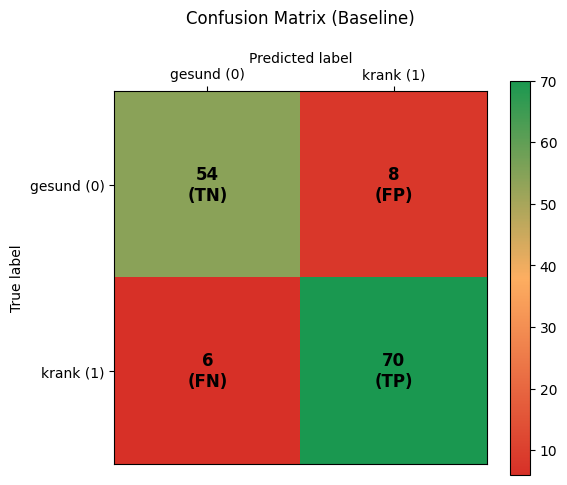

In [112]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

labels = ["gesund (0)", "krank (1)"]

cmap_traffic = LinearSegmentedColormap.from_list(
    "traffic_light",
    ["#d73027", "#fdae61", "#1a9850"]  # rot, orange, grün
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=cmap_traffic)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        if i == 0 and j == 0:
            label = "(TN)"
        elif i == 0 and j == 1:
            label = "(FP)"
        elif i == 1 and j == 0:
            label = "(FN)"
        elif i == 1 and j == 1:
            label = "(TP)"

        ax.text(
            j, i,
            f"{cm[i, j]}\n{label}",
            ha="center", va="center",
            color="black",
            fontsize=12,
            fontweight="bold"
        )

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)

ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)


ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Baseline)", pad=20)


plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Die Confusion Matrix visualisiert die Entscheidungen des **Baseline-Random-Forest-Modells** auf dem Testdatensatz und zeigt, wie sich **korrekte** und **fehlerhafte Klassifikationen** auf beide Klassen verteilen.


Insgesamt zeigt die Confusion Matrix, dass das Baseline-Modell bereits

- eine **gute Erkennungsleistung für kranke Personen** aufweist,
- jedoch weiterhin **Verbesserungspotenzial** besitzt.

Insbesondere die verbleibenden **False Negatives** bilden den **zentralen Ausgangspunkt** für die nachfolgenden XAI-Analysen und gezielten Modellanpassungen.

## Identifikation und Charakterisierung kritischer Fehlklassifikationen

In diesem Abschnitt werden gezielt jene Testfälle identifiziert, bei denen das Modell für unseren Use-Case besonders relevante Fehler macht. Der Fokus liegt somit auf **False Negatives**, also tatsächlich kranken Personen, die vom Modell fälschlich als gesund eingestuft werden. Diese Fälle werden später den korrekt erkannten Kranken (**True Positives**) gegenübergestellt, um systematische Unterschiede sichtbar zu machen.

### Klassen-Vorhersagen und Wahrscheinlichkeiten

In [113]:
# Klassen-Vorhersagen 
y_pred = rf_model.predict(X_test_processed)

# Wahrscheinlichkeiten
y_proba = rf_model.predict_proba(X_test_processed)[:, 1]

Die Klassen-Vorhersagen (`y_pred`) werden verwendet, um die Testdaten **eindeutig nach Entscheidungstypen des Modells** zu trennen, insbesondere um **False Negatives** und **True Positives** gezielt zu identifizieren.

Die Vorhersagewahrscheinlichkeiten (`y_proba`) werden ergänzt, um diese Fälle **quantitativ zu charakterisieren**. Sie zeigen, **wie stark das Modell von seiner Entscheidung überzeugt war** und ermöglichen es zu unterscheiden, ob False Negatives klare Fehlentscheidungen oder **Grenzfälle nahe der Entscheidungsschwelle** sind.

Gemeinsam erlauben `y_pred` und `y_proba` somit eine strukturierte Selektion und Anreicherung kritischer Fälle, die in den folgenden Schritten gezielt mit lokalen XAI-Methoden analysiert werden.

### False Negatives (Untersuchungsobjekt)

In [114]:
# False Negatives: krank (1) aber als gesund (0) vorhergesagt
fn_mask = (y_test == 1) & (y_pred == 0)

fn_cases = X_test_processed[fn_mask].copy()
fn_cases["y_true"] = y_test[fn_mask].values
fn_cases["y_pred"] = y_pred[fn_mask]
fn_cases["y_proba"] = y_proba[fn_mask]
display(fn_cases)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,...,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,y_true,y_pred,y_proba
684,47.0,108.0,243.0,0.0,152.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,0.00
889,59.0,134.0,204.0,0.0,162.0,0.8,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,0.09
759,54.0,192.0,283.0,0.0,195.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,0.23
763,58.0,132.0,224.0,0.0,173.0,3.2,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,0.26
440,52.0,128.0,0.0,0.0,180.0,3.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1,0,0.41
1,49.0,160.0,180.0,0.0,156.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0,0.27


### True Positives (Referenz)

In [115]:
# True Positives: krank (1) und korrekt als krank vorhergesagt
tp_mask = (y_test == 1) & (y_pred == 1)

tp_cases = X_test_processed[tp_mask].copy()
tp_cases["y_true"] = y_test[tp_mask].values
tp_cases["y_pred"] = y_pred[tp_mask]
tp_cases["y_proba"] = y_proba[tp_mask]
display(tp_cases)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,...,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,y_true,y_pred,y_proba
615,70.0,130.0,322.0,0.0,109.0,2.4,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,1,0.69
383,38.0,110.0,0.0,0.0,156.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1,1,0.69
316,57.0,105.0,0.0,1.0,148.0,0.3,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1,1,0.68
351,43.0,140.0,0.0,0.0,140.0,0.5,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1,1,0.76
546,48.0,132.0,220.0,1.0,162.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1,1,0.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,54.0,136.0,220.0,0.0,140.0,3.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1,1.00
313,34.0,115.0,0.0,1.0,154.0,0.2,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1,1,0.59
238,48.0,160.0,355.0,0.0,99.0,2.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1,0.99
242,55.0,160.0,292.0,1.0,143.0,2.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1,1,0.93


## Vergleich der vorhergesagten Krankheitswahrscheinlichkeiten (FN vs. TP)

In [116]:
print("FN y_proba summary:")
print(fn_cases["y_proba"].describe())

print("\nTP y_proba summary:")
print(tp_cases["y_proba"].describe())

FN y_proba summary:
count    6.000000
mean     0.210000
std      0.144914
min      0.000000
25%      0.125000
50%      0.245000
75%      0.267500
max      0.410000
Name: y_proba, dtype: float64

TP y_proba summary:
count    70.000000
mean      0.833714
std       0.137432
min       0.530000
25%       0.720000
50%       0.855000
75%       0.967500
max       1.000000
Name: y_proba, dtype: float64


Die Zusammenfassung der vorhergesagten Wahrscheinlichkeiten zeigt einen klaren Unterschied zwischen **False Negatives** und **True Positives**.

False-Negative-Fälle weisen durchgehend **niedrige vorhergesagte Krankheitswahrscheinlichkeiten** auf. Selbst der höchste Wert liegt deutlich unter der Entscheidungsschwelle von 0.5, was darauf hindeutet, dass das Modell diese Fälle mit hoher Sicherheit als gesund eingestuft hat.

True-Positive-Fälle hingegen besitzen **durchgehend hohe Wahrscheinlichkeiten**, die klar oberhalb der Entscheidungsschwelle liegen. Dies zeigt, dass das Modell bei korrekt erkannten Krankheitsfällen meist sehr überzeugt ist.

Dieser deutliche Abstand zwischen beiden Gruppen legt nahe, dass False Negatives keine Grenzfälle an der Schwelle sind, sondern systematisch anders bewertet werden. Genau diese Fälle sind daher besonders relevant für die folgenden lokalen XAI-Analysen.

---

# Phase 4: Globales XAI

---

In dieser Phase werden **globale XAI-Methoden** angewendet, um die **Gesamtbedeutung der Features** für das trainierte Modell zu analysieren. Im Gegensatz zu lokalen Methoden, die einzelne Vorhersagen erklären, liefern globale Methoden Erkenntnisse über die **allgemeine Wichtigkeit der Merkmale** über den gesamten Datensatz hinweg.

Die Analyse wird durch zwei komplementäre Ansätze durchgeführt:

### Intrinsische Feature Importances

**Intrinsische Feature Importances** sind **modellinterne** Wichtigkeitsmaße, die direkt aus der Struktur und den Parametern des trainierten Modells abgeleitet werden. Bei Tree-basierten Modellen (wie Random Forest oder Gradient Boosting) werden diese typischerweise durch die **Häufigkeit und Tiefe der Feature-Verwendung** in den Entscheidungsbäumen bestimmt.

- **Berechnungsweise**: Das Modell aggregiert, wie oft jedes Feature in den Splits der einzelnen Bäume verwendet wird und wie stark diese Splits zur Reduktion der Verunreinigung (z.B. Gini-Impurity) beitragen.
- **Vorteil**: Diese Methode ist **sehr schnell** und erfordert keine zusätzlichen Modellläufe, da die Informationen bereits im trainierten Modell enthalten sind.
- **Einschränkung**: Die Wichtigkeit ist **modellspezifisch** und kann durch Korrelationen zwischen Features beeinflusst werden, da das Modell möglicherweise ein korreliertes Feature bevorzugt, auch wenn ein anderes Feature ähnlich informativ wäre.

### Extrinsische Feature Importances (Permutation Feature Importance)

**Permutation Feature Importance** ist eine **modellagnostische** Methode, die die Wichtigkeit eines Features durch **systematisches Permutieren** (Zufälligmischen) der Feature-Werte und Messung der daraus resultierenden **Performance-Verschlechterung** bestimmt.

- **Berechnungsweise**: 
  1. Die Baseline-Performance des Modells auf den Testdaten wird gemessen.
  2. Für jedes Feature werden dessen Werte zufällig permutiert, während alle anderen Features unverändert bleiben.
  3. Das Modell wird erneut auf den permutierten Daten evaluiert.
  4. Die **Differenz zwischen Baseline- und permutierter Performance** (z.B. Accuracy-Drop) quantifiziert die Wichtigkeit des Features.
- **Vorteil**: Diese Methode ist **modellunabhängig** und misst die **tatsächliche Auswirkung** eines Features auf die Modellperformance, unabhängig von der internen Modellstruktur.
- **Interpretation**: Ein hoher Performance-Drop nach Permutation eines Features deutet darauf hin, dass dieses Feature **wichtig für die Vorhersagequalität** ist. Features mit geringem oder keinem Drop sind weniger kritisch oder möglicherweise redundant.

Durch die Kombination beider Methoden können **intrinsische Modellpräferenzen** (was das Modell intern als wichtig erachtet) mit der **tatsächlichen Performance-Relevanz** (was objektiv wichtig ist) verglichen werden, was ein umfassenderes Verständnis der Feature-Bedeutung ermöglicht.

### Intrinsische Feature Importances

Intrinsische Feature Importances (Top 10):
          Feature  Importance
      ST_Slope_Up    0.136089
    ST_Slope_Flat    0.129521
            MaxHR    0.092506
      Cholesterol    0.088922
          Oldpeak    0.086995
ChestPainType_ASY    0.078505
              Age    0.070445
        RestingBP    0.064004
 ExerciseAngina_N    0.058999
 ExerciseAngina_Y    0.055367

Gesamtanzahl Features: 20


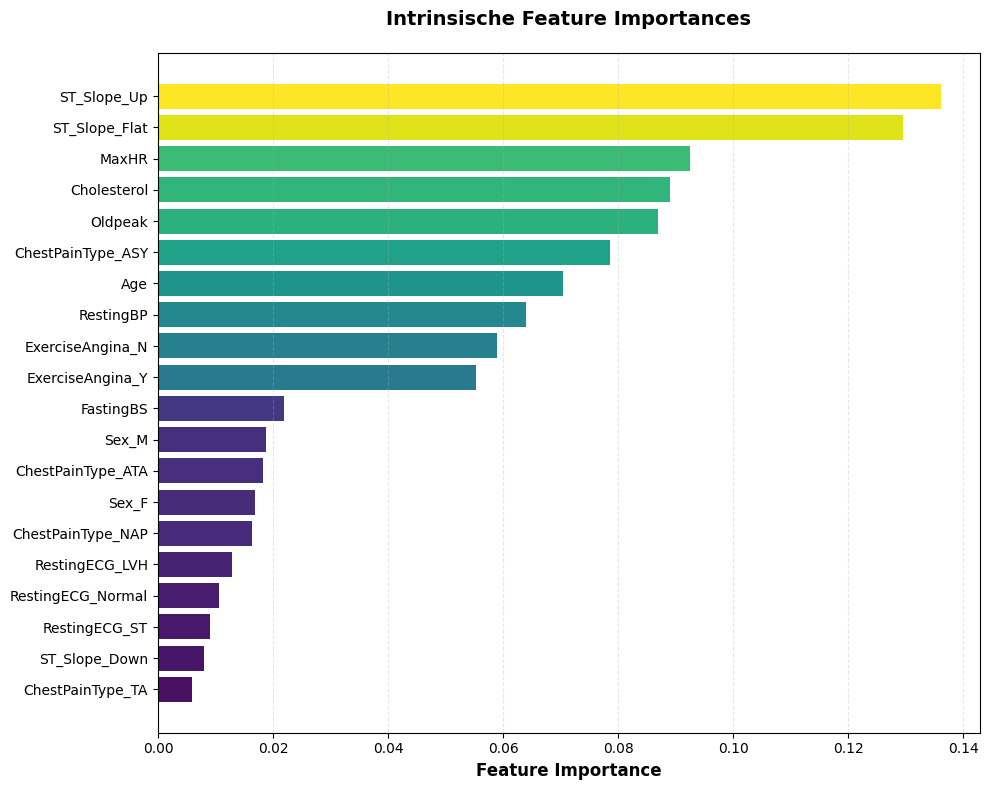


Top 5 wichtigste Features (intrinsisch):
  1. ST_Slope_Up: 0.1361
  2. ST_Slope_Flat: 0.1295
  3. MaxHR: 0.0925
  4. Cholesterol: 0.0889
  5. Oldpeak: 0.0870


In [117]:
# Intrinsische Feature Importances aus dem Random Forest Modell
intrinsic_importances = rf_model.feature_importances_
feature_names = X_train_processed.columns.tolist()

# DataFrame für bessere Übersicht
intrinsic_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': intrinsic_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Intrinsische Feature Importances (Top 10):")
print(intrinsic_df.head(10).to_string(index=False))
print(f"\nGesamtanzahl Features: {len(intrinsic_df)}")

# Visualisierung: Horizontales Balkendiagramm
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(intrinsic_df['Importance'] / intrinsic_df['Importance'].max())
bars = plt.barh(range(len(intrinsic_df)), intrinsic_df['Importance'], color=colors)
plt.yticks(range(len(intrinsic_df)), intrinsic_df['Feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title('Intrinsische Feature Importances', 
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()  # Wichtigste Features oben
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Zusätzlich: Top Features als Text-Output
print(f"\nTop 5 wichtigste Features (intrinsisch):")
for i, row in intrinsic_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

### Extrinsische Feature Importances (Permutation Feature Importance)

Berechne Permutation Feature Importance...
Dies kann einige Zeit in Anspruch nehmen...

Extrinsische Feature Importances (Permutation, Top 10):
          Feature  Importance_Mean  Importance_Std
      Cholesterol         0.041304        0.013768
ChestPainType_ASY         0.040580        0.012634
        FastingBS         0.026087        0.009280
            Sex_M         0.022464        0.007565
          Oldpeak         0.021014        0.009420
    ST_Slope_Flat         0.017391        0.015609
            Sex_F         0.017391        0.005797
 ExerciseAngina_N         0.016667        0.005660
      ST_Slope_Up         0.014493        0.016524
        RestingBP         0.009420        0.007971

Gesamtanzahl Features: 20


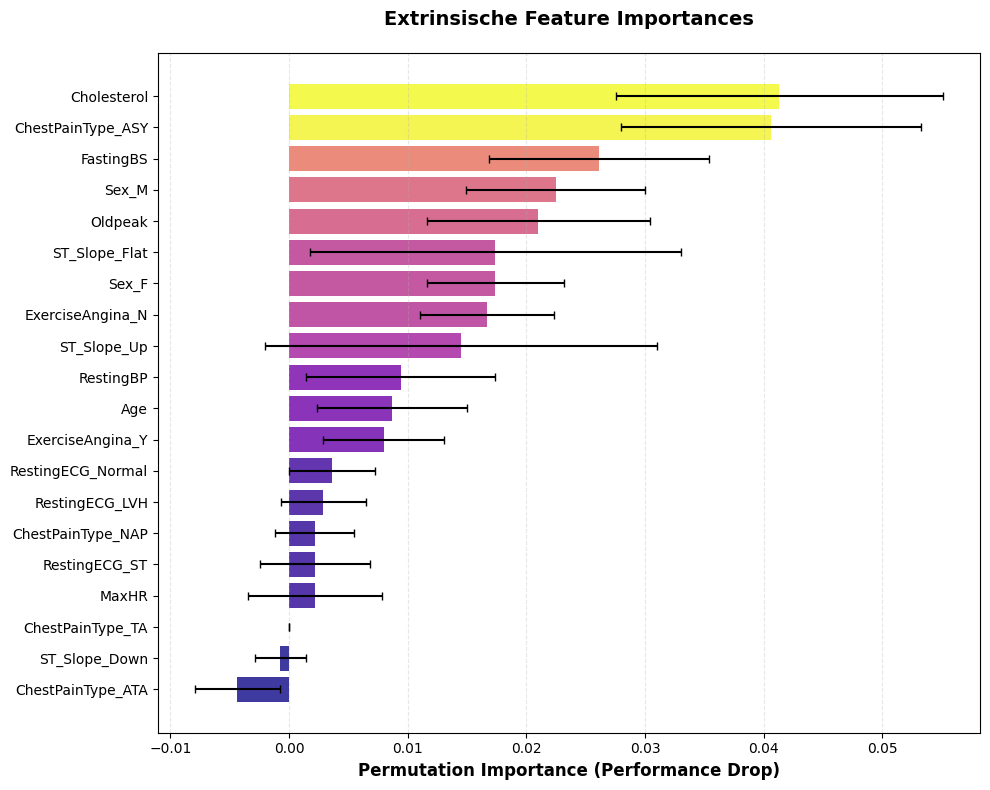


Top 5 wichtigste Features (extrinsisch - Permutation):
  1. Cholesterol: 0.0413 (±0.0138)
  2. ChestPainType_ASY: 0.0406 (±0.0126)
  3. FastingBS: 0.0261 (±0.0093)
  4. Sex_M: 0.0225 (±0.0076)
  5. Oldpeak: 0.0210 (±0.0094)


In [118]:
from sklearn.inspection import permutation_importance

# Permutation Feature Importance berechnen
# Verwendung des Test-Sets für die Evaluation
print("Berechne Permutation Feature Importance...")
print("Dies kann einige Zeit in Anspruch nehmen...\n")

perm_result = permutation_importance(
    rf_model,
    X_test_processed,
    y_test,
    n_repeats=10,  # Anzahl der Permutationen pro Feature
    random_state=40,
    n_jobs=-1,  # Parallelisierung
    scoring='accuracy'
)

# Ergebnisse in DataFrame umwandeln
extrinsic_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

print("Extrinsische Feature Importances (Permutation, Top 10):")
print(extrinsic_df.head(10).to_string(index=False))
print(f"\nGesamtanzahl Features: {len(extrinsic_df)}")

# Visualisierung: Horizontales Balkendiagramm mit Fehlerbalken
plt.figure(figsize=(10, 8))
y_pos = range(len(extrinsic_df))
colors = plt.cm.plasma(extrinsic_df['Importance_Mean'] / extrinsic_df['Importance_Mean'].max())
bars = plt.barh(y_pos, extrinsic_df['Importance_Mean'], 
                xerr=extrinsic_df['Importance_Std'], 
                color=colors, 
                alpha=0.8,
                capsize=3)
plt.yticks(y_pos, extrinsic_df['Feature'])
plt.xlabel('Permutation Importance (Performance Drop)', fontsize=12, fontweight='bold')
plt.title('Extrinsische Feature Importances', 
          fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()  # Wichtigste Features oben
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Zusätzlich: Top Features als Text-Output
print(f"\nTop 5 wichtigste Features (extrinsisch - Permutation):")
for i, row in extrinsic_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance_Mean']:.4f} (±{row['Importance_Std']:.4f})")

### Vergleich: Intrinsische vs. Extrinsische Feature Importances

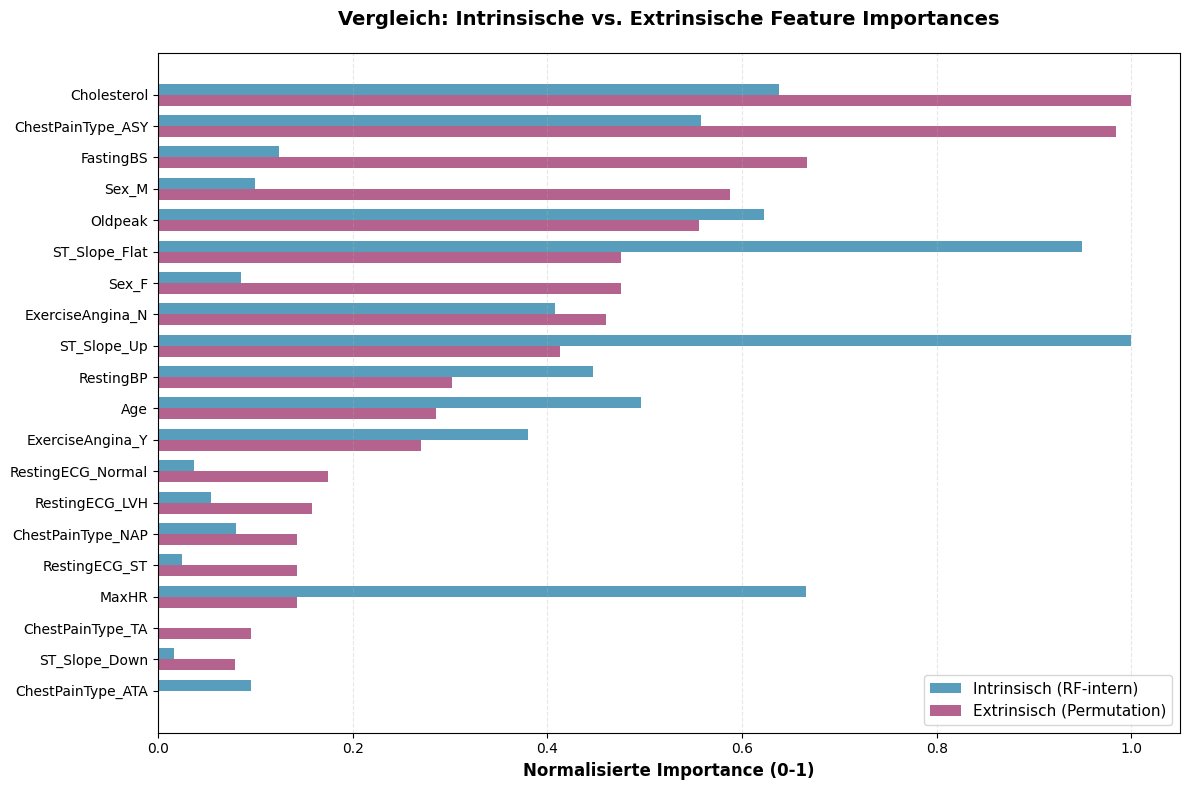


Korrelation zwischen intrinsischen und extrinsischen Importances: 0.4382

Top 10 Features nach durchschnittlicher Wichtigkeit:
          Feature  Intrinsisch  Extrinsisch
      Cholesterol     0.088922     0.041304
ChestPainType_ASY     0.078505     0.040580
        FastingBS     0.021967     0.026087
            Sex_M     0.018838     0.022464
          Oldpeak     0.086995     0.021014
    ST_Slope_Flat     0.129521     0.017391
            Sex_F     0.016950     0.017391
 ExerciseAngina_N     0.058999     0.016667
      ST_Slope_Up     0.136089     0.014493
        RestingBP     0.064004     0.009420


In [119]:
# Vergleich beider Methoden
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Intrinsisch': intrinsic_importances,
    'Extrinsisch': perm_result.importances_mean
})

# Normalisierung für besseren Vergleich (0-1 Skala)
comparison_df['Intrinsisch_Norm'] = (comparison_df['Intrinsisch'] - comparison_df['Intrinsisch'].min()) / (comparison_df['Intrinsisch'].max() - comparison_df['Intrinsisch'].min())
comparison_df['Extrinsisch_Norm'] = (comparison_df['Extrinsisch'] - comparison_df['Extrinsisch'].min()) / (comparison_df['Extrinsisch'].max() - comparison_df['Extrinsisch'].min())

# Sortierung nach durchschnittlicher Wichtigkeit
comparison_df['Durchschnitt'] = (comparison_df['Intrinsisch_Norm'] + comparison_df['Extrinsisch_Norm']) / 2
comparison_df = comparison_df.sort_values('Extrinsisch', ascending=False).reset_index(drop=True)

# Visualisierung: Vergleich beider Methoden
fig, ax = plt.subplots(figsize=(12, 8))
x_pos = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.barh(x_pos - width/2, comparison_df['Intrinsisch_Norm'], 
                width, label='Intrinsisch (RF-intern)', 
                color='#2E86AB', alpha=0.8)
bars2 = ax.barh(x_pos + width/2, comparison_df['Extrinsisch_Norm'], 
                width, label='Extrinsisch (Permutation)', 
                color='#A23B72', alpha=0.8)

ax.set_yticks(x_pos)
ax.set_yticklabels(comparison_df['Feature'])
ax.set_xlabel('Normalisierte Importance (0-1)', fontsize=12, fontweight='bold')
ax.set_title('Vergleich: Intrinsische vs. Extrinsische Feature Importances', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Korrelationsanalyse
correlation = comparison_df['Intrinsisch'].corr(comparison_df['Extrinsisch'])
print(f"\nKorrelation zwischen intrinsischen und extrinsischen Importances: {correlation:.4f}")
print("\nTop 10 Features nach durchschnittlicher Wichtigkeit:")
print(comparison_df[['Feature', 'Intrinsisch', 'Extrinsisch']].head(10).to_string(index=False))

### Interpretation der Ergebnisse

Die **moderate positive Korrelation** zwischen intrinsischen und extrinsischen Feature Importances zeigt, dass beide Methoden **tendenziell ähnliche Features als wichtig identifizieren**, jedoch mit **deutlichen Abweichungen** bei einzelnen Merkmalen. Diese Diskrepanzen liefern wertvolle Erkenntnisse über das Modellverhalten:

#### Übereinstimmende Features

Einige Features werden von **beiden Methoden als ähnlich wichtig** eingestuft. Diese Features zeigen eine **konsistente Bedeutung** sowohl in der internen Modellstruktur als auch in ihrer tatsächlichen Auswirkung auf die Vorhersagequalität. Sie können als **robust wichtige Merkmale** betrachtet werden, die das Modell zuverlässig nutzt.

#### Diskrepanzen: Hohe intrinsische, niedrige extrinsische Importance

Mehrere Features weisen eine **deutlich höhere intrinsische als extrinsische Importance** auf. Dies deutet darauf hin, dass das Random-Forest-Modell diese Features **intern häufig verwendet** (z.B. in vielen Splits der Entscheidungsbäume), ihre **tatsächliche Auswirkung auf die Performance jedoch begrenzt** ist.

Mögliche Ursachen:
- **Korrelationen zwischen Features**: Das Modell nutzt diese Features als **Ersatz für andere, korrelierte Merkmale**. Wenn ein Feature permutiert wird, kann das Modell auf korrelierte Alternativen ausweichen, sodass der Performance-Drop gering bleibt.
- **Redundanz**: Diese Features tragen zur Modellstruktur bei, sind aber **nicht kritisch für die Vorhersagequalität**, da andere Features ähnliche Informationen liefern.
- **Modellinterne Präferenzen**: Tree-basierte Modelle können bestimmte Features bevorzugen, auch wenn sie objektiv nicht die wichtigsten sind.

#### Diskrepanzen: Niedrige intrinsische, höhere extrinsische Importance

Features mit **niedrigerer intrinsischer aber höherer extrinsischer Importance** sind seltener, aber besonders interessant. Sie werden vom Modell **weniger häufig intern genutzt**, haben jedoch einen **überproportionalen Einfluss auf die Performance**, wenn sie entfernt werden.

Dies kann darauf hindeuten, dass:
- Das Feature **selten, aber entscheidend** verwendet wird (z.B. in kritischen Splits nahe der Wurzel der Bäume).
- Das Feature **eindeutige Informationen** liefert, die nicht durch andere Features ersetzt werden können.

#### Bedeutung für das Modellverständnis

Die **Kombination beider Methoden** ermöglicht ein differenziertes Verständnis:

- **Intrinsische Importances** zeigen, **was das Modell intern bevorzugt** und wie es strukturiert ist.
- **Extrinsische Importances** zeigen, **was objektiv wichtig für die Performance** ist.

Die **moderate Korrelation** bestätigt, dass beide Perspektiven wertvoll sind: Während die intrinsischen Importances die **Modellarchitektur** widerspiegeln, offenbaren die extrinsischen Importances **tatsächliche Abhängigkeiten** und potenzielle **Redundanzen** im Feature-Set. Dies zeigt, welche Features möglicherweise entfernt werden können, ohne die Performance zu beeinträchtigen.

## SHAP-basierte globale Feature-Analyse

Während die bisherigen Methoden (intrinsische und extrinsische Feature Importances) die **allgemeine Wichtigkeit** von Features quantifizieren, ermöglichen **SHAP-Werte** eine detailliertere Analyse, die sowohl die **globale Bedeutung** als auch die **Richtung des Einflusses** (positiv/negativ) und die **Abhängigkeiten zwischen Features** aufzeigt.

### SHAP Beeswarm Plot

Der **Beeswarm Plot** ist eine kompakte Visualisierung, die für jedes Feature zeigt:

- **Globale Wichtigkeit**: Features sind nach der durchschnittlichen absoluten SHAP-Wichtigkeit (`mean(|SHAP|)`) sortiert, sodass die wichtigsten Features oben erscheinen.
- **Richtung des Einflusses**: Die **Farbe** jedes Punktes repräsentiert den **Feature-Wert** (niedrig = blau, hoch = rot), während die **Position auf der x-Achse** den **SHAP-Wert** zeigt (links = negativer Einfluss, rechts = positiver Einfluss).
- **Verteilung der Effekte**: Die **Dichte der Punkte** zeigt, wie häufig bestimmte SHAP-Werte auftreten und ob der Einfluss eines Features konsistent oder variabel ist.

Durch die Kombination von Position und Farbe kann abgelesen werden, ob **hohe oder niedrige Feature-Werte** tendenziell die Vorhersage in Richtung "krank" oder "gesund" verschieben.

### Mean |SHAP| Bar Plot

Der **Mean |SHAP| Bar Plot** bietet ein **sauberes, quantitatives Ranking** der Feature-Wichtigkeit. Er zeigt für jedes Feature den **durchschnittlichen absoluten SHAP-Wert** über alle Testfälle hinweg.

- **Vorteil**: Einfache, klare Darstellung der **relativen Wichtigkeit** ohne die Komplexität der Verteilungen.
- **Interpretation**: Höhere Balken entsprechen Features, die im Durchschnitt einen **stärkeren Einfluss** auf die Modellvorhersagen haben.
- **Vergleich**: Ermöglicht einen direkten Vergleich mit den intrinsischen und extrinsischen Feature Importances.

### Dependence Plots

**Dependence Plots** visualisieren die **Abhängigkeit zwischen einem Feature und seinem SHAP-Wert**, wobei gleichzeitig der **Einfluss eines zweiten, interagierenden Features** dargestellt wird.

- **Hauptachse (x)**: Der **Feature-Wert** des analysierten Features.
- **Vertikale Achse (y)**: Der **SHAP-Wert** für dieses Feature (zeigt den Einfluss auf die Vorhersage).
- **Farbe**: Repräsentiert die **Werte eines zweiten Features**, das mit dem Hauptfeature interagiert.

Diese Plots offenbaren:
- **Nichtlineare Beziehungen**: Ob der Einfluss eines Features linear ist oder komplexere Muster aufweist.
- **Feature-Interaktionen**: Wie die Wirkung eines Features von den Werten anderer Features abhängt.
- **Schwellenwerte**: Punkte, an denen sich der Einfluss eines Features deutlich ändert.

Für die **Top-Features** (basierend auf Mean |SHAP|) werden Dependence Plots erstellt, um diese detaillierten Muster zu untersuchen.

### SHAP Beeswarm Plot und Mean |SHAP| Bar Plot

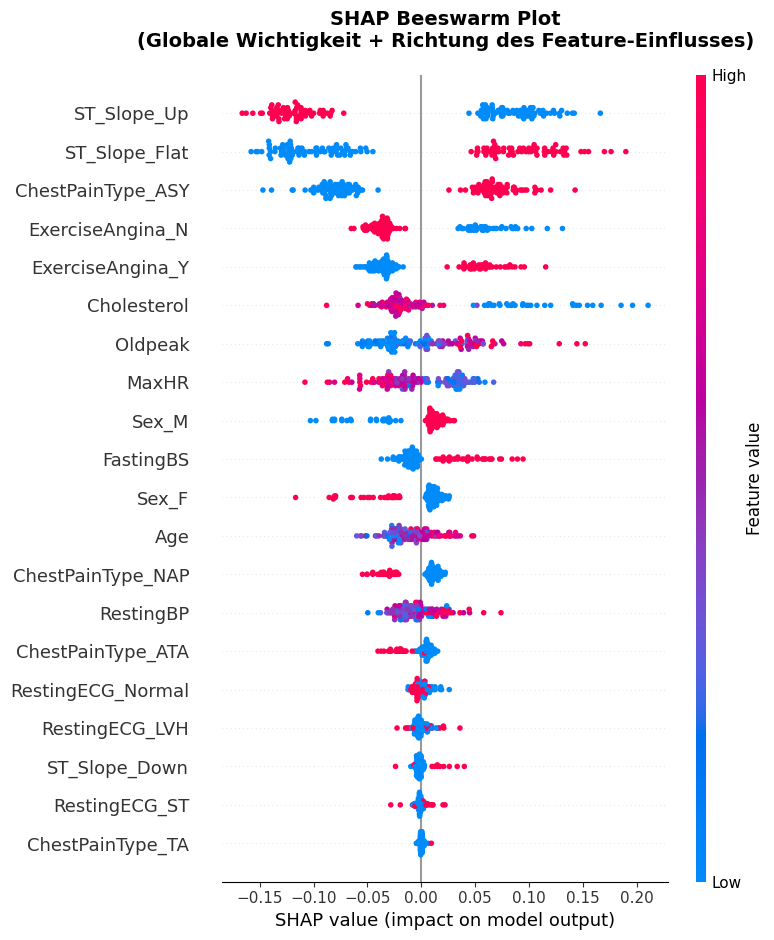

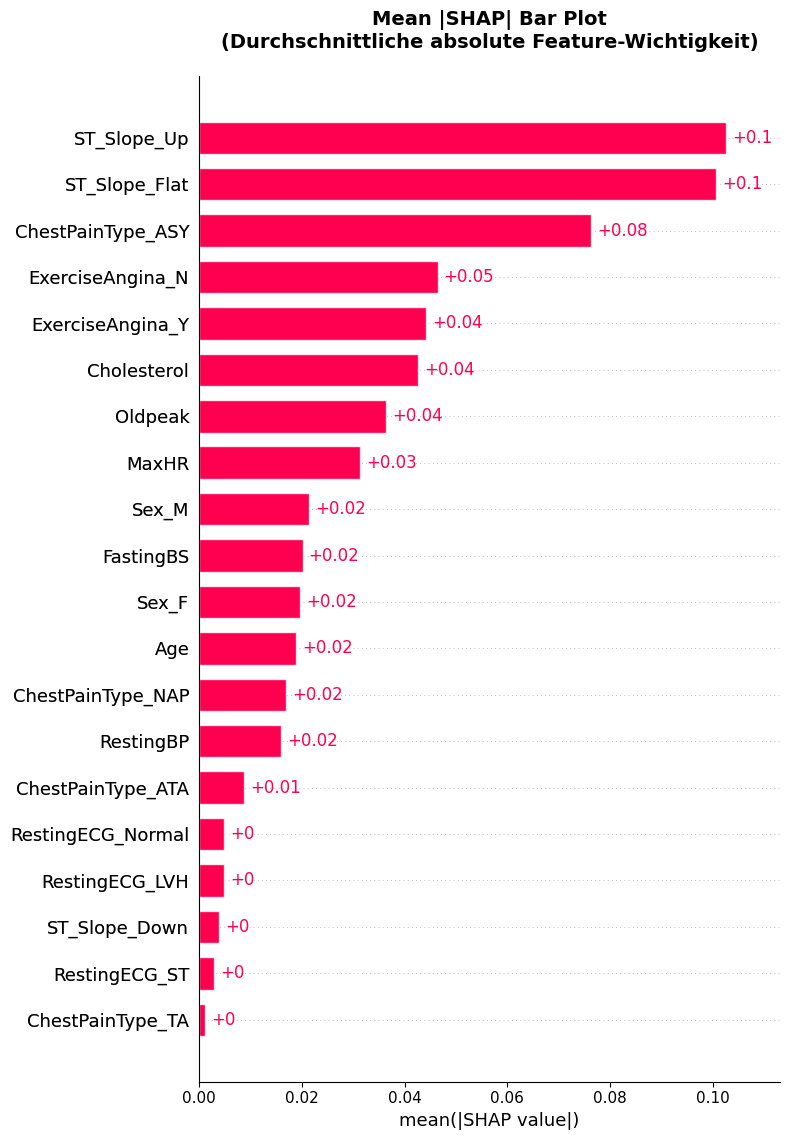

Top 10 Features nach Mean |SHAP|:
          Feature  Mean_|SHAP|
      ST_Slope_Up     0.102525
    ST_Slope_Flat     0.100535
ChestPainType_ASY     0.076218
 ExerciseAngina_N     0.046407
 ExerciseAngina_Y     0.044221
      Cholesterol     0.042604
          Oldpeak     0.036374
            MaxHR     0.031254
            Sex_M     0.021369
        FastingBS     0.020150


In [120]:
# SHAP-Werte berechnen
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_processed)
base_value = explainer.expected_value

# Robust auf "list" vs "3D array" reagieren
if isinstance(shap_values, list):
    shap_values_1 = shap_values[1]              # (n_samples, n_features)
    base_value_1 = base_value[1] if isinstance(base_value, (list, np.ndarray)) else base_value
else:
    if shap_values.ndim == 3:
        shap_values_1 = shap_values[:, :, 1]    # Klasse 1 -> (n_samples, n_features)
    else:
        shap_values_1 = shap_values             # fallback (sollte dann schon 2D sein)
    
    if isinstance(base_value, (list, np.ndarray)) and np.ndim(base_value) > 0:
        base_value_1 = base_value[1]
    else:
        base_value_1 = base_value

# SHAP Beeswarm Plot für globale Analyse
# Zeigt Wichtigkeit + Richtung des Einflusses

# Erstelle Explanation-Objekt für bessere Kompatibilität
explanation = shap.Explanation(
    values=shap_values_1,
    base_values=base_value_1,
    data=X_test_processed.values,
    feature_names=X_test_processed.columns.tolist()
)

shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title('SHAP Beeswarm Plot\n(Globale Wichtigkeit + Richtung des Feature-Einflusses)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Mean |SHAP| Bar Plot - Sauberes Ranking der Feature-Wichtigkeit
# Explanation-Objekt für Kompatibilität (wie beim Beeswarm)
explanation_bar = shap.Explanation(
    values=shap_values_1,
    base_values=base_value_1,
    data=X_test_processed.values,
    feature_names=X_test_processed.columns.tolist()
)

shap.plots.bar(explanation_bar, max_display=20, show=False)
plt.title('Mean |SHAP| Bar Plot\n(Durchschnittliche absolute Feature-Wichtigkeit)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Zusätzlich: Numerische Ausgabe der Top Features
mean_shap_abs = np.abs(shap_values_1).mean(axis=0)
shap_ranking = pd.DataFrame({
    'Feature': X_test_processed.columns,
    'Mean_|SHAP|': mean_shap_abs
}).sort_values('Mean_|SHAP|', ascending=False).reset_index(drop=True)

print("Top 10 Features nach Mean |SHAP|:")
print(shap_ranking.head(10).to_string(index=False))

### One-Hot-Encoding und Modellverhalten

Merkmale wie **Geschlecht** (`Sex`) und **Belastungsangina** (`ExerciseAngina`) wurden durch das One-Hot-Encoding in binäre Spalten aufgeteilt (z.B. `Sex_M`/`Sex_F`, `ExerciseAngina_Y`/`ExerciseAngina_N`). Im **Beeswarm-** und im **Mean-|SHAP|-Bar-Plot** zeigt sich, dass die so entstandenen Teilfeatures in ihrer **Vorhersagewirkung komplementär** sind: hohe SHAP-Werte bei der einen Ausprägung entsprechen tendenziell niedrigen bei der anderen.

Daraus lässt sich argumentieren, dass für den **Random Forest** ein One-Hot-Encoding bei solchen binären Kategorien nicht zwingend nötig wäre: Im Gegensatz zu vielen statistischen Modellen interpretiert der Random Forest **keine kardinale Wertigkeit** der Kategorien, sondern nutzt die **Gini-Impurity** ausschließlich, um **Splits** in den Merkmalen zu finden. Die Aufteilung in mehrere Spalten liefert dabei dieselbe Splittinformation wie eine einzige kodierte Spalte.

**Aus dem Vergleich intrinsischer und extrinsischer Feature Importances** ergibt sich dafür nur eine **eingeschränkte Bestätigung**: Die **Geschlechtsmerkmale** (`Sex_M`, `Sex_F`) weisen in beiden Methoden **ähnliche Importance-Werte** auf. Bei der **Belastungsangina** (`ExerciseAngina_Y`, `ExerciseAngina_N`) zeigt sich dagegen ein **gegensätzliches Bild** – die intrinsische und die extrinsische Importance unterscheiden sich hier stärker. Das spricht dafür, dass die Rolle von One-Hot-Encoding und die tatsächliche Modellnutzung je nach Merkmal unterschiedlich ausfallen und weiter zu betrachten sind.

Auch **ST_Slope** erscheint in der vorliegenden One-Hot-Kodierung wenig sinnvoll: **Flat** und **Up** zeigen in den SHAP-Plots einen **gegensätzlichen Effekt** auf die Vorhersage und wirken damit in der Aufteilung in mehrere Spalten **redundant**. Da die Ausprägungen der ST-Streckensteigung inhaltlich eine **natürliche Ordnung** besitzen (Down → Flat → Up), wäre hier eine **ordinale Kodierung** naheliegend – z.B. Down = 0, Flat = 1, Up = 2 –, die die Abstufung abbildet und die Redundanz im Modell verringern könnte.

### Dependence Plots für Top-Features

Erstelle Dependence Plots für die Top 6 Features:

1. ST_Slope_Up
2. ST_Slope_Flat
3. ChestPainType_ASY
4. ExerciseAngina_N
5. ExerciseAngina_Y
6. Cholesterol


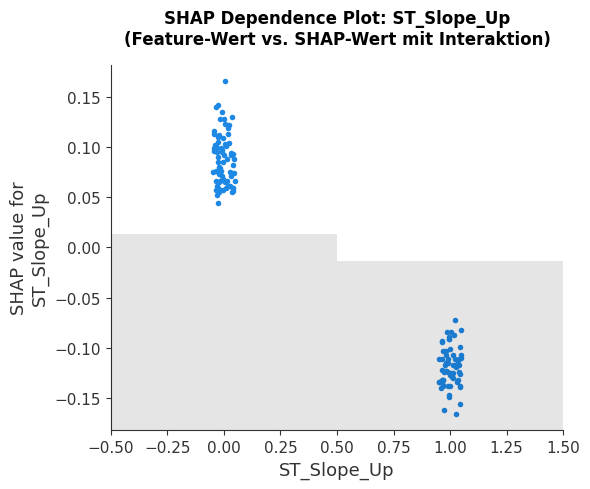

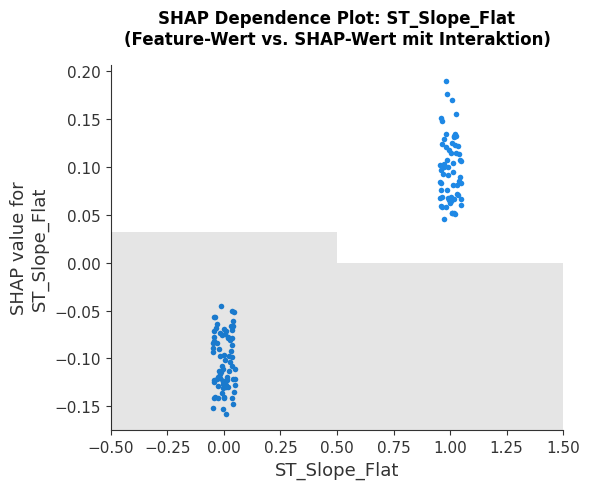

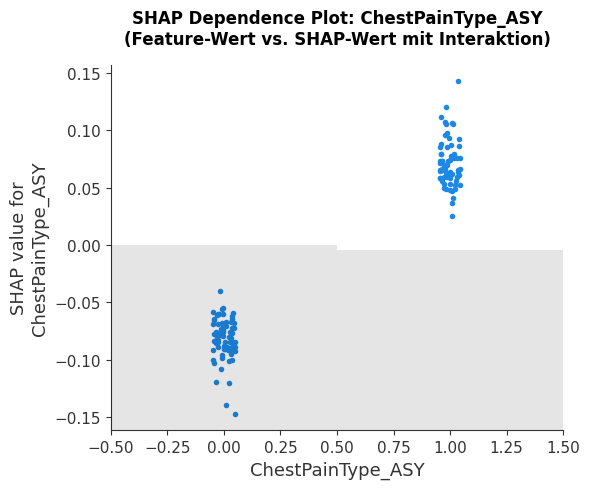

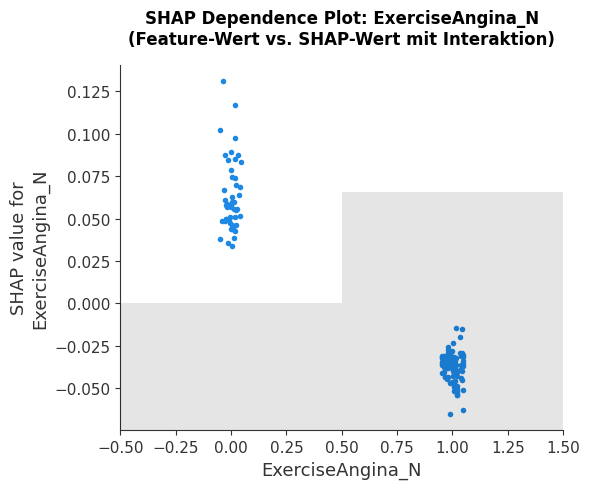

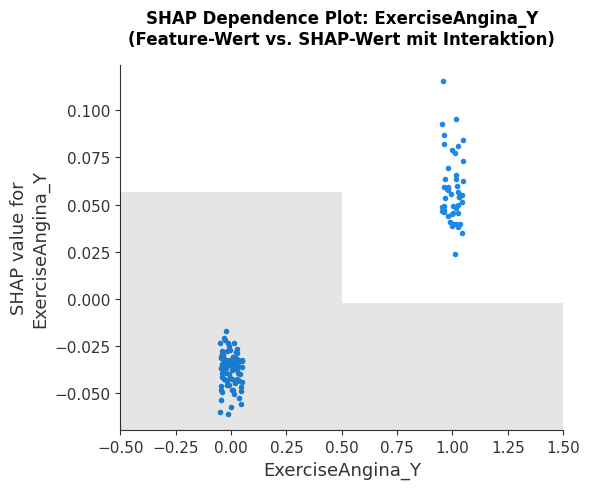

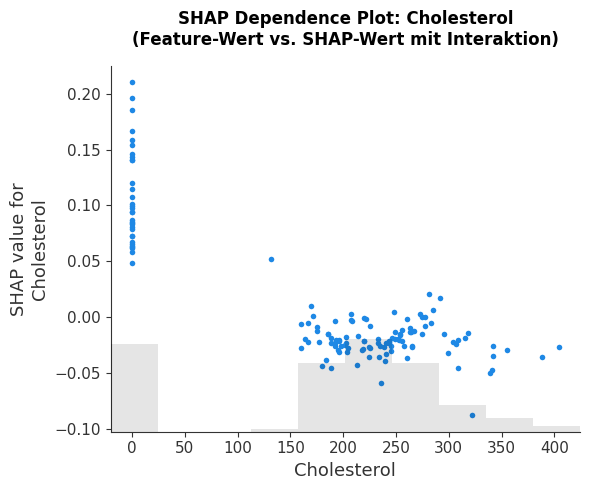

In [121]:
# Bestimme Top-Features für Dependence Plots (z.B. Top 6)
top_n_features = 6
top_features = shap_ranking.head(top_n_features)['Feature'].tolist()

print(f"Erstelle Dependence Plots für die Top {top_n_features} Features:\n")
for i, feature in enumerate(top_features, 1):
    print(f"{i}. {feature}")

# Explanation-Objekt für Dependence Plots (wird von scatter erwartet)
explanation_dep = shap.Explanation(
    values=shap_values_1,
    base_values=base_value_1,
    data=X_test_processed.values,
    feature_names=X_test_processed.columns.tolist()
)

# Dependence Plots für jedes Top-Feature
# explanation_dep[:, feature] liefert ein Explanation-Slice für dieses Feature
for feature in top_features:
    shap.plots.scatter(
        explanation_dep[:, feature],
        show=False
    )
    plt.title(f'SHAP Dependence Plot: {feature}\n(Feature-Wert vs. SHAP-Wert mit Interaktion)', 
              fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

### Interpretation der Dependence Plots

Die Dependence Plots für die **Top 6 Features** zeigen folgende Muster:

**Binäre Features (1–5: ST_Slope_Up, ST_Slope_Flat, ChestPainType_ASY, ExerciseAngina_N, ExerciseAngina_Y)**  
Alle fünf Merkmale sind **binär (0 oder 1)** kodiert. Ihre SHAP-Werte sind **klar nach den beiden Ausprägungen getrennt**: Die einen Kategorien ziehen die Vorhersage in die eine Richtung (positiver SHAP-Wert → stärker in Richtung „krank“), die anderen in die Gegenrichtung (negativer SHAP-Wert → stärker in Richtung „gesund“). Es gibt kaum Überlappung zwischen den Klassen. Das bestätigt, dass diese Features **eindeutig und gerichtet** vom Modell genutzt werden und die One-Hot-Darstellung hier gut zu trennbaren, interpretierbaren Effekten führt.

**Cholesterol (6.)**  
Cholesterol ist **stetig** und hebt sich von den anderen Top-Features ab:

- Für **Cholesterol = 0** liegen die SHAP-Werte **durchweg im positiven Bereich** – das Modell stuft diese Fälle tendenziell eher als „krank“ ein. Aus medizinischer Sicht sind Cholesterinwerte von 0 **nicht plausibel**; vielmehr deuten sie auf **fehlende oder ersatzweise aufgefüllte Werte** (z.B. Placeholder für Missing Values) hin.
- Für **alle übrigen (plausiblen) Cholesterol-Werte** sind die SHAP-Werte **leicht negativ**: höhere Cholesterinwerte gehen im Schnitt mit einem etwas geringeren Beitrag in Richtung „krank“ einher – oder umgekehrt formuliert, das Modell nutzt „normal“ gemessene Cholesterol-Werte eher als Hinweis in Richtung „gesund“ bzw. geringeres Krankheitsrisiko.


# Phase 5: Lokales XAI

## Auswahl der Vergleichsgruppen

In [122]:
# 1) Echte Feature-Spalten definieren (aus processed Matrix)
feature_cols = X_train_processed.columns.tolist()

num_cols = numeric_features
cat_cols = [c for c in feature_cols if c not in num_cols]

# 2) Scaler NUR auf TRAIN fitten
scaler = StandardScaler()
scaler.fit(X_train_processed[num_cols])

# 3) Hilfsfunktion: Feature-Matrix für kNN bauen (ohne y_true/y_pred/y_proba)
def build_knn_matrix(df):
    X = df[feature_cols]  # nur echte Features
    X_num = scaler.transform(X[num_cols])
    X_cat = X[cat_cols].values
    return np.hstack([X_num, X_cat])

# 4) Matrizen bauen
X_fn = build_knn_matrix(fn_cases)
X_tp = build_knn_matrix(tp_cases)

fn_idx = fn_cases.index.to_list()
tp_idx = tp_cases.index.to_list()

# 5) kNN: für jeden FN die k ähnlichsten TP finden
k = 3
nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(X_tp)

distances, indices = nn.kneighbors(X_fn)

# 6) Ergebnis-Tabelle
rows = []
for i, fn_id in enumerate(fn_idx):
    for r in range(k):
        tp_id = tp_idx[indices[i, r]]
        rows.append({
            "fn_id": fn_id,
            "tp_id": tp_id,
            "rank": r + 1,
            "distance": float(distances[i, r]),
            "fn_proba": float(fn_cases.loc[fn_id, "y_proba"]),
            "tp_proba": float(tp_cases.loc[tp_id, "y_proba"]),
        })

knn_matches_df = pd.DataFrame(rows).sort_values(["fn_id","rank"]).reset_index(drop=True)
knn_matches_df

,fn_id,tp_id,rank,distance,fn_proba,tp_proba
0,1,264,1,2.310927,0.27,0.72
1,1,281,2,2.647454,0.27,0.97
2,1,735,3,2.779110,0.27,0.62
3,440,492,1,2.432686,0.41,0.70
4,440,735,2,3.261938,0.41,0.62
5,440,337,3,3.459791,0.41,0.70
6,684,104,1,2.391920,0.00,0.98
7,684,131,2,2.484117,0.00,0.89
8,684,735,3,2.539645,0.00,0.62
9,759,581,1,4.267965,0.23,0.74


Für **jeden False-Negative-Fall** wird eine kleine Gruppe von **strukturell ähnlichen True-Positive-Fällen** bestimmt. Konkret werden für jeden FN die **k = 3 nächstgelegenen TP-Fälle im Feature-Raum** gesucht, basierend auf allen vorverarbeiteten numerischen und kategorialen Merkmalen.

Auf diese Weise werden Fälle verglichen, die sich im Patientenprofil möglichst ähneln, sich jedoch **in der Modellentscheidung unterscheiden**.  
Dies ermöglicht es, Unterschiede zu identifizieren, die maßgeblich dazu beitragen, dass ein Patient trotz ähnlicher Merkmalsausprägungen einmal korrekt und einmal fälschlich klassifiziert wird.


### Verwendete Feature-Basis

Als Ausgangspunkt dienen die **tatsächlichen Feature-Spalten** aus der bereits vorverarbeiteten Matrix `X_*_processed`.

Dabei wird wie folgt vorgegangen:

- **Numerische Features**
  - werden standardisiert,
  - der Scaler wird **ausschließlich auf den Trainingsdaten gefittet**,
  - um **Data Leakage** zu vermeiden.
- **One-Hot-kodierte kategoriale Features**
  - bleiben **unverändert**.

Beide Feature-Typen werden anschließend zu einer **gemeinsamen Feature-Matrix** zusammengeführt.


### Ähnlichkeitsbestimmung mittels kNN

Auf der kombinierten Feature-Matrix wird ein **k-Nearest-Neighbors (kNN)-Modell** trainiert,

- **ausschließlich auf den True-Positive-Fällen**,
- um für jeden False Negative vergleichbare korrekt klassifizierte Fälle zu finden.

Für jeden FN werden die

- **k = 3 ähnlichsten True Positives**

ermittelt.


### Ergebnis: Matching-Tabelle für lokale XAI-Analysen

Das Ergebnis ist eine **Matching-Tabelle**, die für jeden False Negative enthält:

- die **FN-ID** (`fn_id`),
- die **IDs der ähnlichsten True Positives** (`tp_id`),
- den **Rang** der Ähnlichkeit,
- die **Distanz** als Ähnlichkeitsmaß,
- die vom Random Forest vorhergesagte Krankheitswahrscheinlichkeit
  - für den FN (`fn_proba`)
  - und für die jeweiligen TPs (`tp_proba`).

Diese strukturierte Zuordnung liefert **konkrete Vergleichspaare**, die anschließend für lokale XAI-Methoden (z. B. SHAP, LIME) genutzt werden können,  
um **gezielt Unterschiede zu identifizieren**, die die Modellentscheidung erklären.

## Vorbereitung lokaler SHAP-Erklärungen für das Random-Forest-Modell

In [123]:
shap.initjs()
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_processed)
base_value = explainer.expected_value

# --- Robust auf "list" vs "3D array" reagieren ---
if isinstance(shap_values, list):
    # klassisch: [class0, class1]
    shap_values_1 = shap_values[1]              # (n_samples, n_features)
    base_value_1 = base_value[1] if isinstance(base_value, (list, np.ndarray)) else base_value
else:
    # neu/anders: (n_samples, n_features, n_classes)
    if shap_values.ndim == 3:
        shap_values_1 = shap_values[:, :, 1]    # Klasse 1 -> (n_samples, n_features)
    else:
        shap_values_1 = shap_values             # fallback (sollte dann schon 2D sein)

    if isinstance(base_value, (list, np.ndarray)) and np.ndim(base_value) > 0:
        base_value_1 = base_value[1]
    else:
        base_value_1 = base_value

In dieser Zelle wird ein **SHAP-Explainer speziell für baum-basierte Modelle** initialisiert, um **lokale Erklärungen für einzelne Vorhersagen** des Random Forests zu berechnen. SHAP zerlegt dabei jede Modellentscheidung in **Feature-Beiträge**, die zeigen, wie einzelne Merkmale die Vorhersage in Richtung „krank“ oder „gesund“ verschieben.

Die berechneten SHAP-Werte liegen dabei **in der Log-Odds-Domäne** vor (Standardausgabe von `TreeExplainer` für Klassifikationsmodelle). Ein positiver SHAP-Wert erhöht die **Log-Odds für die Klasse „krank“**, ein negativer SHAP-Wert senkt sie entsprechend. Die Summe aus **Base Value** und allen Feature-Beiträgen ergibt die vom Modell berechnete Log-Odds-Vorhersage, die über die logistische Funktion in eine **Wahrscheinlichkeit** transformiert werden kann.

Da Random-Forest-Modelle bei Klassifikationsproblemen **SHAP-Werte in unterschiedlichen Formaten** zurückgeben können (abhängig von SHAP- und scikit-learn-Version), wird der Code bewusst **robust gestaltet**. Es wird geprüft, ob die SHAP-Werte

- als **Liste** (klassisch: eine Matrix pro Klasse) oder
- als **3D-Array**

vorliegen. In beiden Fällen werden gezielt die **SHAP-Werte für die positive Klasse (HeartDisease = 1)** extrahiert.

Zusätzlich wird der zugehörige **Base Value** für Klasse 1 bestimmt. Dieser Wert repräsentiert die **durchschnittliche Modellvorhersage in Log-Odds** und dient als **Referenzpunkt**, von dem aus die einzelnen Feature-Beiträge die finale Vorhersage nach oben oder unten verschieben.

## Lokaler SHAP-Vergleich: False Negative vs. ähnliche True Positives

In [124]:
def get_shap_row(idx):
    row_pos = X_test_processed.index.get_loc(idx)
    x_row = X_test_processed.loc[idx]
    s_row = shap_values_1[row_pos].ravel()  # ravel() stellt sicher, dass es 1D ist
    return row_pos, x_row, s_row


def plot_waterfall(idx, title):
    row_pos, x_row, s_row = get_shap_row(idx)

    exp = shap.Explanation(
        values=s_row,
        base_values=base_value_1,
        data=x_row.values,
        feature_names=X_test_processed.columns
    )

    plt.figure()
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def compare_fn_to_tps(fn_id, k=3):
    # passende TPs holen
    matches = (
        knn_matches_df[knn_matches_df["fn_id"] == fn_id]
        .sort_values("rank")
        .head(k)
    )

    tp_ids = matches["tp_id"].tolist()

    print(
        "FN:", fn_id,
        "proba:", float(fn_cases.loc[fn_id, "y_proba"])
    )
    display(matches)

    # 1) Waterfall für FN
    plot_waterfall(
        fn_id,
        f"FN {fn_id} (p={fn_cases.loc[fn_id, 'y_proba']:.3f})"
    )

    # 2) Waterfall für die k ähnlichsten TPs
    for tp_id in tp_ids:
        plot_waterfall(
            tp_id,
            f"TP {tp_id} (p={tp_cases.loc[tp_id, 'y_proba']:.3f})"
        )

In dieser Zelle werden **Hilfsfunktionen** definiert, um **lokale SHAP-Erklärungen auf Einzelfallebene** zu erzeugen und systematisch miteinander zu vergleichen.

Zunächst wird für einen gegebenen Testfall

- die zugehörige **Feature-Ausprägung**
- sowie die entsprechenden **SHAP-Werte**

extrahiert. Darauf aufbauend werden **SHAP-Waterfall-Plots** erzeugt, die visualisieren, wie einzelne Merkmale die Modellvorhersage **relativ zum Base Value** nach oben oder unten verschieben.


Für jeden ausgewählten **False-Negative-Fall** werden anschließend die zuvor bestimmten **k ähnlichsten True-Positive-Fälle** herangezogen.

Die lokalen SHAP-Erklärungen dieser Fälle werden **direkt gegenübergestellt**, sodass sichtbar wird,

- **welche Feature-Beiträge sich unterscheiden** und
- **an welchen Stellen die Modellentscheidung kippt** (von „krank“ zu „gesund“).

Diese Gegenüberstellung bildet die Grundlage für die detaillierte Analyse lokaler Fehlmechanismen.

## Feature-basierter SHAP-Vergleich für eine FN–TP-Gruppe

In [125]:
def _get_row_pos(idx):
    return X_test_processed.index.get_loc(idx)

def _get_shap_vector(idx):
    row_pos = _get_row_pos(idx)
    s = shap_values_1[row_pos].ravel()
    return s


# Vergleichstabelle: ALLE Features nach FN_SHAP + Werte (val)
def make_waterfall_compare_table(fn_id, k=3, sort_by="abs_delta", ascending=False):
    # 1) tp_ids holen (ohne matches-DataFrame zu bauen)
    tp_ids = (
        knn_matches_df.loc[knn_matches_df["fn_id"] == fn_id]
        .sort_values("rank")
        .head(k)["tp_id"]
        .tolist()
    )

    # 2) SHAP-Vektoren ziehen (alle Features)
    row_fn = X_test_processed.index.get_loc(fn_id)
    fn_shap = shap_values_1[row_fn].ravel()  # (n_features,)

    tp_shaps = []
    for tp_id in tp_ids:
        row_tp = X_test_processed.index.get_loc(tp_id)
        tp_shaps.append(shap_values_1[row_tp].ravel())

    tp_shaps = np.vstack(tp_shaps)              # (k, n_features)
    mean_tp_shap = tp_shaps.mean(axis=0)        # (n_features)

    # 3) Feature-Werte (alle Features)
    feature_names = X_test_processed.columns.tolist()

    fn_vals = X_test_processed.loc[fn_id, feature_names].values
    tp_vals_list = [X_test_processed.loc[tp_id, feature_names].values for tp_id in tp_ids]

    # 4) Delta
    delta = fn_shap - mean_tp_shap
    abs_delta = np.abs(delta)

    # 5) DataFrame bauen (alle Features)
    data = {
        "feature": feature_names,
        "FN_val": fn_vals,
        "FN_SHAP": fn_shap,
    }

    for j, tp_id in enumerate(tp_ids, start=1):
        data[f"TP{j}_{tp_id}_val"] = tp_vals_list[j - 1]
        data[f"TP{j}_{tp_id}_SHAP"] = tp_shaps[j - 1]

    df = pd.DataFrame(data)
    df["meanTP_SHAP"] = mean_tp_shap
    df["Delta_FN_minus_meanTP"] = delta
    df["abs_delta"] = abs_delta
    df["delta_sign"] = np.sign(delta).astype(int)
    df["fn_id"] = fn_id

    # 6) Werte formatieren:
    #    - Binäre Features (OHE etc) als int 0/1
    #    - andere numerische Features bleiben float
    val_cols = [c for c in df.columns if c.endswith("_val")]
    for c in val_cols:
        col = pd.to_numeric(df[c], errors="coerce")
        uniq = set(col.dropna().unique().tolist())
        if uniq.issubset({0, 1}):
            df[c] = col.round(0).astype("Int64")  # 0/1 als int
        else:
            df[c] = col.astype(float)             # numerisch lassen

    # SHAP-Spalten runden
    shap_cols = [c for c in df.columns if c.endswith("_SHAP")] + [
        "meanTP_SHAP", "Delta_FN_minus_meanTP", "abs_delta"
    ]
    shap_cols = list(dict.fromkeys(shap_cols))  # duplicates raus
    df.loc[:, shap_cols] = df[shap_cols].astype(float).round(3)

    # 7) Standard: sortiere wie Waterfall nach |FN_SHAP|
    df = df.sort_values(by="FN_SHAP", key=np.abs, ascending=False).reset_index(drop=True)

    return df

# Decision Plot für genau diese Gruppe (FN + k TPs)

def plot_decision_for_fn_group(fn_id, k=3, title_prefix="Decision Plot"):
    matches = (
        knn_matches_df[knn_matches_df["fn_id"] == fn_id]
        .sort_values("rank")
        .head(k)
    )

    tp_ids = matches["tp_id"].tolist()

    idxs = [fn_id] + tp_ids
    row_positions = [_get_row_pos(i) for i in idxs]

    shap_subset = shap_values_1[row_positions, :]
    X_subset = X_test_processed.loc[idxs]

    plt.figure()
    shap.decision_plot(
        base_value_1,
        shap_subset,
        X_subset,
        feature_names=X_test_processed.columns.tolist(),
        show=False
    )
    plt.title(f"{title_prefix}: FN {fn_id} vs {k} similar TPs")
    plt.tight_layout()
    plt.show()

    return matches

Um nicht nur **visuell** (Waterfall), sondern auch **systematisch und tabellarisch** zu vergleichen, wird hier eine Vergleichslogik aufgebaut, die für einen bestimmten **False Negative** die **k ähnlichsten True Positives** heranzieht und deren **Feature-Beiträge (SHAP-Werte)** gegenüberstellt.

Ziel ist es, auf Feature-Ebene sichtbar zu machen,

- **welche Merkmale beim FN anders wirken** als bei sehr ähnlichen, korrekt klassifizierten TPs
- und welche Features somit zur Fehlentscheidung beitragen.


Mit `make_waterfall_compare_table(...)` wird für einen FN:

- die passende **kNN-Match-Gruppe**  
  (FN + *k* ähnlichste TPs) geladen,
- für **alle Features**
  - die Feature-Werte
  - und die zugehörigen SHAP-Werte
  gesammelt,
- für die TPs zusätzlich der **mittlere SHAP-Wert** berechnet  
  (`meanTP_SHAP`).

Als zentrale Vergleichsgröße wird anschließend die **mittlere absolute Abweichung**
der SHAP-Werte berechnet:

$$
\overline{|\Delta|}
=
\left|
\mathrm{FN}_{\mathrm{SHAP}}
-
\overline{\mathrm{TP}_{\mathrm{SHAP}}}
\right|
$$

Diese Kennzahl misst,

- wie stark sich der Einfluss eines Features beim **False Negative**
- insgesamt von dem Einfluss bei **vergleichbaren True Positives** unterscheidet  
- **unabhängig von der Richtung** des Effekts.

Damit rückt nicht die Frage

> „zieht das Feature nach oben oder unten?“

in den Fokus, sondern vielmehr:

> **„Wie ungewöhnlich stark ist der Beitrag dieses Features im FN  
> im Vergleich zu ähnlichen korrekt klassifizierten Fällen?“**

Features mit einem hohen $\overline{|\Delta|}$-Wert sind somit besonders geeignet, um **systematische Ursachen für Fehlklassifikationen** zu identifizieren.


Damit die Tabelle gut interpretierbar bleibt, wird sie zusätzlich formatiert:

- **One-Hot-Encoded Features** werden explizit als **0 / 1** dargestellt,
- **SHAP-Werte** werden gerundet,
- die **Sortierung** erfolgt standardmäßig analog zum Waterfall-Plot nach $\left| \text{FN\_SHAP} \right|$, sodass die **wichtigsten Treiber zuerst erscheinen**.

Mit `plot_decision_for_fn_group(...)` kann anschließend die gesamte Gruppe (**FN + k TPs**) als **Decision Plot** visualisiert werden, um die **kumulative Wirkung der wichtigsten Features** über mehrere ähnliche Fälle hinweg direkt miteinander zu vergleichen.

## Lokale XAI-Analyse eines False-Negative-Falls (ID 684)

FN: 684 proba: 0.0


,fn_id,tp_id,rank,distance,fn_proba,tp_proba
6,684,104,1,2.391920,0.0,0.98
7,684,131,2,2.484117,0.0,0.89
8,684,735,3,2.539645,0.0,0.62


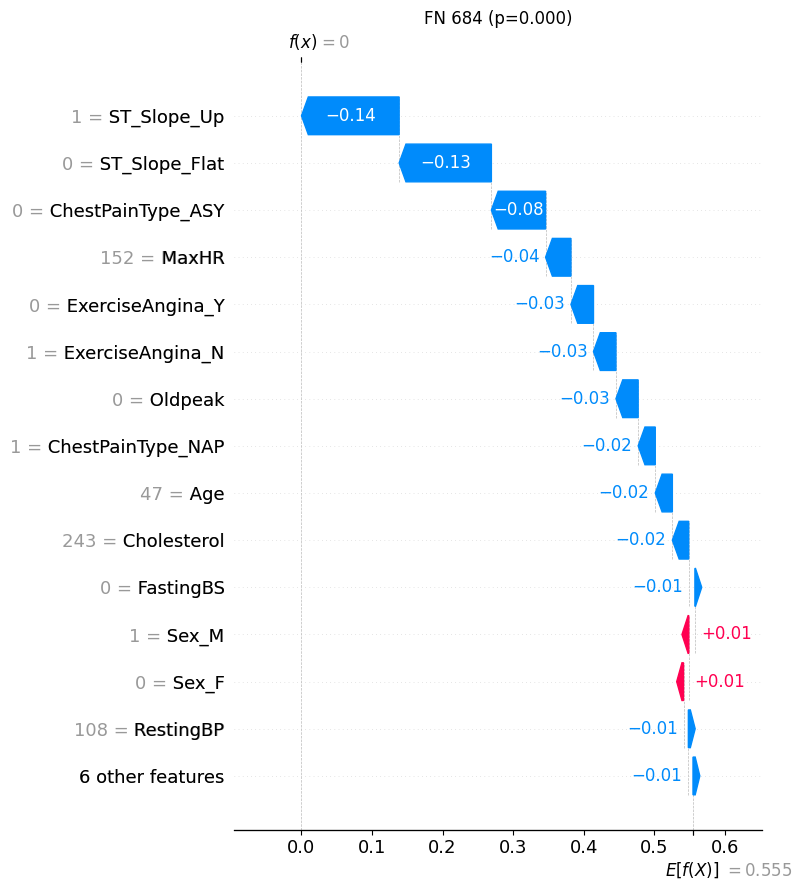

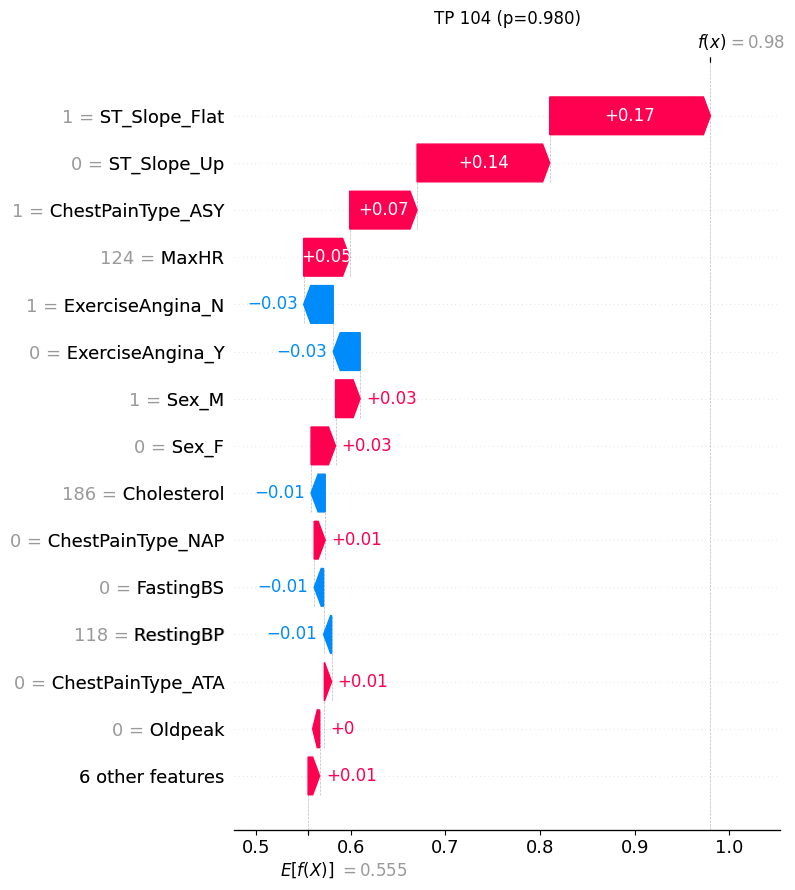

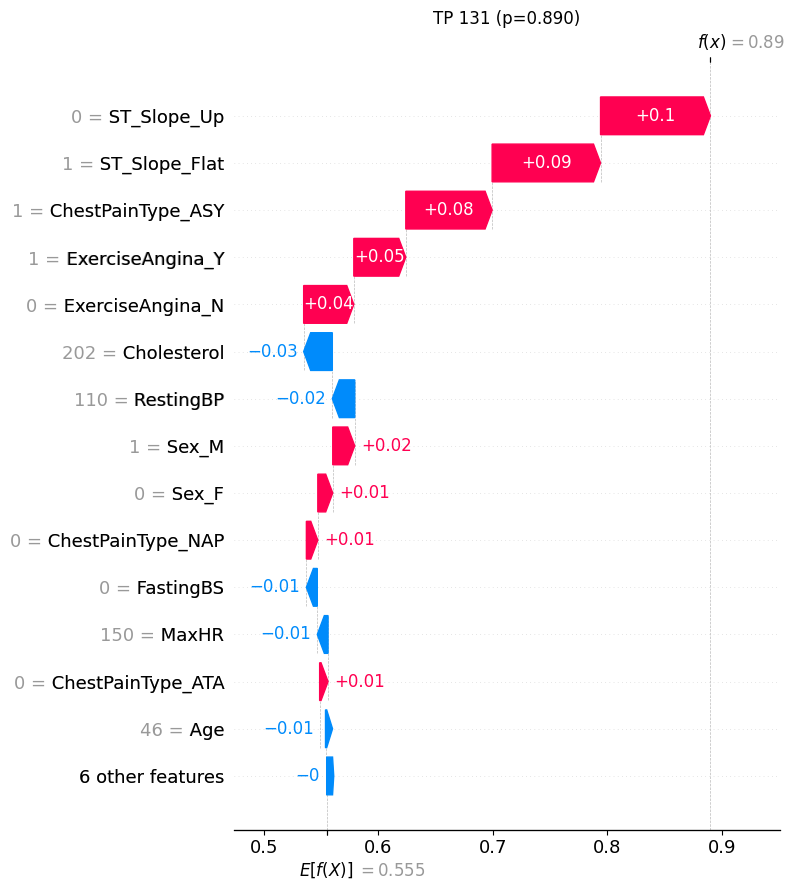

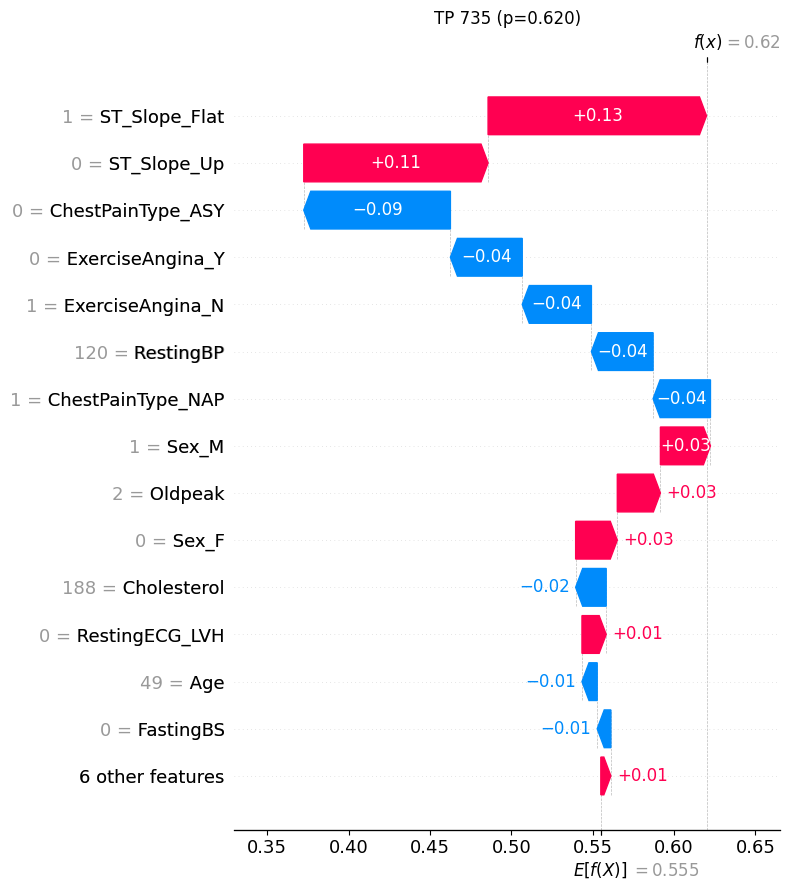

,feature,FN_val,FN_SHAP,TP1_104_val,TP1_104_SHAP,TP2_131_val,TP2_131_SHAP,TP3_735_val,TP3_735_SHAP,meanTP_SHAP,Delta_FN_minus_meanTP,abs_delta,delta_sign,fn_id
0,ST_Slope_Up,1.0,-0.138,0.0,0.140,0.0,0.096,0.0,0.113,0.116,-0.255,0.255,-1,684
1,ST_Slope_Flat,0.0,-0.131,1.0,0.170,1.0,0.095,1.0,0.134,0.133,-0.264,0.264,-1,684
2,ChestPainType_ASY,0.0,-0.077,1.0,0.071,1.0,0.075,0.0,-0.090,0.019,-0.096,0.096,-1,684
3,MaxHR,152.0,-0.036,124.0,0.049,150.0,-0.009,139.0,0.001,0.013,-0.049,0.049,-1,684
4,ExerciseAngina_Y,0.0,-0.032,0.0,-0.028,1.0,0.045,0.0,-0.044,-0.009,-0.023,0.023,-1,684
5,ExerciseAngina_N,1.0,-0.032,1.0,-0.031,0.0,0.044,1.0,-0.043,-0.010,-0.022,0.022,-1,684
6,Oldpeak,0.0,-0.031,0.0,0.005,0.0,-0.004,2.0,0.026,0.009,-0.041,0.041,-1,684
7,Age,47.0,-0.024,46.0,0.004,46.0,-0.005,49.0,-0.009,-0.004,-0.021,0.021,-1,684
8,ChestPainType_NAP,1.0,-0.024,0.0,0.012,0.0,0.010,1.0,-0.035,-0.005,-0.020,0.020,-1,684
9,Cholesterol,243.0,-0.023,186.0,-0.015,202.0,-0.025,188.0,-0.019,-0.020,-0.004,0.004,-1,684


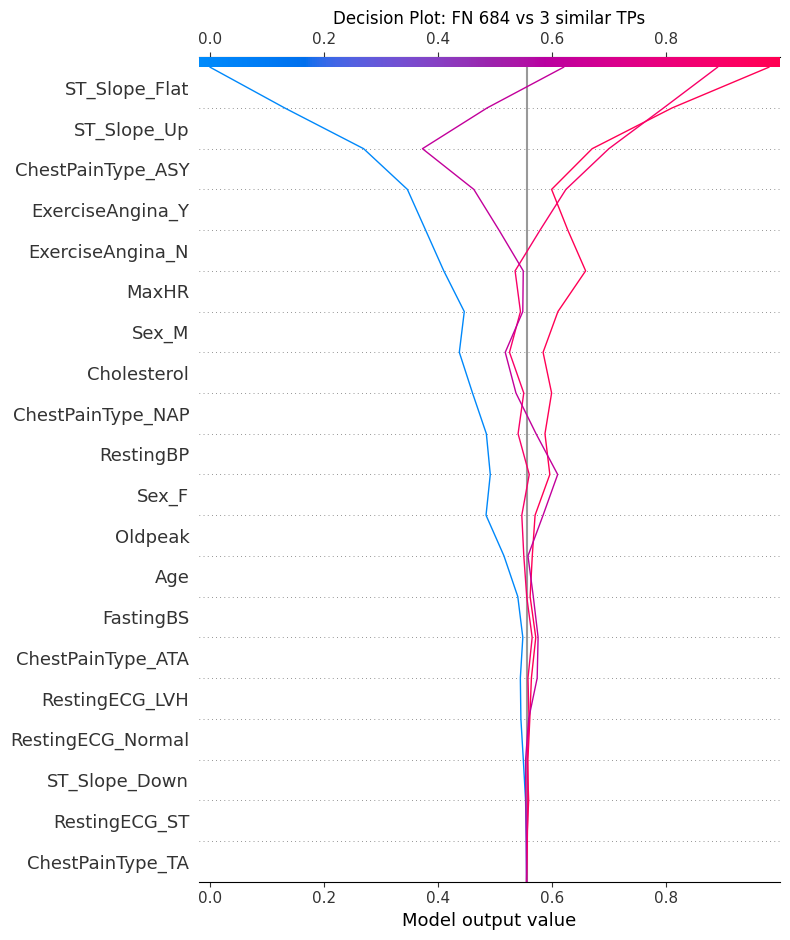

In [126]:
fn_id = 684

# 1) Tabelle (Top-8 Features nach |FN_SHAP|)
waterfall_table= make_waterfall_compare_table(fn_id, k=3)

fn_id_example = fn_cases.sort_values("y_proba").index[0]
compare_fn_to_tps(fn_id_example, k=3)
display(waterfall_table)  

# 2) Decision Plot (danach)
matches = plot_decision_for_fn_group(fn_id, k=3)

Im Folgenden analysieren wir exemplarisch den False-Negative-Fall **ID 684**, um zu verstehen, warum das Modell eine tatsächlich kranke Person mit sehr hoher Sicherheit als gesund einstuft (`p(krank) = 0.00`). Ziel dieser Analyse ist es, **an einem konkreten Beispiel** zu zeigen, wie lokale XAI-Erklärungen (Waterfall-Tabelle und Decision Plot) zu interpretieren sind.

Die Analyse erfolgt **nicht isoliert**, sondern im Vergleich zu **drei sehr ähnlichen True-Positive-Fällen**, die vom Modell korrekt als krank erkannt wurden. Dadurch lässt sich untersuchen, **bei welchen Merkmalen sich der False Negative systematisch von typischen True Positives unterscheidet**, obwohl die Patienten im Feature-Space ähnlich sind.

Der Fokus liegt dabei explizit auf der Kennzahl **`mean_abs_delta`**, also der **mittleren absoluten Abweichung der SHAP-Werte zwischen dem False Negative und den ähnlichsten True Positives**. Diese Kennzahl misst **die Stärke der Abweichung eines Features über vergleichbare Fälle hinweg**, unabhängig von der Richtung des Effekts, und bildet damit die **zentrale Größe der lokalen Analyse**.

Die Erkenntnisse aus diesem Einzelfall werden anschließend **über alle False Negatives hinweg aggregiert**, anstatt jeden Fehlfall einzeln ausführlich zu diskutieren.


### Das Feature *ST_Slope* – medizinischer Hintergrund

In der folgenden Untersuchung wird insbesondere das Feature **ST_Slope** betrachtet, da es im Vergleich zwischen False Negative und ähnlichen True Positives eine der **höchsten mittleren absoluten Abweichungen (`mean_abs_delta`)** aufweist. Das Feature beschreibt das Verhalten der ST-Strecke im Belastungs-EKG. Vereinfacht gilt:

- **ST_Slope_Up (ansteigend)** → meist unauffällig  
- **ST_Slope_Flat (flach)** → auffällig  
- **ST_Slope_Down (abfallend)** → stark auffällig, hohes Risiko  

Medizinisch betrachtet ist **ST_Slope_Down** das deutlichste Warnsignal, während **ST_Slope_Up** eher als harmlos gilt und **ST_Slope_Flat** eine Zwischenstufe darstellt.


### Repräsentation von *ST_Slope* im Modell (One-Hot-Encoding)

Das kategoriale Merkmal *ST_Slope* wird mittels **One-Hot-Encoding (OHE)** in drei binäre Spalten überführt:

- `ST_Slope_Up`
- `ST_Slope_Flat`
- `ST_Slope_Down`

Dabei ist pro Patient **genau eine dieser Spalten auf 1 gesetzt**, die übrigen haben den Wert 0.

Für Patient **684** gilt:
- `ST_Slope_Up = 1`
- `ST_Slope_Flat = 0`
- `ST_Slope_Down = 0`

Das Modell verarbeitet somit **kein medizinisches Label**, sondern ein **konkretes Muster aus binären Eingaben**, das es während des Trainings mit Zielwerten verknüpft hat.


### Interpretation der Waterfall-Tabelle 

Die Waterfall-Tabelle stellt für **alle Features** gegenüber:
- die SHAP-Werte des False-Negative-Falls,
- die SHAP-Werte der drei ähnlichsten True Positives,
- sowie die **mittlere absolute Abweichung (`mean_abs_delta`) zwischen False Negative und True Positives**.

Im Zentrum der Analyse steht **nicht ein einzelner Vergleich**, sondern die **durchschnittliche Stärke der Abweichung über mehrere ähnliche Fälle hinweg**. Ein hohes `mean_abs_delta` zeigt an, dass ein Feature **beim False Negative systematisch anders wirkt als bei vergleichbaren True Positives**, unabhängig davon, ob der Effekt positiv oder negativ ist.


### Zentrale Beobachtung

Die höchsten Werte von **`mean_abs_delta`** treten bei den Features:

- **ST_Slope_Up**
- **ST_Slope_Flat**

auf.

Diese Merkmale weisen im Mittel eine **deutlich größere absolute Abweichung** zwischen False Negative und True Positives auf als alle übrigen Features.  
Sie sind damit genau jene Merkmale, **bei denen sich der False Negative am stärksten vom typischen Entscheidungsverhalten des Modells unterscheidet**.

Erst in einem zweiten Schritt wird die **Richtung dieser Abweichung** betrachtet. Während die SHAP-Werte für `ST_Slope_Up` und `ST_Slope_Flat` bei den ähnlichen True Positives im Mittel **positiv** sind, weisen sie beim False Negative **stark negative Werte** auf. Entscheidend für ihre Identifikation ist jedoch **nicht das Vorzeichen**, sondern die **konsistent hohe mittlere Abweichung**, ausgedrückt durch `mean_abs_delta`.


### Warum *mean_abs_delta* entscheidend ist

Der zentrale Erkenntnisgewinn liegt darin, dass wenige Features eine **stabile und über mehrere Vergleichsfälle hinweg konsistente Abweichung** vom typischen Krankheitsmuster zeigen.

Die hohen `mean_abs_delta`-Werte verdeutlichen, dass die Kombination aus:
- `ST_Slope_Up = 1`
- `ST_Slope_Flat = 0`

beim False Negative **eine untypische Modellreaktion auslöst**, die sich im Durchschnitt klar von der Reaktion bei ähnlichen True Positives unterscheidet. Andere Merkmale wie Cholesterin, MaxHR oder Oldpeak weisen zwar ebenfalls SHAP-Effekte auf, ihre **mittleren absoluten Abweichungen sind jedoch deutlich geringer**.

Die Fehlklassifikation entsteht somit nicht durch ein einzelnes fehlendes Risikosignal, sondern durch eine **systematische Abweichung in wenigen, stark wirksamen Features**, die das Entscheidungsverhalten des Modells dominieren.


### Interpretation des Decision Plots

Der Decision Plot bestätigt diese **mean_abs_delta-basierte Interpretation** auf Prozessebene.  
Die Vorhersage des False-Negative-Falls (blaue Linie) unterscheidet sich bereits sehr früh im Entscheidungsprozess deutlich vom mittleren Verlauf der True Positives.

Die größten Abweichungen treten erneut bei:

- `ST_Slope_Up`
- `ST_Slope_Flat`

auf, genau jenen Features mit den höchsten `mean_abs_delta`-Werten. Nach dieser frühen Phase ist die Modellentscheidung weitgehend festgelegt; spätere Features tragen nur noch geringfügig zur verbleibenden Abweichung bei.


### Rolle von *ST_Slope_Down*

Obwohl **ST_Slope_Down** medizinisch hoch relevant ist, zeigt dieses Feature in dieser Analyse nur eine sehr geringe mittlere Abweichung (`mean_abs_delta ≈ 0`). Der Grund ist, dass `ST_Slope_Down = 0` sowohl beim False Negative als auch bei den betrachteten True Positives vorliegt.

Ein niedriger `mean_abs_delta`-Wert bedeutet hier **keine medizinische Irrelevanz**, sondern lediglich, dass dieses Feature **keinen Beitrag zur Unterscheidung zwischen FN und TP in diesem Vergleich leistet**.


### Zusammenfassung des Einzelfalls

Der False-Negative-Fall **ID 684** ist kein Grenzfall nahe der Entscheidungsschwelle, sondern das Ergebnis einer **klaren und konsistenten Abweichung vom typischen True-Positive-Muster**:

- Die größten Unterschiede liegen bei den Features mit dem höchsten **`mean_abs_delta`**
- Diese Abweichungen sind über mehrere ähnliche Vergleichsfälle stabil
- Wenige Merkmale dominieren die Modellentscheidung
- Dadurch wird das Krankheitsrisiko systematisch unterschätzt

Dieser Einzelfall zeigt exemplarisch, wie lokale Modellentscheidungen durch **konsistente Abweichungen einzelner Features** geprägt sein können und bildet die Grundlage für die **aggregierte Analyse aller False Negatives**.

---

## 2) FN_ID:1

FN: 1 proba: 0.27


,fn_id,tp_id,rank,distance,fn_proba,tp_proba
0,1,264,1,2.310927,0.27,0.72
1,1,281,2,2.647454,0.27,0.97
2,1,735,3,2.779110,0.27,0.62


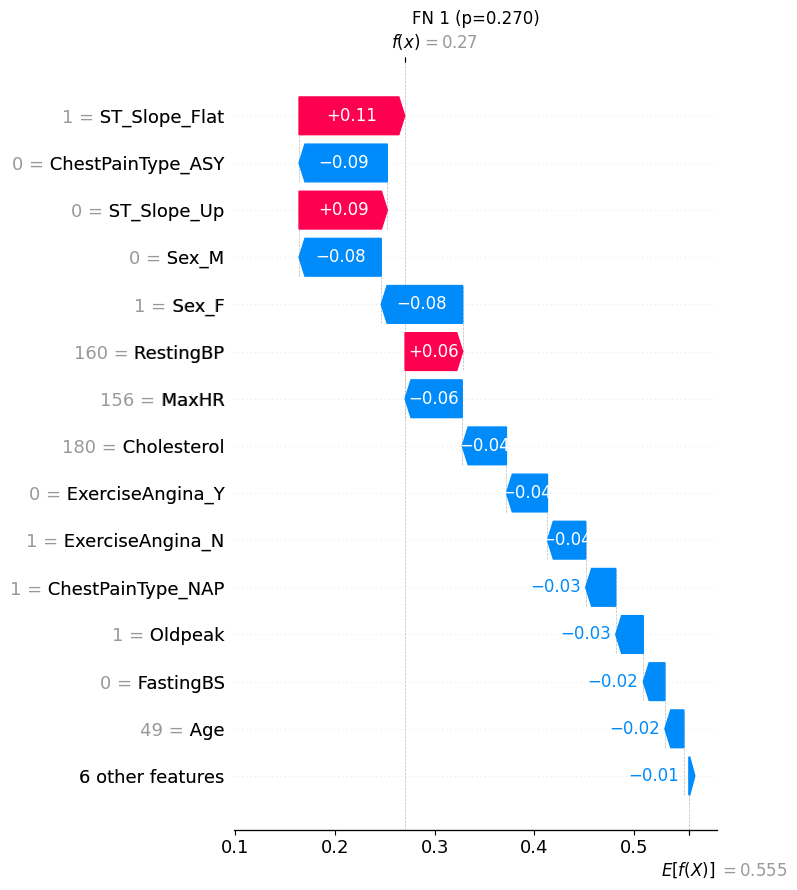

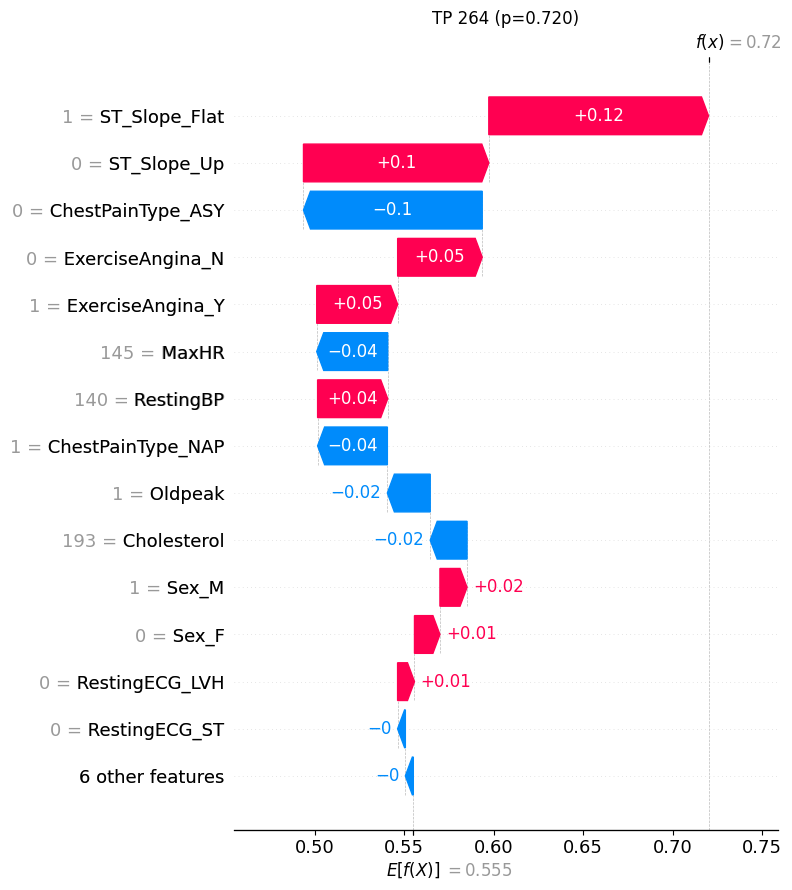

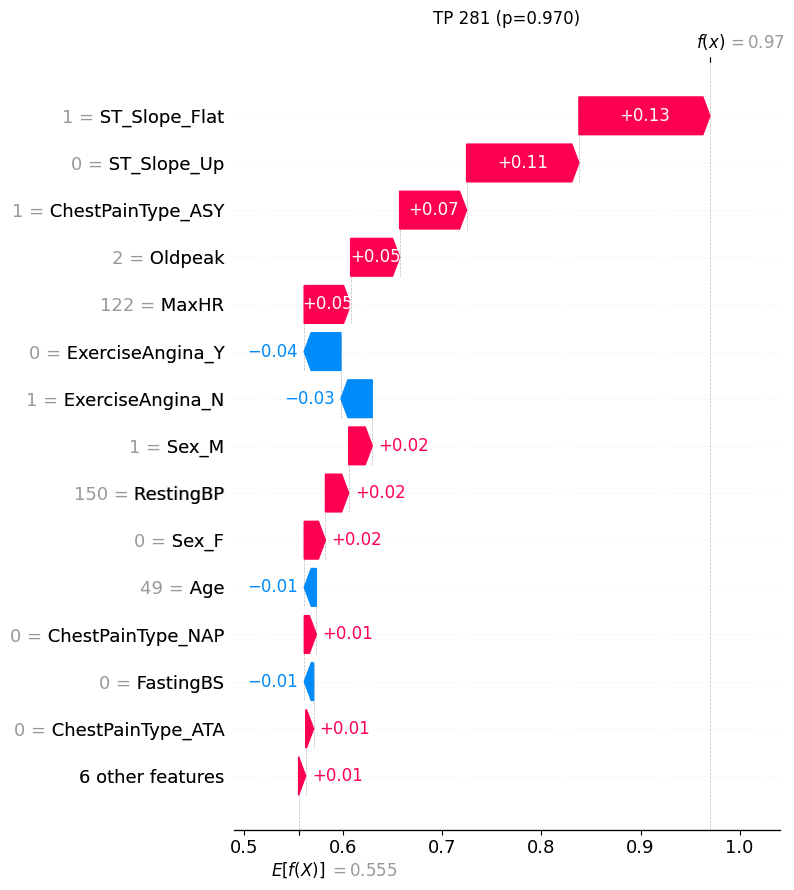

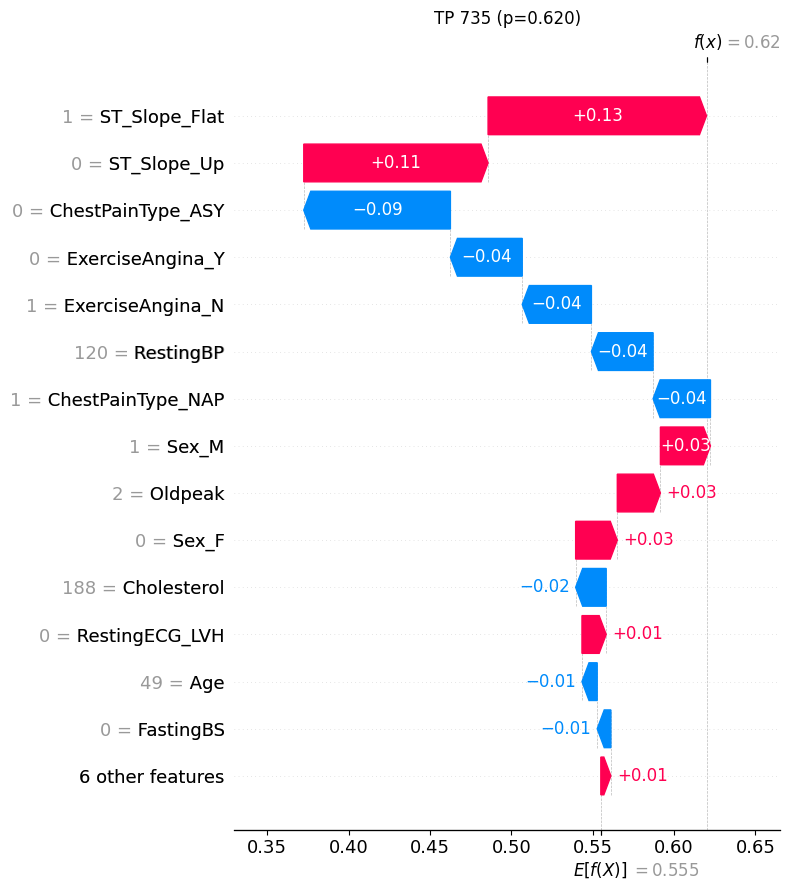

,feature,FN_val,FN_SHAP,TP1_264_val,TP1_264_SHAP,TP2_281_val,TP2_281_SHAP,TP3_735_val,TP3_735_SHAP,meanTP_SHAP,Delta_FN_minus_meanTP,abs_delta,delta_sign,fn_id
0,ST_Slope_Flat,1.0,0.106,1.0,0.123,1.0,0.132,1.0,0.134,0.130,-0.024,0.024,-1,1
1,ST_Slope_Up,0.0,0.089,0.0,0.104,0.0,0.113,0.0,0.113,0.110,-0.022,0.022,-1,1
2,ChestPainType_ASY,0.0,-0.089,0.0,-0.100,1.0,0.068,0.0,-0.090,-0.041,-0.048,0.048,-1,1
3,Sex_F,1.0,-0.082,0.0,0.014,0.0,0.021,0.0,0.026,0.020,-0.102,0.102,-1,1
4,Sex_M,0.0,-0.082,1.0,0.015,1.0,0.024,1.0,0.031,0.023,-0.106,0.106,-1,1
5,RestingBP,160.0,0.058,140.0,0.039,150.0,0.023,120.0,-0.038,0.008,0.050,0.050,1,1
6,MaxHR,156.0,-0.057,145.0,-0.040,122.0,0.047,139.0,0.001,0.003,-0.060,0.060,-1,1
7,Cholesterol,180.0,-0.044,193.0,-0.021,222.0,-0.002,188.0,-0.019,-0.014,-0.030,0.030,-1,1
8,ExerciseAngina_Y,0.0,-0.041,1.0,0.045,0.0,-0.037,0.0,-0.044,-0.012,-0.029,0.029,-1,1
9,ExerciseAngina_N,1.0,-0.038,0.0,0.047,1.0,-0.032,1.0,-0.043,-0.009,-0.029,0.029,-1,1


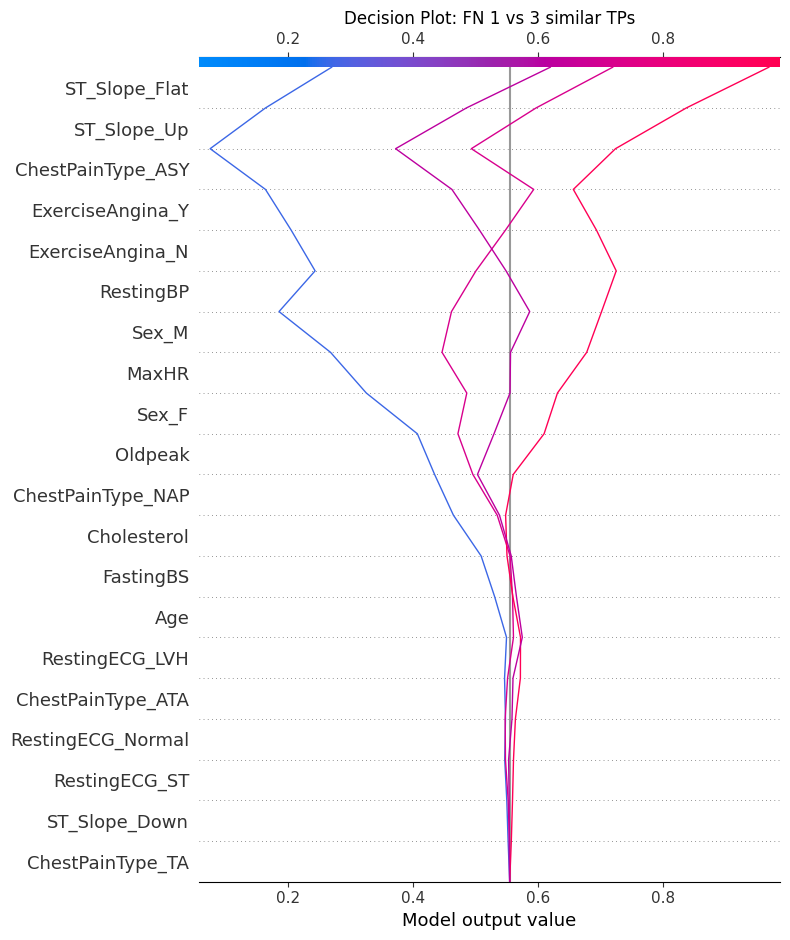

In [127]:
fn_id = 1

waterfall_table = make_waterfall_compare_table(fn_id, k=3)

fn_id_example = fn_cases.sort_values("y_proba").index[4]
compare_fn_to_tps(fn_id_example, k=3)
display(waterfall_table)   

matches = plot_decision_for_fn_group(fn_id, k=3)

## 3) FN_ID: 440

FN: 440 proba: 0.41


,fn_id,tp_id,rank,distance,fn_proba,tp_proba
3,440,492,1,2.432686,0.41,0.70
4,440,735,2,3.261938,0.41,0.62
5,440,337,3,3.459791,0.41,0.70


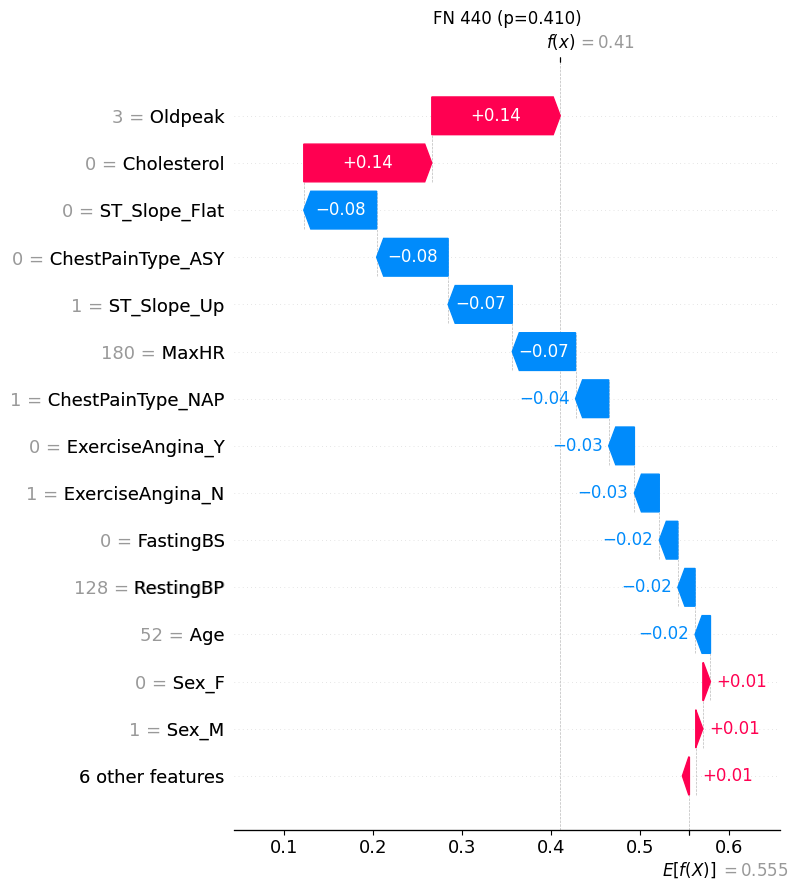

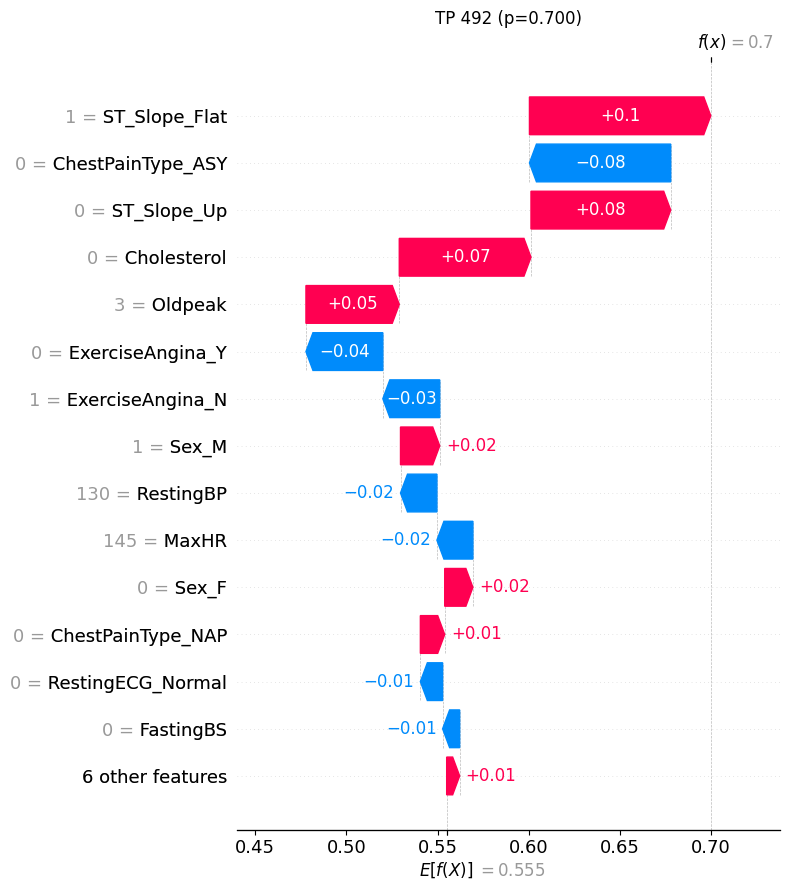

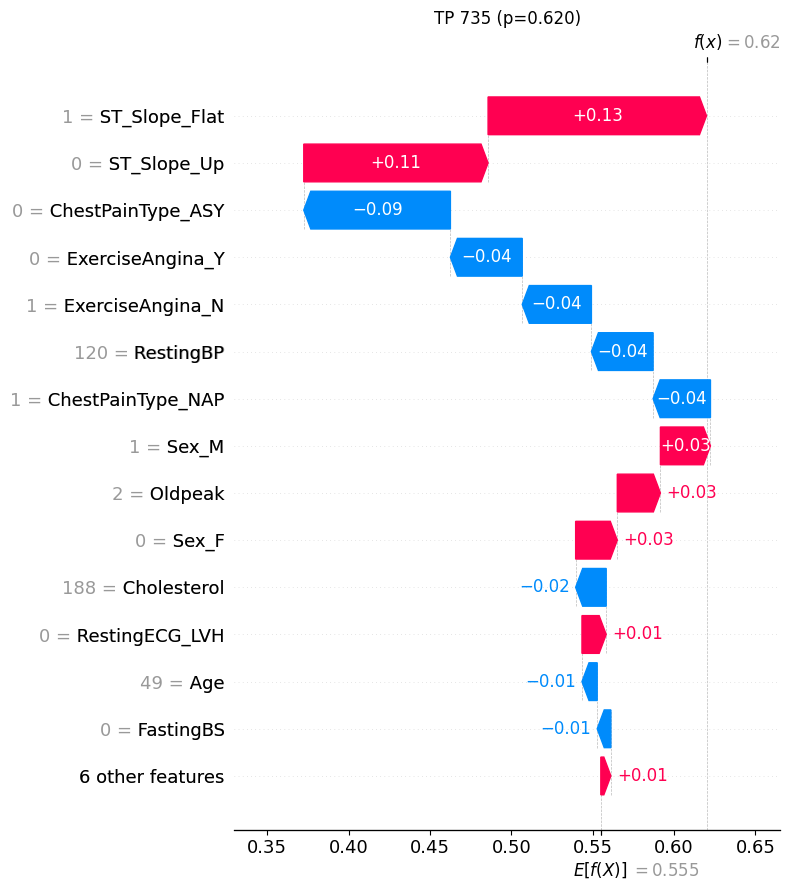

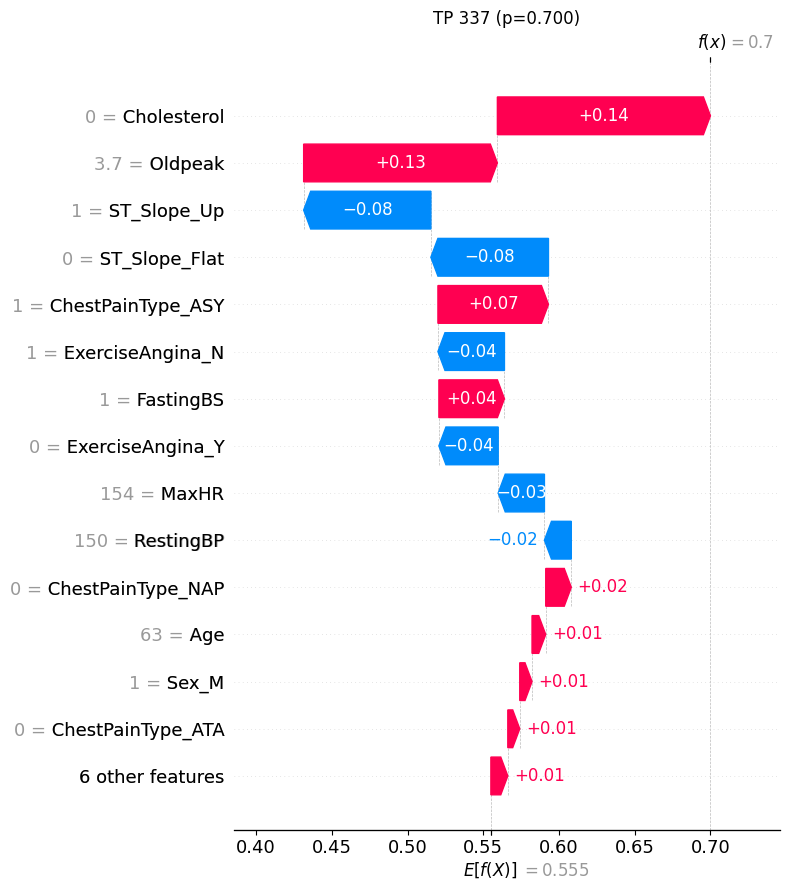

,feature,FN_val,FN_SHAP,TP1_492_val,TP1_492_SHAP,TP2_735_val,TP2_735_SHAP,TP3_337_val,TP3_337_SHAP,meanTP_SHAP,Delta_FN_minus_meanTP,abs_delta,delta_sign,fn_id
0,Cholesterol,0.0,0.144,0.0,0.072,188.0,-0.019,0.0,0.141,0.065,0.079,0.079,1,440
1,Oldpeak,3.0,0.144,3.0,0.051,2.0,0.026,3.7,0.128,0.069,0.076,0.076,1,440
2,ST_Slope_Flat,0.0,-0.082,1.0,0.100,1.0,0.134,0.0,-0.078,0.052,-0.134,0.134,-1,440
3,ChestPainType_ASY,0.0,-0.080,0.0,-0.078,0.0,-0.090,1.0,0.073,-0.032,-0.049,0.049,-1,440
4,ST_Slope_Up,1.0,-0.072,0.0,0.077,0.0,0.113,1.0,-0.084,0.035,-0.107,0.107,-1,440
5,MaxHR,180.0,-0.071,145.0,-0.020,139.0,0.001,154.0,-0.031,-0.016,-0.055,0.055,-1,440
6,ChestPainType_NAP,1.0,-0.037,0.0,0.013,1.0,-0.035,0.0,0.017,-0.002,-0.036,0.036,-1,440
7,ExerciseAngina_Y,0.0,-0.029,0.0,-0.042,0.0,-0.044,0.0,-0.039,-0.042,0.013,0.013,1,440
8,ExerciseAngina_N,1.0,-0.028,1.0,-0.031,1.0,-0.043,1.0,-0.044,-0.039,0.011,0.011,1,440
9,FastingBS,0.0,-0.021,0.0,-0.009,0.0,-0.008,1.0,0.043,0.009,-0.029,0.029,-1,440


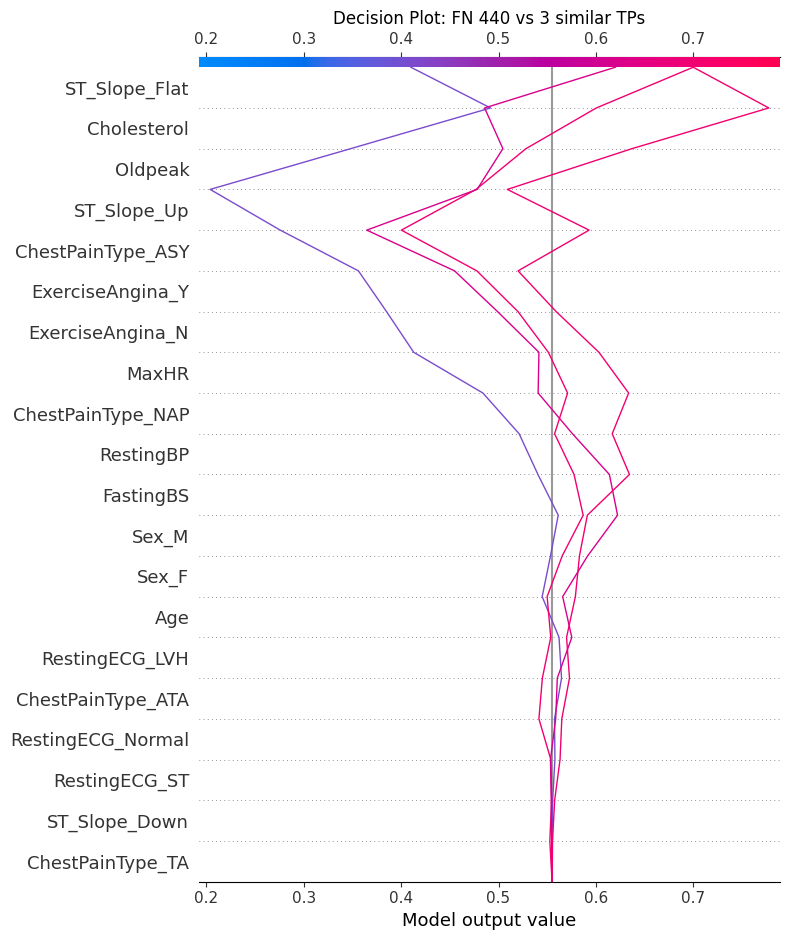

In [128]:
fn_id = 440

waterfall_table = make_waterfall_compare_table(fn_id, k=3)

fn_id_example = fn_cases.sort_values("y_proba").index[5]
compare_fn_to_tps(fn_id_example, k=3)
display(waterfall_table)   

matches = plot_decision_for_fn_group(fn_id, k=3)

## 4) FN_ID: 759

FN: 759 proba: 0.23


,fn_id,tp_id,rank,distance,fn_proba,tp_proba
9,759,581,1,4.267965,0.23,0.74
10,759,585,2,4.388495,0.23,0.82
11,759,651,3,4.521571,0.23,0.87


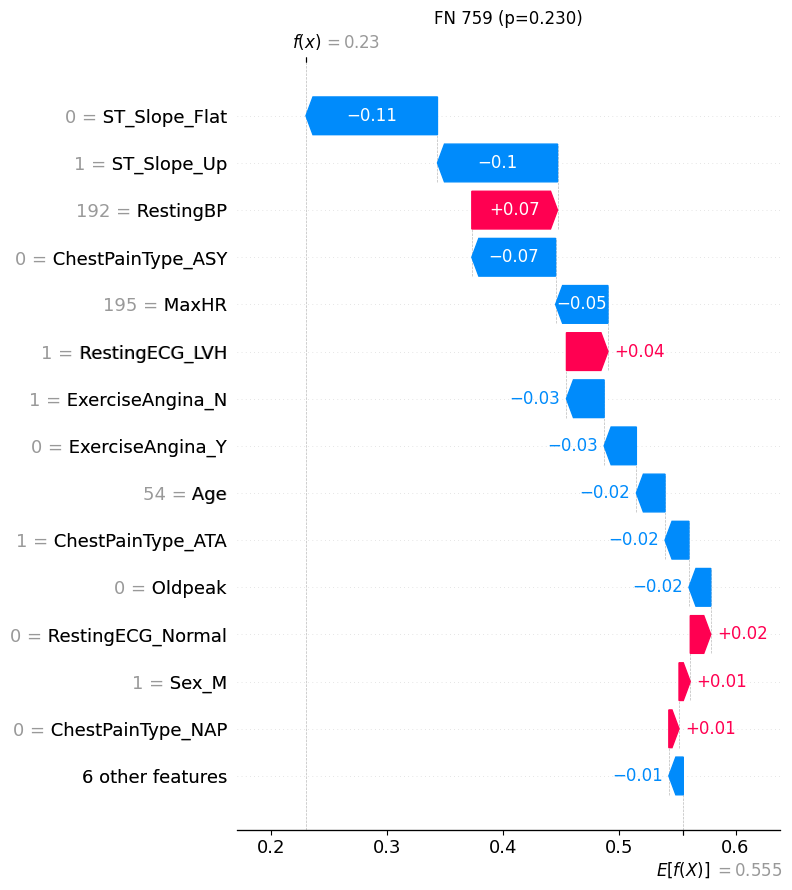

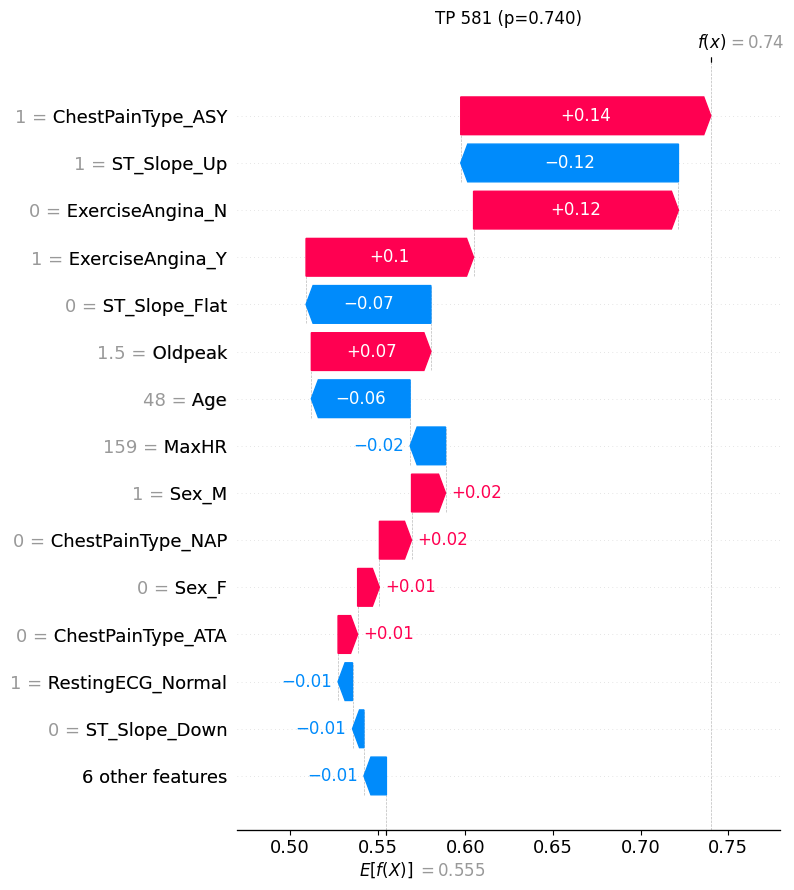

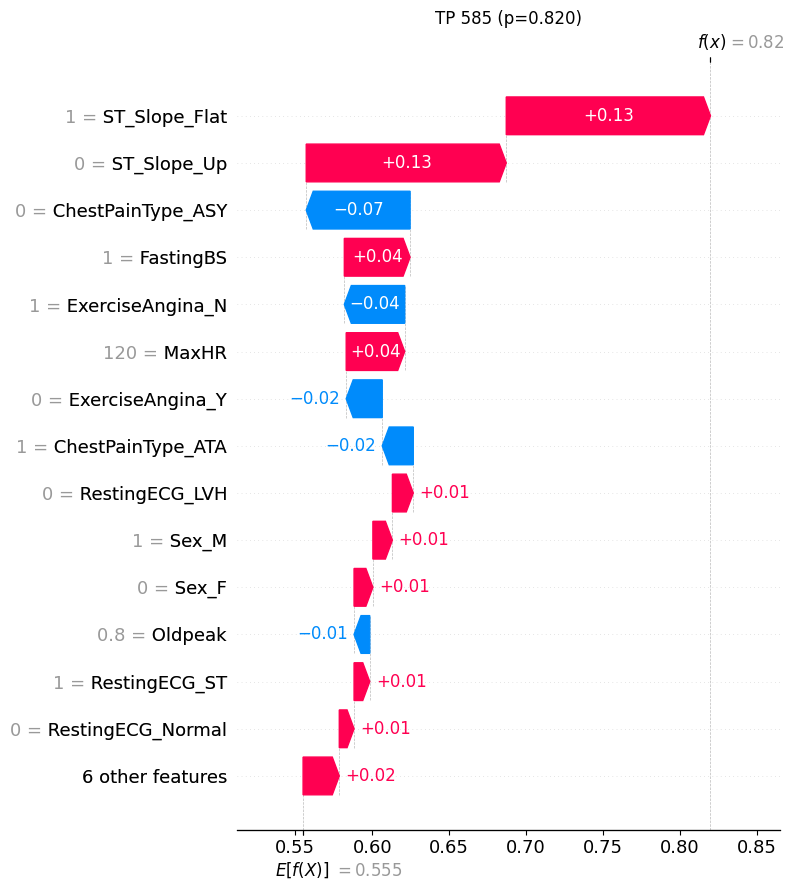

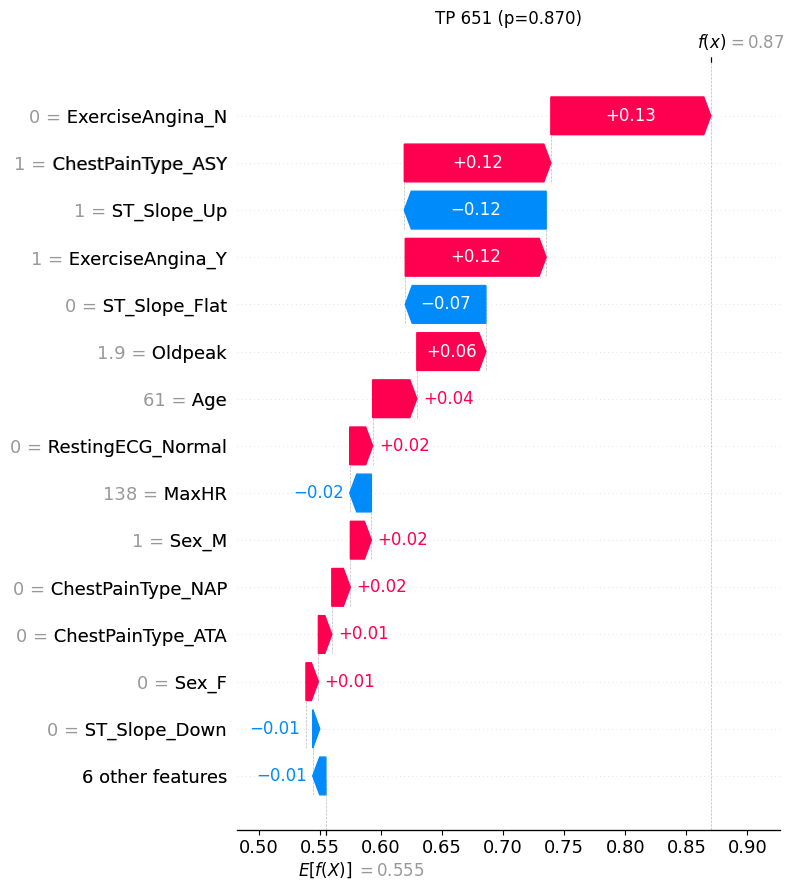

,feature,FN_val,FN_SHAP,TP1_581_val,TP1_581_SHAP,TP2_585_val,TP2_585_SHAP,TP3_651_val,TP3_651_SHAP,meanTP_SHAP,Delta_FN_minus_meanTP,abs_delta,delta_sign,fn_id
0,ST_Slope_Flat,0.0,-0.113,0.0,-0.071,1.0,0.133,0.0,-0.066,-0.001,-0.112,0.112,-1,759
1,ST_Slope_Up,1.0,-0.103,1.0,-0.124,0.0,0.130,1.0,-0.116,-0.037,-0.067,0.067,-1,759
2,RestingBP,192.0,0.074,140.0,-0.005,180.0,0.004,140.0,-0.004,-0.002,0.076,0.076,1,759
3,ChestPainType_ASY,0.0,-0.072,1.0,0.143,0.0,-0.068,1.0,0.120,0.065,-0.137,0.137,-1,759
4,MaxHR,195.0,-0.045,159.0,-0.020,120.0,0.038,138.0,-0.018,0.000,-0.045,0.045,-1,759
5,RestingECG_LVH,1.0,0.036,0.0,-0.002,0.0,0.014,1.0,0.003,0.005,0.031,0.031,1,759
6,ExerciseAngina_N,1.0,-0.032,0.0,0.117,1.0,-0.039,0.0,0.131,0.069,-0.102,0.102,-1,759
7,ExerciseAngina_Y,0.0,-0.028,1.0,0.096,0.0,-0.023,1.0,0.115,0.062,-0.090,0.090,-1,759
8,Age,54.0,-0.025,48.0,-0.056,57.0,0.003,61.0,0.036,-0.006,-0.019,0.019,-1,759
9,ChestPainType_ATA,1.0,-0.021,0.0,0.011,1.0,-0.020,0.0,0.011,0.001,-0.021,0.021,-1,759


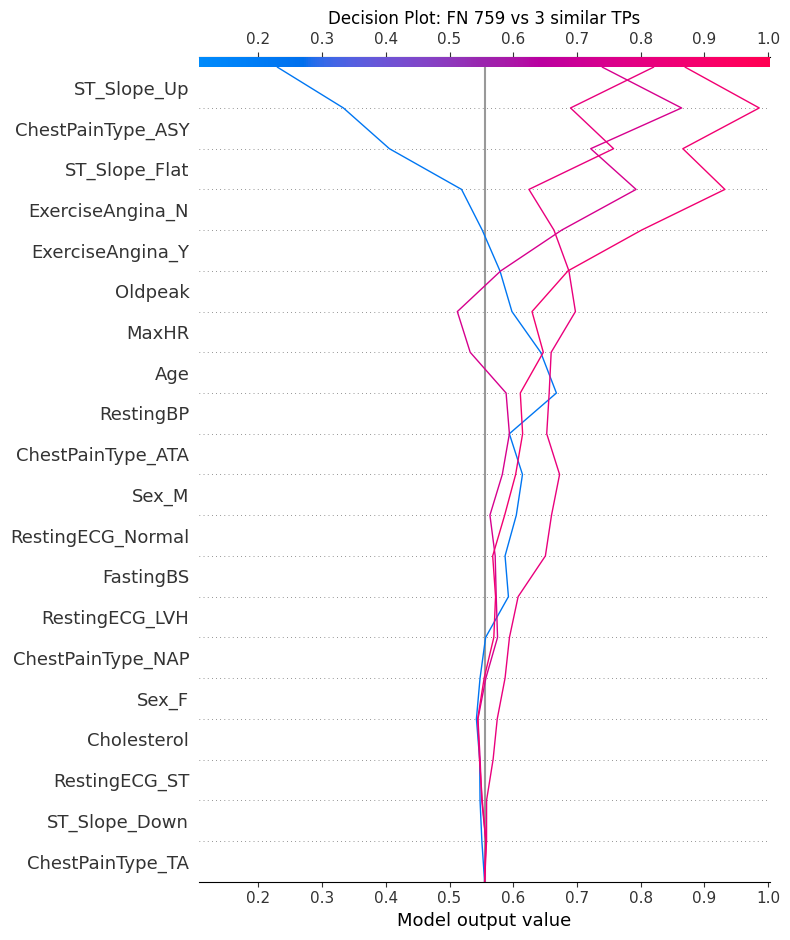

In [129]:
fn_id = 759

waterfall_table = make_waterfall_compare_table(fn_id, k=3)

fn_id_example = fn_cases.sort_values("y_proba").index[2]
compare_fn_to_tps(fn_id_example, k=3)
display(waterfall_table)   

matches = plot_decision_for_fn_group(fn_id, k=3)

## 5) FN_ID: 763

FN: 763 proba: 0.26


,fn_id,tp_id,rank,distance,fn_proba,tp_proba
12,763,786,1,2.429525,0.26,0.64
13,763,651,2,2.754583,0.26,0.87
14,763,735,3,2.890340,0.26,0.62


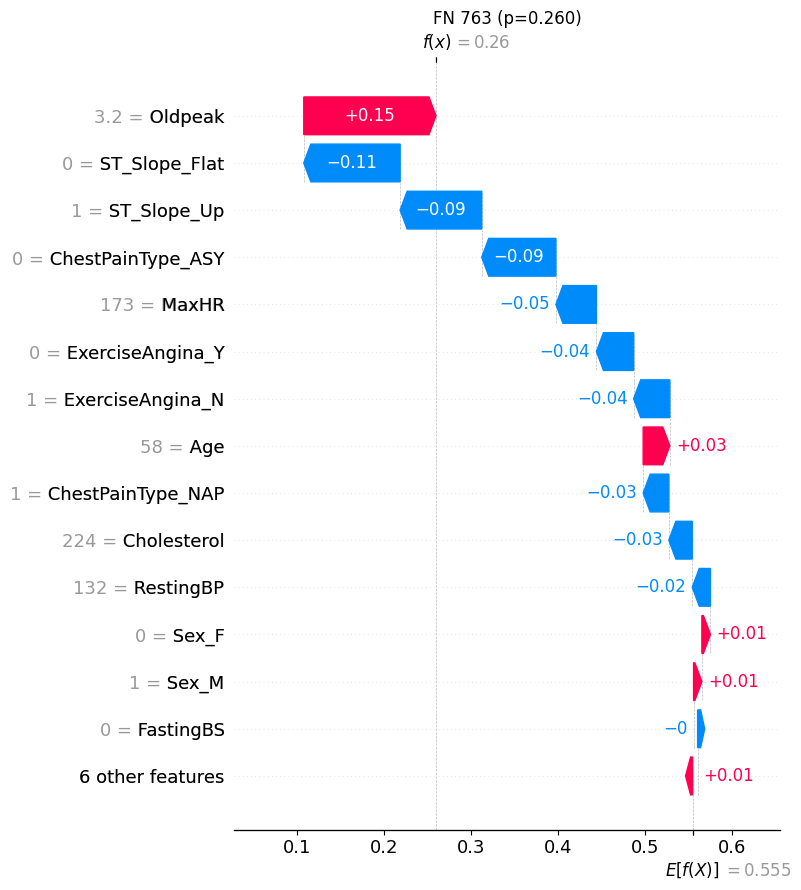

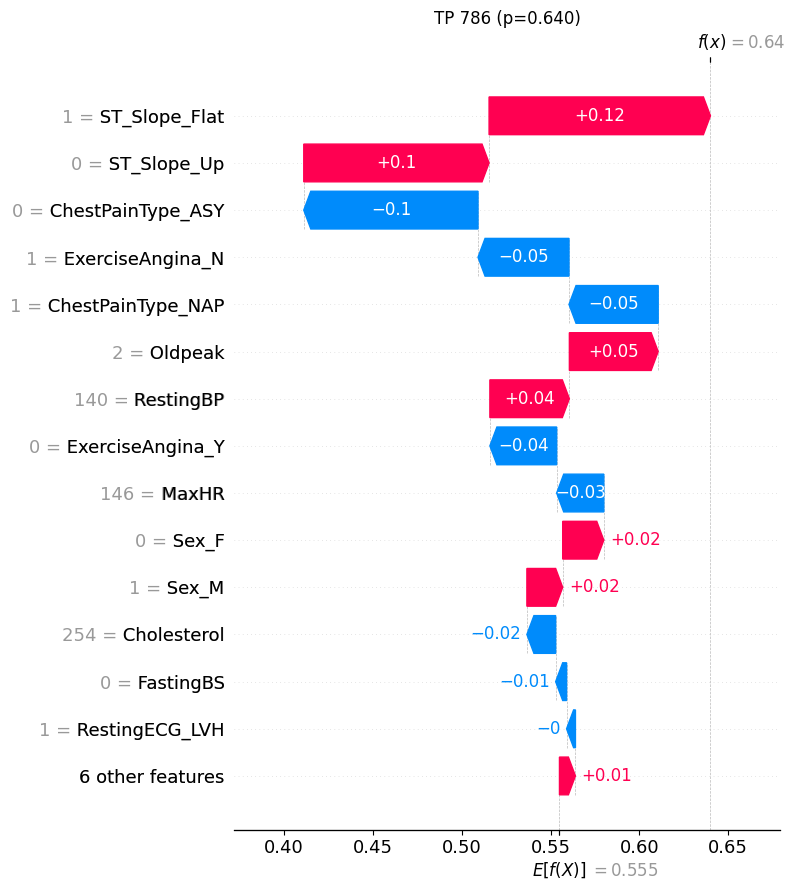

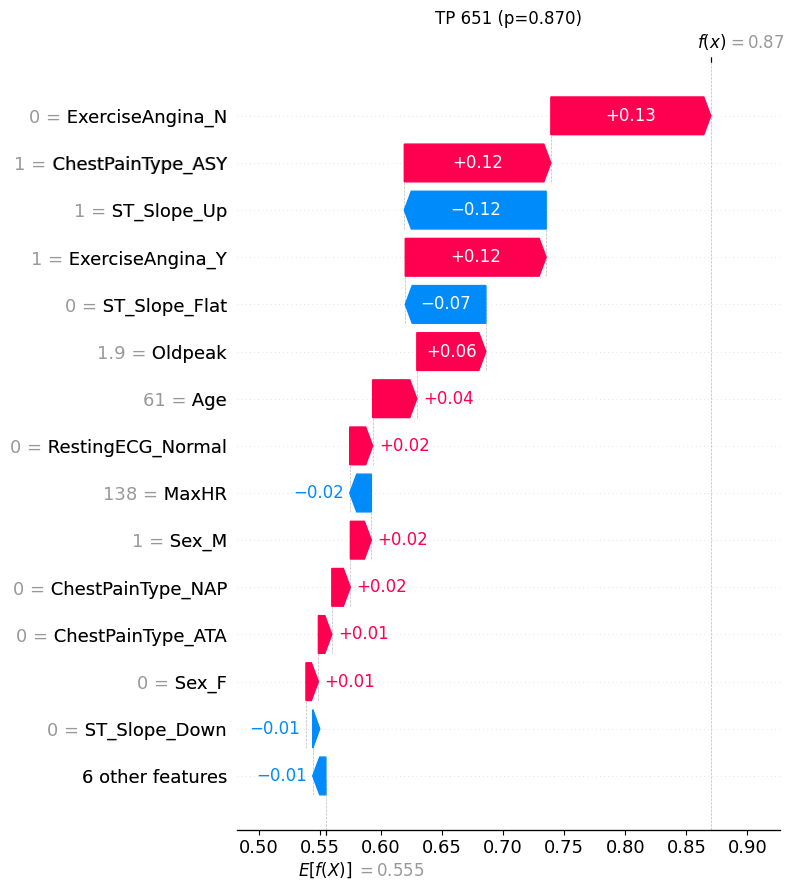

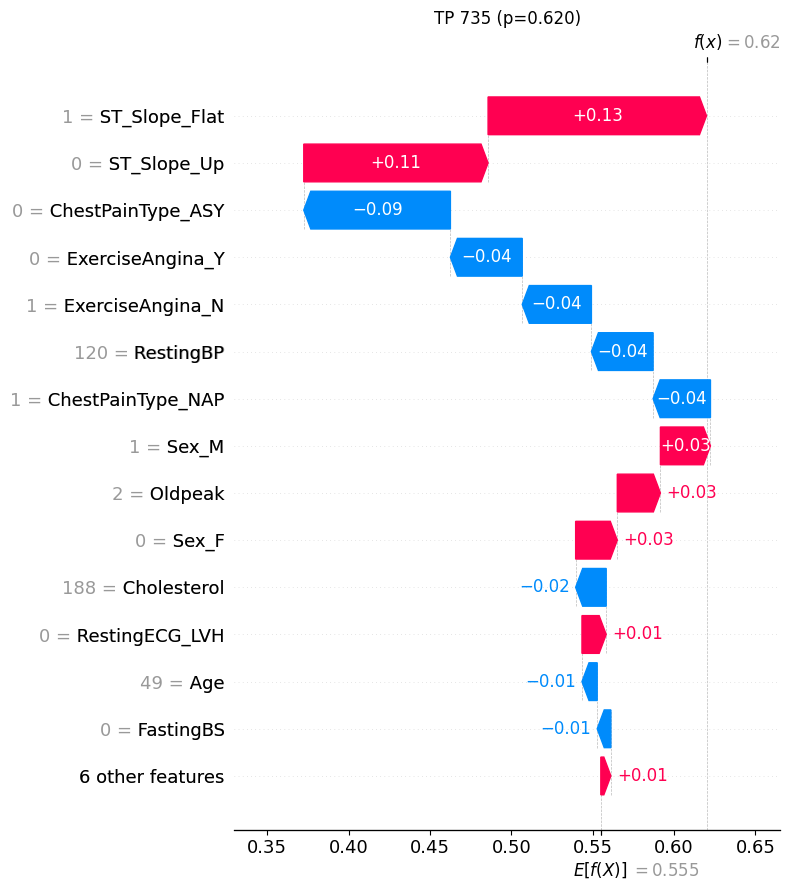

,feature,FN_val,FN_SHAP,TP1_786_val,TP1_786_SHAP,TP2_651_val,TP2_651_SHAP,TP3_735_val,TP3_735_SHAP,meanTP_SHAP,Delta_FN_minus_meanTP,abs_delta,delta_sign,fn_id
0,Oldpeak,3.2,0.152,2.0,0.050,1.9,0.056,2.0,0.026,0.044,0.108,0.108,1,763
1,ST_Slope_Flat,0.0,-0.111,1.0,0.125,0.0,-0.066,1.0,0.134,0.064,-0.175,0.175,-1,763
2,ST_Slope_Up,1.0,-0.094,0.0,0.104,1.0,-0.116,0.0,0.113,0.034,-0.128,0.128,-1,763
3,ChestPainType_ASY,0.0,-0.085,0.0,-0.098,1.0,0.120,0.0,-0.090,-0.023,-0.063,0.063,-1,763
4,MaxHR,173.0,-0.047,146.0,-0.027,138.0,-0.018,139.0,0.001,-0.014,-0.032,0.032,-1,763
5,ExerciseAngina_Y,0.0,-0.043,0.0,-0.038,1.0,0.115,0.0,-0.044,0.011,-0.054,0.054,-1,763
6,ExerciseAngina_N,1.0,-0.042,1.0,-0.051,0.0,0.131,1.0,-0.043,0.012,-0.054,0.054,-1,763
7,Age,58.0,0.031,69.0,0.003,61.0,0.036,49.0,-0.009,0.010,0.021,0.021,1,763
8,ChestPainType_NAP,1.0,-0.029,1.0,-0.050,0.0,0.015,1.0,-0.035,-0.023,-0.006,0.006,-1,763
9,Cholesterol,224.0,-0.027,254.0,-0.016,207.0,-0.003,188.0,-0.019,-0.013,-0.014,0.014,-1,763


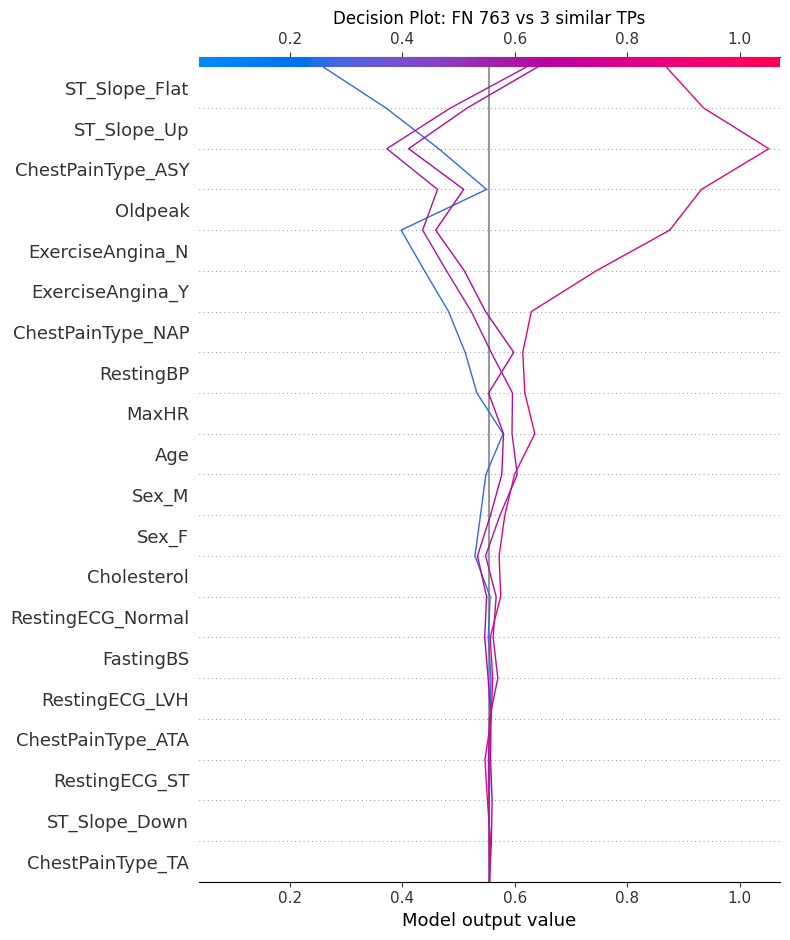

In [130]:
fn_id = 763

waterfall_table = make_waterfall_compare_table(fn_id, k=3)

fn_id_example = fn_cases.sort_values("y_proba").index[3]
compare_fn_to_tps(fn_id_example, k=3)
display(waterfall_table)   

matches = plot_decision_for_fn_group(fn_id, k=3)

## 6) FN_ID: 889

FN: 889 proba: 0.09


,fn_id,tp_id,rank,distance,fn_proba,tp_proba
15,889,581,1,2.419694,0.09,0.74
16,889,735,2,2.772903,0.09,0.62
17,889,651,3,2.837886,0.09,0.87


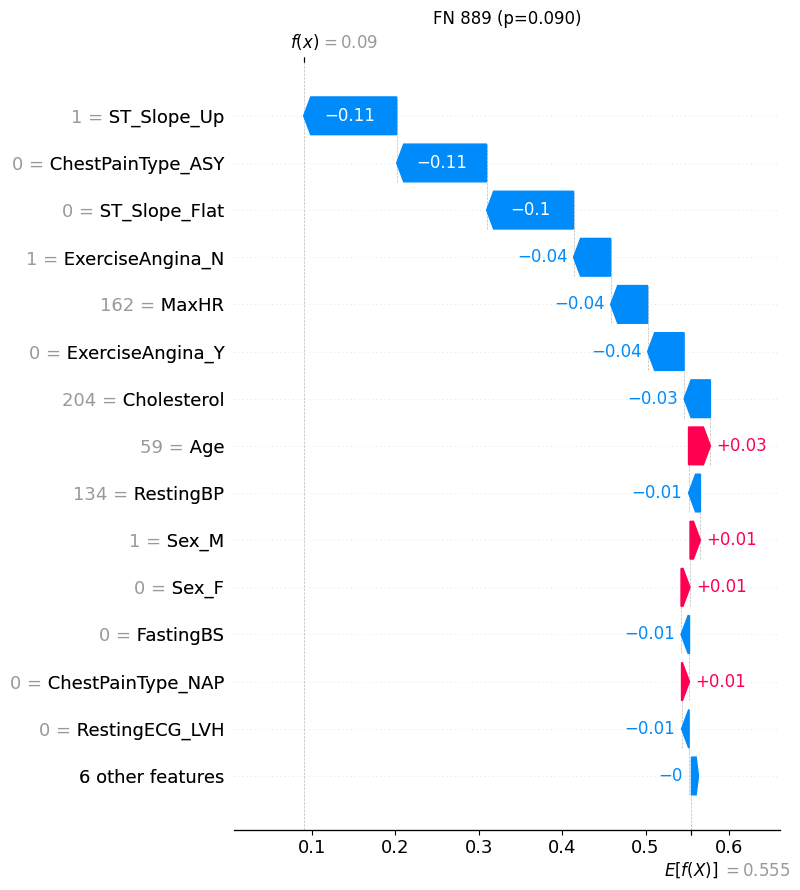

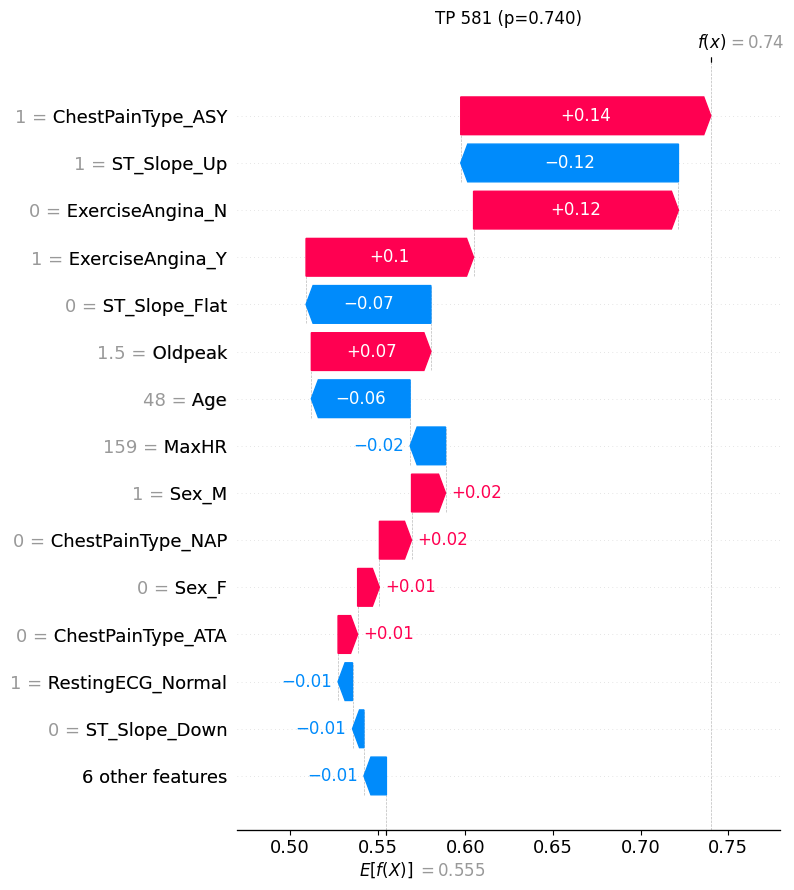

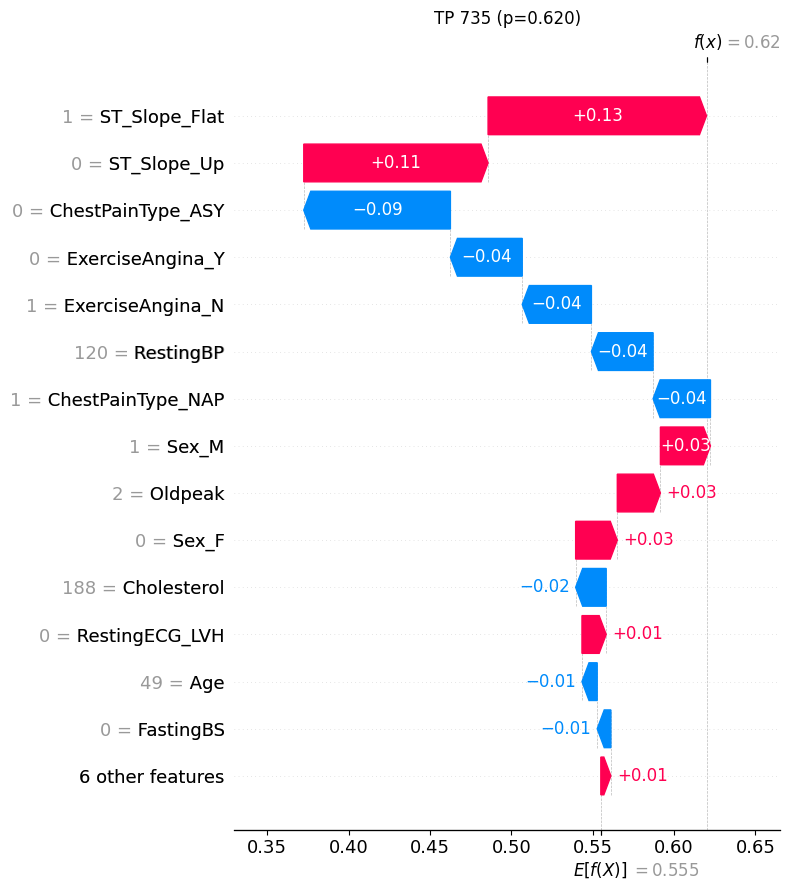

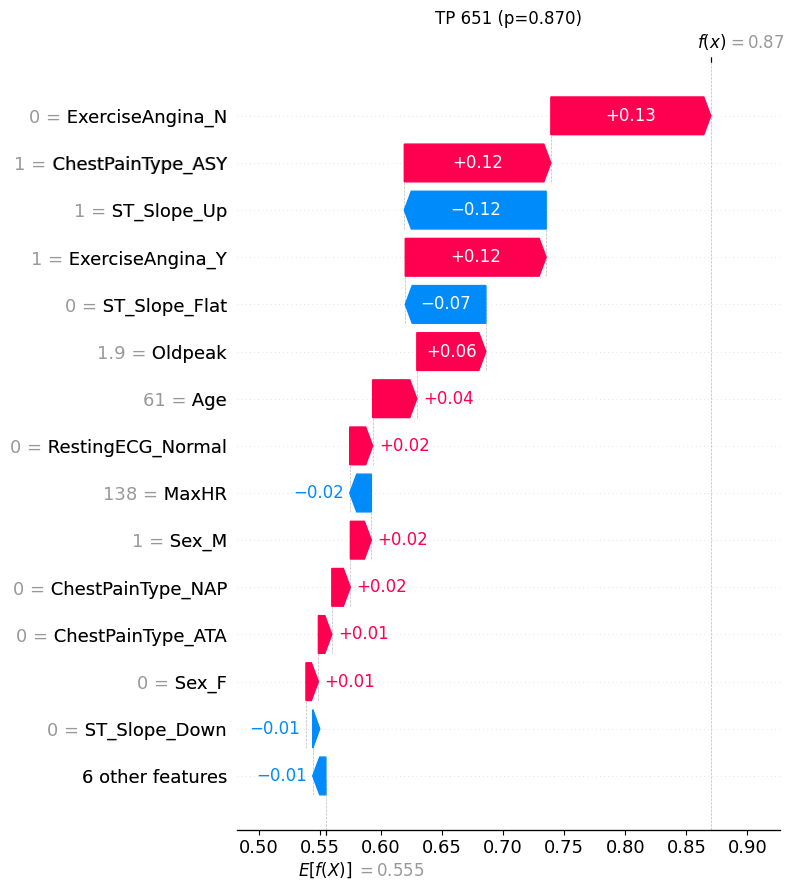

,feature,FN_val,FN_SHAP,TP1_581_val,TP1_581_SHAP,TP2_735_val,TP2_735_SHAP,TP3_651_val,TP3_651_SHAP,meanTP_SHAP,Delta_FN_minus_meanTP,abs_delta,delta_sign,fn_id
0,ST_Slope_Up,1.0,-0.112,1.0,-0.124,0.0,0.113,1.0,-0.116,-0.042,-0.069,0.069,-1,889
1,ChestPainType_ASY,0.0,-0.108,1.0,0.143,0.0,-0.090,1.0,0.120,0.057,-0.165,0.165,-1,889
2,ST_Slope_Flat,0.0,-0.104,0.0,-0.071,1.0,0.134,0.0,-0.066,-0.001,-0.103,0.103,-1,889
3,ExerciseAngina_N,1.0,-0.045,0.0,0.117,1.0,-0.043,0.0,0.131,0.068,-0.113,0.113,-1,889
4,MaxHR,162.0,-0.044,159.0,-0.020,139.0,0.001,138.0,-0.018,-0.012,-0.032,0.032,-1,889
5,ExerciseAngina_Y,0.0,-0.044,1.0,0.096,0.0,-0.044,1.0,0.115,0.056,-0.099,0.099,-1,889
6,Cholesterol,204.0,-0.032,208.0,-0.003,188.0,-0.019,207.0,-0.003,-0.008,-0.023,0.023,-1,889
7,Age,59.0,0.026,48.0,-0.056,49.0,-0.009,61.0,0.036,-0.010,0.036,0.036,1,889
8,RestingBP,134.0,-0.014,140.0,-0.005,120.0,-0.038,140.0,-0.004,-0.016,0.001,0.001,1,889
9,Sex_M,1.0,0.012,1.0,0.019,1.0,0.031,1.0,0.017,0.022,-0.010,0.010,-1,889


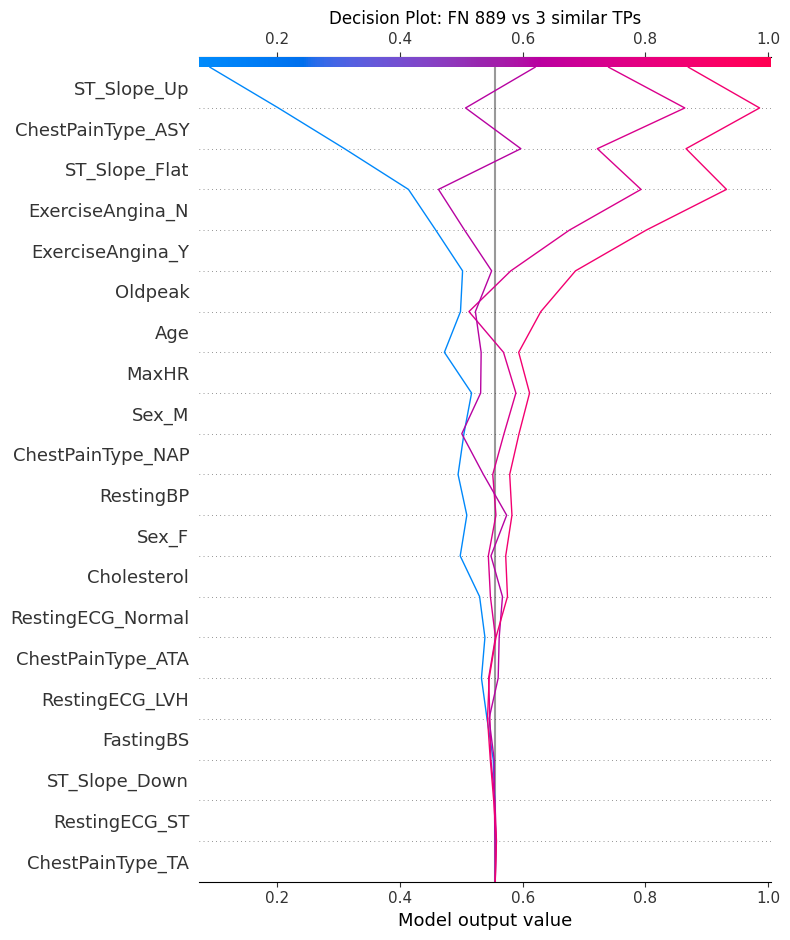

In [131]:
fn_id = 889

waterfall_table = make_waterfall_compare_table(fn_id, k=3)

fn_id_example = fn_cases.sort_values("y_proba").index[1]
compare_fn_to_tps(fn_id_example, k=3)
display(waterfall_table)   

matches = plot_decision_for_fn_group(fn_id, k=3)

## Entwicklung der Meta-Tabelle

In [132]:
def shap_row_for_index(sample_id, X_test_processed, shap_values_1):
    row_pos = X_test_processed.index.get_loc(sample_id)
    return pd.Series(shap_values_1[row_pos], index=X_test_processed.columns, name=sample_id)

def is_binary_ohe_feature(col_series: pd.Series) -> bool:
    s = col_series.dropna()
    if s.empty:
        return False
    uniq = set(np.unique(s.values))
    return uniq.issubset({0, 1, 0.0, 1.0})


# 1) Einzeltabelle pro FN: ALLE Features (FN vs mean(TPs))
#    Sortierung nach FN_SHAP absteigend (wie du wolltest)

def make_full_compare_table_for_fn(
    fn_id,
    knn_matches_df,
    X_test_processed,
    shap_values_1,
    k_neighbors=3,
    sort_by="FN_SHAP",          
    ascending=False
):
    # passende TPs holen
    matches = (knn_matches_df[knn_matches_df["fn_id"] == fn_id]
               .sort_values("rank")
               .head(k_neighbors))
    tp_ids = matches["tp_id"].tolist()

    # Werte: FN + TPs
    fn_vals = X_test_processed.loc[fn_id]
    tp_vals = X_test_processed.loc[tp_ids]                 # (k, n_features)
    mean_tp_vals = tp_vals.mean(axis=0)                    # (n_features)

    # SHAP: FN + TPs
    fn_shap = shap_row_for_index(fn_id, X_test_processed, shap_values_1)
    tp_shaps = pd.concat(
        [shap_row_for_index(tp_id, X_test_processed, shap_values_1) for tp_id in tp_ids],
        axis=1
    )
    mean_tp_shap = tp_shaps.mean(axis=1)

    delta = fn_shap - mean_tp_shap

    df = pd.DataFrame({
        "feature": X_test_processed.columns,
        "FN_val": fn_vals.values,
        "meanTP_val": mean_tp_vals.values,
        "FN_SHAP": fn_shap.values,
        "meanTP_SHAP": mean_tp_shap.values,
        "Delta_FN_minus_meanTP": delta.values,
        "abs_FN_SHAP": np.abs(fn_shap.values),
        "abs_Delta": np.abs(delta.values),
        "fn_id": fn_id
    })

    
    df["FN_SHAP"] = df["FN_SHAP"].astype(float).round(3)
    df["meanTP_SHAP"] = df["meanTP_SHAP"].astype(float).round(3)
    df["Delta_FN_minus_meanTP"] = df["Delta_FN_minus_meanTP"].astype(float).round(3)

    df["FN_val"] = df["FN_val"].astype(float)
    df["meanTP_val"] = df["meanTP_val"].astype(float)

    # Sortierung
    if sort_by == "abs_FN_SHAP":
        df = df.sort_values("abs_FN_SHAP", ascending=ascending).reset_index(drop=True)
    else:
        df = df.sort_values("FN_SHAP", ascending=ascending).reset_index(drop=True)

    return df, matches, tp_ids

# 2) Meta-Tabelle über alle FNs 
#    - OHE/Binary: getrennte Zeilen Feature=0 / Feature=1
#    - Numerisch: eine Zeile pro Feature


def build_meta_table_over_all_fns_no_mixing(
    fn_ids,
    knn_matches_df,
    X_test_processed,
    shap_values_1,
    k_neighbors=3
):
    # welche Features sind binary/ohe?
    binary_mask = {col: is_binary_ohe_feature(X_test_processed[col]) for col in X_test_processed.columns}

    all_rows = []
    for fn_id in fn_ids:
        per_fn_df, matches, tp_ids = make_full_compare_table_for_fn(
            fn_id=fn_id,
            knn_matches_df=knn_matches_df,
            X_test_processed=X_test_processed,
            shap_values_1=shap_values_1,
            k_neighbors=k_neighbors,
            sort_by="FN_SHAP",
            ascending=False
        )

        # Key bauen: bei binary => "feature=FN_val" sonst nur "feature"
        # dadurch werden z.B. ST_Slope_Up=0 und ST_Slope_Up=1 NICHT vermischt
        def make_key(row):
            feat = row["feature"]
            if binary_mask.get(feat, False):
                # FN_val kann float sein -> sauber zu int
                v = int(round(float(row["FN_val"])))
                return f"{feat}={v}"
            else:
                return feat

        per_fn_df["meta_key"] = per_fn_df.apply(make_key, axis=1)

        # Vorzeichen für Konsistenz
        per_fn_df["delta_sign"] = np.sign(per_fn_df["Delta_FN_minus_meanTP"].astype(float)).astype(int)

        all_rows.append(per_fn_df)

    long_df = pd.concat(all_rows, ignore_index=True)

    # sign consistency
    def sign_consistency(x: pd.Series) -> float:
        counts = x.value_counts()
        return float(counts.max() / counts.sum()) if counts.sum() else np.nan

    meta = (long_df.groupby(["meta_key"], as_index=False)
            .agg(
                feature=("feature", "first"),
                is_binary=("feature", lambda s: bool(binary_mask.get(s.iloc[0], False))),

                # wie oft kommt es in den 6 FN-Fällen vor?
                freq=("fn_id", "nunique"),

                # Werte 
                mean_FN_val=("FN_val", "mean"),
                mean_meanTP_val=("meanTP_val", "mean"),

                # SHAP / Delta Kennzahlen
                mean_FN_SHAP=("FN_SHAP", "mean"),
                mean_meanTP_SHAP=("meanTP_SHAP", "mean"),
                mean_delta=("Delta_FN_minus_meanTP", "mean"),
                mean_abs_delta=("Delta_FN_minus_meanTP", lambda x: np.mean(np.abs(x.astype(float)))),

                sign_consistency=("delta_sign", sign_consistency),
            ))

    # Formatierung
    n_fns = len(fn_ids)
    meta["freq"] = meta["freq"].astype(int).astype(str) + f"/{n_fns}"
    meta["sign_consistency"] = (meta["sign_consistency"] * 100).round(0).astype(int).astype(str) + " %"

    # runden
    for c in ["mean_FN_val", "mean_meanTP_val", "mean_FN_SHAP", "mean_meanTP_SHAP", "mean_delta", "mean_abs_delta"]:
        meta[c] = meta[c].astype(float).round(3)

    meta = meta.sort_values("mean_abs_delta", ascending=False).reset_index(drop=True)

    return meta, long_df

Nun werden die bisherigen **lokalen FN–TP-Vergleiche** von der Einzelfallebene auf eine **strukturierte, übergreifende Analyse** erweitert.

Zunächst wird für einen einzelnen **False-Negative-Fall** eine  
**vollständige Vergleichstabelle** erzeugt, die für **alle Features**

- die Feature-Werte und SHAP-Beiträge des FN
- den **durchschnittlichen SHAP-Beiträgen** seiner *k* ähnlichsten **True Positives**

gegenüberstellt. Dadurch wird sichtbar,

- **welche Features den FN systematisch in Richtung „gesund“ drücken**,  
- verglichen mit sehr ähnlichen, korrekt klassifizierten Fällen.

Darauf aufbauend werden diese Vergleichstabellen über **alle False-Negative-Fälle aggregiert**.

Dabei gilt:

- **Binäre (One-Hot-kodierte) Features**
  - werden sauber nach Ausprägung (**0 / 1**) getrennt,
- **Numerische Features**
  - werden **nicht vermischt**, sondern getrennt behandelt.

Das Ergebnis ist eine **Meta-Tabelle**, die zeigt,

- welche Merkmale **über mehrere False Negatives hinweg**
- **konsistent zur Fehlklassifikation beitragen**,

inklusive

- **Häufigkeit** des Auftretens,
- **mittlerem SHAP-Effekt**,
- und **Vorzeichenstabilität**.

Diese Aggregation bildet die Brücke von **lokaler XAI**  zu Anzeige von **systematischen Modellschwächen**.

## Aggregierte XAI-Analyse über alle False-Negative-Fälle

In [133]:
fn_ids = fn_cases.index.tolist()     # die 6 FN-IDs
K_NEIGHBORS = 3

meta_table, long_table = build_meta_table_over_all_fns_no_mixing(
    fn_ids=fn_ids,
    knn_matches_df=knn_matches_df,
    X_test_processed=X_test_processed,
    shap_values_1=shap_values_1,
    k_neighbors=K_NEIGHBORS
)

display(meta_table)

,meta_key,feature,is_binary,freq,mean_FN_val,mean_meanTP_val,mean_FN_SHAP,mean_meanTP_SHAP,mean_delta,mean_abs_delta,sign_consistency
0,ST_Slope_Flat=0,ST_Slope_Flat,True,5/6,0.000,0.600,-0.108,0.049,-0.158,0.158,100 %
1,ST_Slope_Up=1,ST_Slope_Up,True,5/6,1.000,0.400,-0.104,0.021,-0.125,0.125,100 %
2,Sex_M=0,Sex_M,True,1/6,0.000,1.000,-0.082,0.023,-0.106,0.106,100 %
3,Sex_F=1,Sex_F,True,1/6,1.000,0.000,-0.082,0.020,-0.102,0.102,100 %
4,ChestPainType_ASY=0,ChestPainType_ASY,True,6/6,0.000,0.500,-0.085,0.008,-0.093,0.093,100 %
5,Oldpeak,Oldpeak,False,6/6,1.333,1.733,0.037,0.038,-0.001,0.062,67 %
6,ExerciseAngina_N=1,ExerciseAngina_N,True,6/6,1.000,0.611,-0.036,0.015,-0.052,0.055,83 %
7,ExerciseAngina_Y=0,ExerciseAngina_Y,True,6/6,0.000,0.389,-0.036,0.011,-0.047,0.051,83 %
8,MaxHR,MaxHR,False,6/6,169.667,140.722,-0.050,-0.004,-0.046,0.046,100 %
9,RestingBP,RestingBP,False,6/6,142.333,134.333,0.012,-0.009,0.021,0.028,83 %


Die lokale XAI-Analyse einzelner False-Negative-Fälle liefert wertvolle Einblicke in konkrete Fehlentscheidungen des Modells. Eine vollständige, detaillierte Interpretation aller sechs False Negatives würde jedoch zu starken Redundanzen führen, da sich viele Muster wiederholen und einzelne Effekte nur schwer vergleichbar wären.

Stattdessen wird im Folgenden eine **aggregierte Meta-Tabelle** betrachtet, die die lokalen SHAP-Ergebnisse **über alle sechs False-Negative-Fälle hinweg zusammenfasst**. Ziel dieser Aggregation ist es, **systematische Kippfaktoren** zu identifizieren, also Merkmale, die über mehrere Fälle hinweg konsistent zur Fehlklassifikation beitragen.

Um eine Vermischung unterschiedlicher Feature-Zustände zu vermeiden, werden **binäre bzw. One-Hot-Encoded Features getrennt nach ihrem tatsächlichen Wert (0 oder 1)** aggregiert. Die Meta-Tabelle basiert auf vollständigen lokalen Vergleichstabellen (False Negative vs. Mittelwert der jeweils drei ähnlichsten True Positives) und fasst deren Informationen featureweise zusammen.


### Bedeutung der Spalten in der Meta-Tabelle

Im Folgenden werden die einzelnen Spalten der Meta-Tabelle erläutert:

- **`feature`**  
  Name des betrachteten Features. Bei binären Features entspricht dieser der ursprünglichen Spaltenbezeichnung aus dem Modellinput.

- **`freq`**  
  Anzahl der False-Negative-Fälle, in denen dieses Feature (bzw. dieser Feature-Zustand) auftritt. Die Angabe erfolgt relativ zur Gesamtzahl der False Negatives. Sprich wenn das Feature ST_Slope_Flat=0 eine freq von `5/6` hat bedeutet das, dass in  5 von den insgesamt 6 False-Negative-Fällen das Feature den Wert = 0 hatte.
  
- **`mean_FN_val`**  
  Durchschnittlicher Feature-Wert über alle betrachteten False-Negative-Fälle.  

- **`mean_meanTP_val`**  
  Durchschnittlicher Feature-Wert der jeweils zugeordneten True-Positive-Vergleichsfälle. Dieser Wert dient als Referenz, um zu beurteilen, **ob sich False Negatives systematisch von ähnlichen True Positives unterscheiden**.

- **`mean_FN_SHAP`**  
  Mittlerer SHAP-Wert des Features über alle False-Negative-Fälle. Er beschreibt, **in welche Richtung und mit welcher Stärke** das Feature die Modellvorhersage bei False Negatives beeinflusst.

- **`mean_meanTP_SHAP`**  
  Durchschnittlicher SHAP-Wert desselben Features bei den zugehörigen True-Positive-Fällen. Dieser Wert zeigt, wie das Modell dasselbe Feature **bei korrekt klassifizierten, ähnlichen Patienten nutzt**.

- **`mean_delta`**

 $$
\text{mean\_delta}
= \frac{1}{N} \sum_{i=1}^{N}
\left( \text{FN\_SHAP}_i - \overline{\text{TP\_SHAP}_i} \right)
$$

  Der mittlere Delta-Wert beschreibt die durchschnittliche Differenz zwischen dem SHAP-Wert eines Features bei False Negatives und dem mittleren SHAP-Wert desselben Features bei den zugehörigen True-Positive-Fällen  
  
  Das Vorzeichen von `mean_delta` gibt die **Richtung des systematischen Effekts** im Mittel an:
  - ein **negativer Wert** bedeutet, dass das Feature die Vorhersage bei False Negatives im Mittel stärker in Richtung „gesund“ verschiebt als bei ähnlichen True Positives,
  - ein **positiver Wert** entsprechend stärker in Richtung „krank“.

  `mean_delta` beantwortet somit die Frage, **in welche Richtung ein Feature zur Fehlklassifikation im Durchschnitt beiträgt**, sagt jedoch noch nichts darüber aus, **wie stark** dieser Effekt ist.

- **`mean_abs_delta`**

$$
\text{mean\_abs\_delta}
= \frac{1}{N} \sum_{i=1}^{N}
\left| \text{FN\_SHAP}_i - \overline{\text{TP\_SHAP}_i} \right|
$$


  Der Wert `mean_abs_delta` ist der Mittelwert der **absoluten** Delta-Werte über alle betrachteten False-Negative-Fälle:

  Diese Kennzahl misst **die Stärke der Abweichung zwischen False Negatives und vergleichbaren True Positives**, unabhängig von der Richtung.  
  Sie beantwortet die zentrale Frage der Meta-Analyse:

  > *Wie stark unterscheidet sich die Nutzung dieses Features bei Fehlklassifikationen von der Nutzung bei korrekten Klassifikationen?*

  `mean_abs_delta` ist daher die **zentrale Bewertungssmetrik** der Meta-Tabelle. Features mit hohen Werten weisen auf **systematische Modellinkonsistenzen** hin: Das Modell behandelt sie bei sehr ähnlichen Patienten deutlich unterschiedlich, ein typisches Muster für Kippfaktoren von Fehlentscheidungen.


- **`sign_consistency`**

Die Kennzahl **sign_consistency** beschreibt den **Anteil der False-Negative-Fälle**,  
in denen das berechnete **Delta** dasselbe Vorzeichen aufweist.  
Sie gibt damit an, in wie vielen False-Negative-Fällen das **Mean_Delta**  
in **dieselbe Richtung** wirkt.

Diese Kennzahl misst **nicht die Stärke**, sondern die **Stabilität der Richtung**  
eines Feature-Effekts über mehrere Fehlklassifikationen hinweg.

**Mechanische Berechnung**

Für eine gegebene Meta-Zeile (z. B. *RestingECG_LVH = 1*) wird wie folgt vorgegangen:

- Es werden alle zugehörigen **Delta-Werte** betrachtet  
  (also alle False-Negative-Fälle, in denen dieses Feature auftritt).
- Für jedes Delta wird ausschließlich geprüft, ob es
  - **positiv** oder
  - **negativ**
  ist.
- Anschließend wird gezählt, **welches Vorzeichen häufiger vorkommt**.
- Der Anteil dieses Mehrheits-Vorzeichens entspricht der **sign_consistency**.

**Beispiel**

Angenommen, ein Feature tritt in **5 False-Negative-Fällen** auf  
und die berechneten Delta-Werte lauten:

- −0.10  
- −0.12  
- −0.08  
- +0.02  
- −0.06  

Dann ergibt sich:

- negative Deltas: **4**
- positive Deltas: **1**

Die **sign_consistency** beträgt in diesem Fall **80 %**. Das bedeutet, dass in etwa **80 % der relevanten False-Negative-Fälle** das Feature **gerichtet in dieselbe Richtung** wirkt.


## Auswahl- und Bewertungslogik der Meta-Analyse

Ziel der vorliegenden Meta-Analyse ist es **nicht**, allgemein wichtige Features des Modells zu identifizieren, sondern jene Merkmale herauszuarbeiten,  **die systematisch zur Entstehung von False-Negative-Fehlklassifikationen beitragen**.

Im Fokus steht damit nicht die generelle Modellwichtigkeit einzelner Variablen, sondern die Frage:

> **Wodurch unterscheiden sich False Negatives konsistent von sehr ähnlichen, korrekt klassifizierten True Positives?**


### Grundidee der Bewertungslogik

Entscheidend ist **nicht**, wie stark ein Feature im Durchschnitt bei False-Negative-Fällen wirkt, sondern **wie stark sich seine Nutzung bei Fehlklassifikationen von der Nutzung bei vergleichbaren korrekt klassifizierten Fällen unterscheidet**. Genau auf diesen Unterschied zielt die hier verwendete Bewertungslogik ab.

### Zentrales Auswahlkriterium: mean_abs_delta

Das zentrale Auswahlkriterium der Meta-Analyse ist der **mean_abs_delta**-Wert.

Er misst direkt,

- wie stark sich die SHAP-Werte eines Features bei False Negatives  
- von den **mittleren SHAP-Werten desselben Features bei den jeweils zugeordneten True-Positive-Nachbarn** unterscheiden.

Damit quantifiziert **mean_abs_delta**

- die **Stärke der Abweichung** zwischen Fehl- und Nicht-Fehlentscheidungen,
- **unabhängig von deren Richtung**.

Features mit hohen **mean_abs_delta**-Werten werden vom Modell bei False Negatives deutlich anders genutzt als bei vergleichbaren True Positives  
und stellen damit **potenzielle Kippfaktoren von Fehlentscheidungen** dar.


### Abgrenzung zu mean_FN_SHAP

Andere naheliegende Kennzahlen wie **mean_FN_SHAP** sind hierfür nur eingeschränkt geeignet, denn**mean_FN_SHAP** beschreibt lediglich,

- wie ein Feature **im Durchschnitt bei False Negatives wirkt**,

lässt jedoch offen,

- ob dieses Verhalten **spezifisch für Fehlklassifikationen** ist  
- oder in gleicher Weise auch bei korrekt klassifizierten Fällen auftritt.

Ein Feature kann rein theoretisch:

- bei False Negatives einen starken SHAP-Effekt zeigen,
- aber bei True Positives einen **sehr ähnlichen Effekt** haben.

In diesem Fall ist das Feature zwar relevant für die Modellentscheidung insgesamt, **erklärt jedoch nicht, warum es zu einer Fehlklassifikation kommt**.

**mean_FN_SHAP allein kann diese Unterscheidung nicht leisten.**


### Rolle von mean_delta

Die Kennzahl **mean_delta** erweitert diese Betrachtung, indem sie

- den durchschnittlichen Unterschied zwischen FN-SHAP und dem mittleren TP-SHAP beschreibt
- und damit angibt, **in welche Richtung ein Feature im Mittel zur Fehlklassifikation beiträgt**.

Allerdings ist **mean_delta** anfällig für gegenläufige Effekte:

- Wirkt ein Feature in manchen False-Negative-Fällen stärker in Richtung „gesund“
- und in anderen stärker in Richtung „krank“,

können sich diese Effekte **gegenseitig aufheben**.

In solchen Fällen ist **mean_delta nahe null**, obwohl das Feature in einzelnen Fällen einen erheblichen Einfluss auf die Modellentscheidung hat.

**mean_delta eignet sich daher primär zur inhaltlichen Einordnung der Richtung**, nicht jedoch als Hauptkriterium für die Auswahl relevanter Fehlfaktoren.

Diese Einschränkungen werden durch **mean_abs_delta** überwunden.


### Ergänzende Bewertung: sign_consistency

Ergänzend wird die Kennzahl **sign_consistency** berücksichtigt, um

- die **Stabilität der Richtung** dieses Effekts zu bewerten.

**sign_consistency** gibt an,

- in welchem Anteil der betrachteten False-Negative-Fälle  
- die dominante Richtung der Delta-Werte auftritt.

Interpretation:

- **Hohe sign_consistency** (z. B. 100 %)  
  → stabiler, reproduzierbarer Fehlmechanismus  
- **Niedrigere Werte**  
  → kontextabhängige oder interaktionsgetriebene Effekte

**sign_consistency dient als Qualitätsmaß für mean_abs_delta**:  

Während **mean_abs_delta** zeigt, *wie stark* ein Feature zur Fehlklassifikation beiträgt, zeigt **sign_consistency**, *wie verlässlich* diese Wirkung ist.


### Berücksichtigung der Häufigkeit (freq)

Schließlich wird die Häufigkeit des Auftretens (**freq**) eines Feature-Zustands berücksichtigt.

- Features, die nur in einzelnen False-Negative-Fällen auftreten,  
  können zwar interessante Einzelfall- oder Fairness-Aspekte aufweisen,
- bieten jedoch nur **begrenzten Hebel für eine globale Reduktion von False Negatives**.



## Zentrale Kippfaktoren der False-Negative-Fehlklassifikationen

Auf Basis der zuvor definierten Kriterien stechen insbesondere Merkmale aus dem Bereich der **ST-Segment-Charakteristika** hervor.


### Dominanter Kippfaktor: ST_Slope_Flat = 0

Das Feature **ST_Slope_Flat = 0** weist

- den **höchsten mean_abs_delta-Wert** der gesamten Meta-Tabelle auf,
- tritt in **fünf von sechs False-Negative-Fällen** auf,
- und zeigt einen **vollständig stabilen Effekt**  
  (**sign_consistency = 100 %**).

Der Effekt verschiebt die Modellentscheidung bei False Negatives konsistent in Richtung der falschen Klasse („gesund“). Dies deutet auf einen **systematischen Fehlmechanismus** hin, bei dem das Fehlen eines flachen ST-Segments vom Modell **zu stark entlastend interpretiert wird**.


### Strukturell ähnlicher Effekt: ST_Slope_Up = 1

Ein sehr ähnliches Muster zeigt sich für **ST_Slope_Up = 1**:

- Auftreten in **fünf von sechs False-Negative-Fällen**,
- **hoher mean_abs_delta-Wert**,
- **vollständig stabile Richtung** des Effekts.

In der gemeinsamen Betrachtung sprechen diese Ergebnisse für eine **strukturelle Fehlgewichtung der ST-Slope-Kodierung**, die bei bestimmten Konstellationen zu einer **systematischen Unterschätzung des Krankheitsrisikos** führt.


### Robuster kategorialer Fehlmechanismus: ChestPainType_ASY = 0

Ebenfalls auffällig ist **ChestPainType_ASY = 0**, das

- in **allen sechs False-Negative-Fällen** vorliegt,
- einen etwas geringeren **mean_abs_delta** als die ST-Slope-Features aufweist,
- jedoch einen **vollständig stabilen und konsistent negativen Effekt** zeigt.

Das Modell nutzt das **Fehlen asymptomatischer Brustschmerzen** bei False Negatives deutlich anders als bei vergleichbaren True Positives. Dies weist auf einen **weiteren robusten Fehlmechanismus** hin.


### Konsistentes Begleitmuster: ExerciseAngina

Auch **ExerciseAngina_N = 1** bzw. komplementär **ExerciseAngina_Y = 0** zeigen ein konsistentes Muster:

- Auftreten in **allen False-Negative-Fällen**,
- **mittelhohe mean_abs_delta-Werte**,
- **überwiegend stabile Richtung** des Effekts.

Das **Fehlen von Angina pectoris** wird bei False Negatives im Vergleich zu True Positives tendenziell **zu stark entlastend gewichtet**, was gut in das Gesamtbild der identifizierten Fehlmechanismen passt.


### Relevanter numerischer Hebel: MaxHR

Unter den numerischen Features sticht insbesondere **MaxHR** hervor:

- moderater, aber **vollständig stabiler mean_abs_delta-Wert**,
- Auftreten in **allen False-Negative-Fällen**.

Die False Negatives zeigen im Mittel **höhere MaxHR-Werte** als die zugehörigen True Positives. Dieser Effekt wird vom Modell offenbar **zu stark als entlastendes Signal interpretiert**.

Aufgrund seiner **Stabilität und Häufigkeit** stellt MaxHR einen **relevanten sekundären Hebel** für die Reduktion von False Negatives dar.


### Warum bestimmte Features nicht priorisiert wurden

Andere Features wie

- **Cholesterin**,
- **Resting Blood Pressure**,
- **Alter**

zeigen nur **sehr geringe mean_abs_delta-Werte**.

Obwohl diese Variablen medizinisch relevant sein können, spielen sie im konkreten Vergleich zwischen False Negatives und ähnlichen True Positives  
für die Modellentscheidung eine **untergeordnete Rolle**.

Besonders deutlich wird dies bei **ST_Slope_Down = 0**:

- trotz hoher medizinischer Relevanz,
- nahezu **kein Unterschied im FN-vs.-TP-Vergleich**,
- vom Modell in diesen Fällen **faktisch ignoriert**.


### Einzelfall-Effekte: Sex_F = 1 / Sex_M = 0

Auffällig sind zwar die relativ hohen **mean_abs_delta-Werte** für

- **Sex_F = 1**
- **Sex_M = 0**,

diese treten jedoch jeweils nur in **einem einzigen False-Negative-Fall** auf  
(**freq = 1/6**).

Es handelt sich damit um **Einzelfall-Effekte**, die zwar als potenzielle **Bias- oder Fairness-Indikatoren** relevant sind, jedoch **keinen robusten, generalisierbaren Ansatzpunkt** für eine systematische Verbesserung des **F2-Scores** bieten. Aus diesem Grund wurden diese Merkmale bewusst **nicht als primäre Kippfaktoren** ausgewählt.


### Zusammenfassende Prioritätenliste für die F2-Optimierung

Basierend auf der aggregierten XAI-Analyse ergeben sich folgende Features als wichtigste Ansatzpunkte zur Reduktion von False Negatives und zur Verbesserung des **F2-Scores**:

1. **ST_Slope_Flat = 0**
2. **ST_Slope_Up = 1**
3. **ChestPainType_ASY = 0**
4. **MaxHR**
5. **ExerciseAngina_N = 1 / ExerciseAngina_Y = 0**

Diese Merkmale zeigen **starke**, **häufige** und **überwiegend stabile** Unterschiede zwischen False Negatives und vergleichbaren True Positives und sollten daher bei weiteren Modellanpassungen (z. B. Class-Weighting, Schwellenwertanpassung, Feature-Interaktionen oder gezieltem Feature-Engineering)  
**prioritär berücksichtigt** werden.

---

## Einordnung der LIME-Analyse im Kontext der SHAP-basierten Fehleranalyse

Die vorliegende Arbeit stützt sich primär auf eine umfangreiche **SHAP-basierte Analyse** zur systematischen Untersuchung von **False-Negative-Fehlklassifikationen**.  
SHAP ermöglicht dabei eine

- konsistente,
- vergleichbare
- und aggregierbare

Quantifizierung von Feature-Effekten und bildet somit die **methodische Grundlage** für die Identifikation stabiler Fehlmechanismen im Modell.


### Rolle von LIME innerhalb der Analyse

Ergänzend zu dieser quantitativen Analyse wird im Folgenden zusätzlich das Verfahren **LIME (Local Interpretable Model-agnostic Explanations)** eingesetzt.

Ziel der LIME-Analyse ist dabei **nicht**,

- die SHAP-Ergebnisse zu ersetzen,
- oder die Analyse um eine weitere aggregierte Metrik zu erweitern.

Vielmehr dient LIME als **lokales, modellagnostisches Erklärungsverfahren**, das es erlaubt,

- die Modellentscheidung für einen **einzelnen ausgewählten False-Negative-Fall**
- sowie dessen **ähnlichste korrekt klassifizierte Gegenbeispiele**

anschaulich nachzuvollziehen.


### Methodischer Mehrwert der LIME-Analyse

Durch die **lokale Approximation des Modells** in der unmittelbaren Umgebung eines konkreten Datenpunkts ermöglicht LIME eine

- **intuitive**
- und **beispielhafte**

Illustration der zuvor identifizierten Fehlmechanismen.

Insbesondere eignet sich LIME dazu, den in der SHAP-Analyse beobachteten **Richtungswechsel einzelner Features** zwischen False Negatives und ähnlichen True Positives auf **Einzelfallebene sichtbar zu machen**.


### Bewusster Verzicht auf Aggregation

Eine Aggregation der LIME-Gewichte über mehrere Fälle hinweg wird bewusst **nicht vorgenommen**, da

- LIME-Erklärungen auf **lokalen Approximationen** beruhen
- und ihre Koeffizienten **nicht fallübergreifend vergleichbar** sind.

Die LIME-Analyse dient daher **ausschließlich der exemplarischen Illustration** der zuvor mittels SHAP identifizierten Fehlmechanismen.

## Entwicklung lokale LIME-Erklärungen für FN- und TP-Fälle

In [134]:
def make_predict_proba_df_wrapper(model, feature_names):
    feature_names = list(feature_names)

    def predict_proba_df(X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
            if list(X_df.columns) != feature_names:
                X_df = X_df[feature_names]
        else:
            X_df = pd.DataFrame(X, columns=feature_names)
        return model.predict_proba(X_df)

    return predict_proba_df

lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed.values,
    feature_names=X_train_processed.columns.tolist(),
    class_names=["gesund (0)", "krank (1)"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)


def explain_with_lime_single_run(
    sample_id,
    X_test_processed,
    rf_model,
    lime_explainer,
    num_features=12,
    n_samples=5000
):
    feature_names = X_test_processed.columns.tolist()
    predict_fn = make_predict_proba_df_wrapper(rf_model, feature_names)

    # Sample holen
    x = X_test_processed.loc[sample_id].values

    # LIME Erklärung (nur Klasse 1 = krank)
    exp = lime_explainer.explain_instance(
        data_row=x,
        predict_fn=predict_fn,
        num_features=num_features,
        num_samples=n_samples,
        labels=(1,)
    )

    # Erklärung als Tabelle
    pairs = exp.as_list(label=1)
    df = pd.DataFrame(pairs, columns=["feature_rule", "lime_weight"])
    df["lime_weight"] = df["lime_weight"].astype(float)

    # Richtung für Klasse "krank"
    df["direction_for_class1"] = np.where(
        df["lime_weight"] >= 0, "↑ p(krank)", "↓ p(krank)"
    )

    # RF Wahrscheinlichkeit (NUR aus rf_model.predict_proba)
    p_krank = float(predict_fn(X_test_processed.loc[[sample_id]])[0, 1])

    # Sortieren nach absolutem Einfluss (größter Betrag oben)
    df = df.sort_values(
        "lime_weight",
        ascending=False,
        key=lambda s: s.abs()
    ).reset_index(drop=True)

    df["lime_weight"] = df["lime_weight"].round(4)

    return df, p_krank

def lime_fn_vs_similar_tps_single_run(
    fn_id,
    knn_matches_df,
    X_test_processed,
    rf_model,
    lime_explainer,
    k=3,
    num_features=12,
    n_samples=5000,
    return_results=False  # optional, falls du später weiterrechnen willst
):
    matches = (
        knn_matches_df[knn_matches_df["fn_id"] == fn_id]
        .sort_values("rank")
        .head(k)
    )
    tp_ids = matches["tp_id"].tolist()

    # 1) KNN Matches anzeigen
    print(f"=== KNN-Matches (FN {fn_id} vs. Top-{k} ähnlichste TPs) ===")
    display(matches)

    # 2) FN Erklärung
    df_fn, p_fn = explain_with_lime_single_run(
        sample_id=fn_id,
        X_test_processed=X_test_processed,
        rf_model=rf_model,
        lime_explainer=lime_explainer,
        num_features=num_features,
        n_samples=n_samples
    )
    print(f"=== LIME-Erklärung für FN {fn_id} | RF p(krank) = {p_fn:.3f} ===")
    display(df_fn)

    # 3) TP Erklärungen
    results = {"fn": {"id": fn_id, "p_krank": p_fn, "lime_df": df_fn}, "tps": []}

    for tp_id in tp_ids:
        df_tp, p_tp = explain_with_lime_single_run(
            sample_id=tp_id,
            X_test_processed=X_test_processed,
            rf_model=rf_model,
            lime_explainer=lime_explainer,
            num_features=num_features,
            n_samples=n_samples
        )
        print(f"=== LIME-Erklärung für TP {tp_id} | RF p(krank) = {p_tp:.3f} ===")
        display(df_tp)

        results["tps"].append({"id": tp_id, "p_krank": p_tp, "lime_df": df_tp})

    if return_results:
        return results
    return None

In dieser Zelle wird **LIME** als zweite lokale XAI-Methode entwicklet, um einzelne Modellentscheidungen **modellagnostisch** zu erklären und mit den zuvor gewonnenen **SHAP-Erkenntnissen** zu vergleichen.

Zunächst wird eine **Wrapper-Funktion** definiert, die sicherstellt, dass LIME unabhängig vom Eingabeformat korrekt auf `predict_proba` des Random-Forest-Modells zugreifen kann. Anschließend wird ein **LimeTabularExplainer** auf den **vorverarbeiteten Trainingsdaten** initialisiert.

Für einen einzelnen Testfall erzeugt `explain_with_lime_single_run` eine **tabellarische LIME-Erklärung** für die **positive Klasse („krank“)** inklusive

- Richtung
- und Stärke des Einflusses einzelner Feature-Regeln.

Mit `lime_fn_vs_similar_tps_single_run` werden diese Erklärungen schließlich

- für einen **False Negative**
- und seine **k ähnlichsten True Positives**

berechnet und **direkt gegenübergestellt**, sodass sichtbar wird,

- **welche lokalen Entscheidungsregeln**
- bei FN und TP **unterschiedlich wirken**.

## Ergebnisse LIME-Analyse

In [135]:
FN_ID = 684

lime_fn_vs_similar_tps_single_run(
    fn_id=FN_ID,
    knn_matches_df=knn_matches_df,
    X_test_processed=X_test_processed,
    rf_model=rf_model,
    lime_explainer=lime_explainer,
    k=3,
    num_features=20,
    n_samples=5000,
    return_results=False
)

=== KNN-Matches (FN 684 vs. Top-3 ähnlichste TPs) ===


,fn_id,tp_id,rank,distance,fn_proba,tp_proba
6,684,104,1,2.391920,0.0,0.98
7,684,131,2,2.484117,0.0,0.89
8,684,735,3,2.539645,0.0,0.62


=== LIME-Erklärung für FN 684 | RF p(krank) = 0.000 ===


,feature_rule,lime_weight,direction_for_class1
0,0.00 < ST_Slope_Up <= 1.00,-0.1832,↓ p(krank)
1,ST_Slope_Flat <= 0.00,-0.1813,↓ p(krank)
2,ChestPainType_ASY <= 0.00,-0.1495,↓ p(krank)
3,0.00 < ExerciseAngina_N <= 1.00,-0.0796,↓ p(krank)
4,ExerciseAngina_Y <= 0.00,-0.0701,↓ p(krank)
5,Sex_F <= 0.00,0.0618,↑ p(krank)
6,FastingBS <= 0.00,-0.0585,↓ p(krank)
7,ChestPainType_NAP > 0.00,-0.0509,↓ p(krank)
8,Oldpeak <= 0.00,-0.0365,↓ p(krank)
9,Age <= 47.00,-0.0144,↓ p(krank)


=== LIME-Erklärung für TP 104 | RF p(krank) = 0.980 ===


,feature_rule,lime_weight,direction_for_class1
0,ST_Slope_Up <= 0.00,0.1782,↑ p(krank)
1,0.00 < ST_Slope_Flat <= 1.00,0.1750,↑ p(krank)
2,0.00 < ChestPainType_ASY <= 1.00,0.1427,↑ p(krank)
3,0.00 < ExerciseAngina_N <= 1.00,-0.0785,↓ p(krank)
4,ExerciseAngina_Y <= 0.00,-0.0741,↓ p(krank)
5,Sex_F <= 0.00,0.0692,↑ p(krank)
6,FastingBS <= 0.00,-0.0624,↓ p(krank)
7,ChestPainType_NAP <= 0.00,0.0409,↑ p(krank)
8,Oldpeak <= 0.00,-0.0293,↓ p(krank)
9,118.00 < MaxHR <= 136.00,0.0284,↑ p(krank)


=== LIME-Erklärung für TP 131 | RF p(krank) = 0.890 ===


,feature_rule,lime_weight,direction_for_class1
0,ST_Slope_Up <= 0.00,0.1823,↑ p(krank)
1,0.00 < ST_Slope_Flat <= 1.00,0.1700,↑ p(krank)
2,0.00 < ChestPainType_ASY <= 1.00,0.1528,↑ p(krank)
3,ExerciseAngina_N <= 0.00,0.0790,↑ p(krank)
4,0.00 < ExerciseAngina_Y <= 1.00,0.0727,↑ p(krank)
5,Sex_F <= 0.00,0.0708,↑ p(krank)
6,FastingBS <= 0.00,-0.0583,↓ p(krank)
7,ChestPainType_NAP <= 0.00,0.0491,↑ p(krank)
8,Oldpeak <= 0.00,-0.0351,↓ p(krank)
9,ChestPainType_ATA <= 0.00,0.0224,↑ p(krank)


=== LIME-Erklärung für TP 735 | RF p(krank) = 0.620 ===


,feature_rule,lime_weight,direction_for_class1
0,ST_Slope_Up <= 0.00,0.1797,↑ p(krank)
1,0.00 < ST_Slope_Flat <= 1.00,0.1788,↑ p(krank)
2,ChestPainType_ASY <= 0.00,-0.1527,↓ p(krank)
3,0.00 < ExerciseAngina_N <= 1.00,-0.0805,↓ p(krank)
4,ExerciseAngina_Y <= 0.00,-0.0712,↓ p(krank)
5,Oldpeak > 1.50,0.0707,↑ p(krank)
6,Sex_F <= 0.00,0.0663,↑ p(krank)
7,FastingBS <= 0.00,-0.0528,↓ p(krank)
8,ChestPainType_NAP > 0.00,-0.0438,↓ p(krank)
9,ChestPainType_ATA <= 0.00,0.0253,↑ p(krank)


## I) Lokaler Methodenabgleich für FN 684: SHAP vs. LIME

Nachdem die lokalen SHAP-Ergebnisse für **FN 684** bereits ausführlich analysiert wurden, lässt sich der zentrale Befund an dieser Stelle knapp zusammenfassen:

> **Die Fehlklassifikation von FN 684 wird primär durch eine ausgeprägte Richtungsumkehr der ST-Slope-Variablen verursacht**, insbesondere *ST_Slope_Up* und *ST_Slope_Flat*, die im FN-Fall stark in Richtung „gesund“ wirken, während sie bei den ähnlichsten True Positives eindeutig in Richtung „krank“ beitragen.

Damit ist der **dominierende lokale Kipppunkt der Fehlentscheidung** bereits mittels **SHAP** identifiziert.


### Rolle von LIME im lokalen Abgleich

Im nächsten Schritt wird **LIME** ergänzend eingesetzt, nicht als Ersatz für SHAP, sondern als **exemplarische Plausibilitätsprüfung** auf Basis einer alternativen lokalen Approximation.

Der Vergleich ist dabei bewusst:

- **rein lokal** (Einzelfall FN 684),
- **qualitativ** (Richtung und relative Bedeutung),
- **nicht numerisch-skalenbasiert**.


### Lokale LIME-Ergebnisse für FN 684

Die LIME-Erklärung für **FN 684** (Random Forest, $p(\text{krank}) = 0.000$) zeigt ein klar strukturiertes Muster:

> **Mehrere Features erhalten starke negative LIME-Gewichte**, die lokal die Wahrscheinlichkeit für „krank“ deutlich senken.

Die stärksten krankheitssenkenden Beiträge entfallen auf:

- *ST_Slope_Up = 1*
- *ST_Slope_Flat = 0*
- *ChestPainType_ASY = 0*
- *ExerciseAngina_N = 1*
- *ExerciseAngina_Y = 0*

Die lokal approximierte lineare Entscheidungslogik wird damit von genau jenen Regeln dominiert, die FN 684 konsistent in Richtung einer **sehr sicheren „gesund“-Klassifikation** verschieben.


### Qualitativer Abgleich: Stimmen SHAP und LIME bei FN 684 überein?

Der Abgleich erfolgt **nicht über Zahlenwerte**, sondern über:

- **Richtung der Effekte**
- **relative Dominanz der Features**

### Bestätigung des ST-Slope-Mechanismus

Die beiden ST-Slope-Variablen stellen sowohl in SHAP als auch in LIME die mit Abstand stärksten Treiber der Fehlklassifikation dar:

- **SHAP** identifiziert *ST_Slope_Up* und *ST_Slope_Flat* als dominante lokale Abweichungen  
  gegenüber den ähnlichsten True Positives.
- **LIME** weist exakt dieselben Regeln als stärkste krankheitssenkende Faktoren aus.

**Interpretation:**  

LIME bestätigt den durch SHAP identifizierten lokalen Kipppunkt vollständig. Die Fehlklassifikation wird auch aus Sicht einer unabhängigen lokalen Approximation primär durch die ST-Slope-Konstellation erklärt.

### Spiegelbildliches Verhalten gegenüber ähnlichen True Positives

Die LIME-Erklärungen der drei ähnlichsten True Positives zeigen ein konsequent gegensätzliches Muster:

- ST-Slope-Regeln wirken dort **krankheitserhöhend**,
- während sie beim FN-Fall **krankheitssenkend** wirken.

**Interpretation:**  
FN 684 liegt in einer lokalen Regelkonstellation, die sich systematisch in die entgegengesetzte Entscheidungsrichtung der ähnlichsten korrekt klassifizierten Fälle bewegt.

Sekundäre Variablen (z. B. *ExerciseAngina*, *Oldpeak*, *ChestPainType_NAP*) zeigen ebenfalls konsistente Tendenzen, sind jedoch klar nachgeordnet  
und erwartungsgemäß nicht in allen Details deckungsgleich zwischen SHAP und LIME.


## II) Abgleich LIME (FN 684) mit der aggregierten SHAP-Metatabelle

Im zweiten Schritt wird die lokale LIME-Erklärung von **FN 684** in Beziehung zu den **systematischen Fehlmustern** gesetzt, die in der aggregierten **SHAP-Metatabelle** über mehrere False-Negative-Fälle hinweg identifiziert wurden.

Der Fokus liegt dabei auf:

- **wiederkehrenden Feature-Mustern**
- **konsistenter Wirkungsrichtung**
- nicht auf numerischer Vergleichbarkeit.


### Übereinstimmung mit den dominanten Metafehlern

Die SHAP-Metatabelle weist mit hoher Häufigkeit und vollständiger Sign-Konsistenz folgende zentrale Fehlmuster aus:

- *ST_Slope_Flat = 0* → krankheitssenkend  
- *ST_Slope_Up = 1* → krankheitssenkend  

Genau diese beiden Regeln dominieren auch die LIME-Erklärung von FN 684.

**Interpretation:**  
LIME bestätigt im Einzelfall exakt jene Feature-Konstellation, die sich in der Metaanalyse als systematischer Fehlmechanismus herauskristallisiert hat.


### Weitere konsistente Muster: ChestPainType und ExerciseAngina

Auch für

- *ChestPainType_ASY = 0*
- *ExerciseAngina_N = 1*
- *ExerciseAngina_Y = 0*

zeigt sich eine klare Übereinstimmung:

- Die Metatabelle identifiziert diese Features als häufige, richtungsstabile Fehltreiber,
- LIME weist sie im Einzelfall FN 684 als relevante krankheitssenkende Faktoren aus.

Damit fügt sich FN 684 in das übergreifende Fehlmuster ein, ohne dass LIME hierfür aggregiert oder statistisch ausgewertet werden müsste.


### Einordnung sekundärer Features

Features wie *Sex*, *RestingBP*, *RestingECG* oder *Cholesterol* zeigen in der Metatabelle entweder geringe mittlere Effekte oder treten nur in spezifischen Unterkonstellationen auf. Dass diese Variablen im LIME-Ergebnis von FN 684 keine dominierende Rolle spielen, ist daher konsistent mit der Metaanalyse und unterstreicht die Fokussierung auf die zentralen ST-Slope-Mechanismen.


### Fazit zur LIME-Analyse

Die LIME-Erklärung für **FN 684** liefert keine neuen dominanten Erkenntnisse, sondern erfüllt exakt ihre intendierte Rolle:

**Sie bestätigt exemplarisch und unabhängig, dass die lokal identifizierten Fehlmechanismen mit den systematischen Mustern der SHAP-Metaanalyse übereinstimmen.**

Damit fungiert LIME in diesem Projekt bewusst als **qualitative Plausibilitätsprüfung auf Einzelfallebene**, nicht als eigenständiges, aggregierbares Erklärungsverfahren.

# Phase 6: Erkenntnisse → Modellanpassung

**Neue Aufbereitung der Inputs**  

Aus den **globalen** (intrinsische und extrinsische Feature Importances, SHAP Beeswarm und Bar Plot) und **lokalen** XAI-Analysen ergeben sich konkrete Schlüsse für die Modellierung. Einige Features erscheinen redundant oder werden durch die One-Hot-Darstellung unnötig aufgespalten; zudem tragen bestimmte Merkmale stärker zu Fehlklassifikationen bei. Die Inputs werden im Folgenden **neu aufbereitet**:

- **Sex** und **ExerciseAngina** werden **nicht** one-hot-kodiert: **Sex** wird binär mit 1 = männlich (*Male*) und 0 = nicht männlich codiert; **ExerciseAngina** mit 1 = Y (ja) und 0 = N (nein).
- **ST_Slope** wird **ordinal** kodiert: 0 = Down, 1 = Flat, 2 = Up.

Damit werden die zuvor diskutierten **Redundanzen** und die wenig sinnvolle One-Hot-Darstellung bei diesen Merkmalen vermieden.

Zunächst erfolgt die implementierung der Erkenntnisse aus den globalen Analysen und dann die aus den lokalen Analysen.

**MaxHR** (maximale Herzfrequenz) kann aus dem Feature-Set entfernt werden, da es in den Analysen mit **Fehlklassifizierungen** assoziiert war und die Modellperformance nicht wesentlich stützt. **ST_Slope** und **ChestPainType_ASY** bleiben hingegen erhalten, da sie sich als **notwendig für die restliche Klassifizierung** erwiesen haben.

In [136]:
# Neue Aufbereitung: Sex und ExerciseAngina binär, ST_Slope ordinal; nur ChestPainType und RestingECG one-hot

def encode_inputs(X_df):
    """Kopiert X_df und wendet die angepasste Kodierung an."""
    X_enc = X_df.copy()
    # Sex: 1 = männlich (M), 0 = nicht männlich
    X_enc["Sex"] = (X_enc["Sex"].str.upper().eq("M")).astype(int)
    # ExerciseAngina: 1 = Y, 0 = N
    X_enc["ExerciseAngina"] = (X_enc["ExerciseAngina"].str.upper().eq("Y")).astype(int)
    # ST_Slope: ordinal Down=0, Flat=1, Up=2
    slope_map = {"Down": 0, "Flat": 1, "Up": 2}
    X_enc["ST_Slope"] = X_enc["ST_Slope"].replace(slope_map)
    return X_enc

X_train_enc = encode_inputs(X_train)
X_val_enc   = encode_inputs(X_val)
X_test_enc  = encode_inputs(X_test)

# Numerische Spalten (inkl. neu kodierter Sex, ExerciseAngina, ST_Slope)
numeric_features_new = numeric_features + ["Sex", "ExerciseAngina", "ST_Slope"]
# Nur noch ChestPainType und RestingECG one-hot encodieren
categorical_features_new = ["ChestPainType", "RestingECG"]

categorical_transformer_new = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_new),
        ("cat", categorical_transformer_new, categorical_features_new)
    ],
    verbose_feature_names_out=False
)

X_train_np = preprocessor.fit_transform(X_train_enc)
X_val_np   = preprocessor.transform(X_val_enc)
X_test_np  = preprocessor.transform(X_test_enc)

feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_np, columns=feature_names, index=X_train.index)
X_val_processed   = pd.DataFrame(X_val_np,   columns=feature_names, index=X_val.index)
X_test_processed  = pd.DataFrame(X_test_np,  columns=feature_names, index=X_test.index)

print(f"Anzahl Features nach angepasstem Preprocessing: {X_train_processed.shape[1]}")
print("\nErste Zeilen X_train_processed (neue Kodierung):")
display(X_train_processed.head(3))

Anzahl Features nach angepasstem Preprocessing: 16

Erste Zeilen X_train_processed (neue Kodierung):


/var/folders/s7/2wzgmxms5kx_cqgfw1f3zr9h0000gn/T/ipykernel_27973/3271767095.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_enc["ST_Slope"] = X_enc["ST_Slope"].replace(slope_map)
/var/folders/s7/2wzgmxms5kx_cqgfw1f3zr9h0000gn/T/ipykernel_27973/3271767095.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_enc["ST_Slope"] = X_enc["ST_Slope"].replace(slope_map)
/var/folders/s7/2wzgmxms5kx_cqgfw1f3zr9h0000gn/T/ipykernel_27973/3271767095.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remove

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex,ExerciseAngina,ST_Slope,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
43,52.0,140.0,259.0,0.0,170.0,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
760,53.0,123.0,282.0,0.0,95.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
255,53.0,120.0,274.0,0.0,130.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
# Neues Modell mit gleichen Parametern auf den neu kodierten Features trainieren
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=40,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=40)

F2-Score (Test, pos_label=1): 0.9162


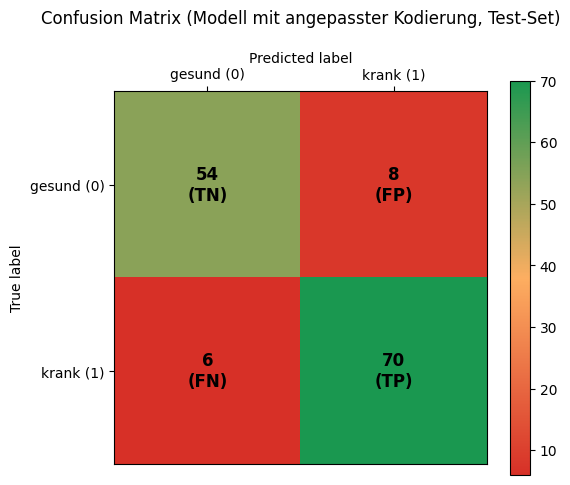

In [138]:
# Confusion Matrix und F2-Score für das neue Modell (Test-Set)
y_test_pred = rf_model.predict(X_test_processed)

f2_test = fbeta_score(y_test, y_test_pred, beta=2, pos_label=1)
print(f"F2-Score (Test, pos_label=1): {f2_test:.4f}")

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
labels = ["gesund (0)", "krank (1)"]

cmap_traffic = LinearSegmentedColormap.from_list(
    "traffic_light",
    ["#d73027", "#fdae61", "#1a9850"] 
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=cmap_traffic)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i == 0 and j == 0:
            label = "(TN)"
        elif i == 0 and j == 1:
            label = "(FP)"
        elif i == 1 and j == 0:
            label = "(FN)"
        elif i == 1 and j == 1:
            label = "(TP)"
        ax.text(j, i, f"{cm[i, j]}\n{label}", ha="center", va="center", color="black", fontsize=12, fontweight="bold")

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Modell mit angepasster Kodierung, Test-Set)", pad=20)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

F2-Score (Val, pos_label=1): 0.8594


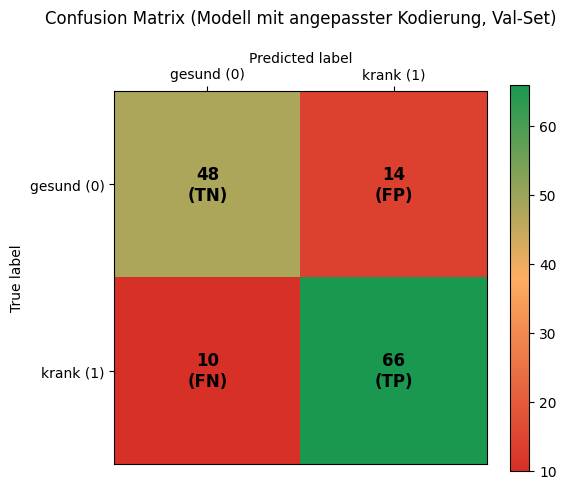

In [139]:
# Confusion Matrix und F2-Score für das neue Modell (Test-Set)
y_val_pred = rf_model.predict(X_val_processed)

f2_val = fbeta_score(y_val, y_val_pred, beta=2, pos_label=1)
print(f"F2-Score (Val, pos_label=1): {f2_val:.4f}")

cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
labels = ["gesund (0)", "krank (1)"]

cmap_traffic = LinearSegmentedColormap.from_list(
    "traffic_light",
    ["#d73027", "#fdae61", "#1a9850"] 
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=cmap_traffic)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i == 0 and j == 0:
            label = "(TN)"
        elif i == 0 and j == 1:
            label = "(FP)"
        elif i == 1 and j == 0:
            label = "(FN)"
        elif i == 1 and j == 1:
            label = "(TP)"
        ax.text(j, i, f"{cm[i, j]}\n{label}", ha="center", va="center", color="black", fontsize=12, fontweight="bold")

ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (Modell mit angepasster Kodierung, Val-Set)", pad=20)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

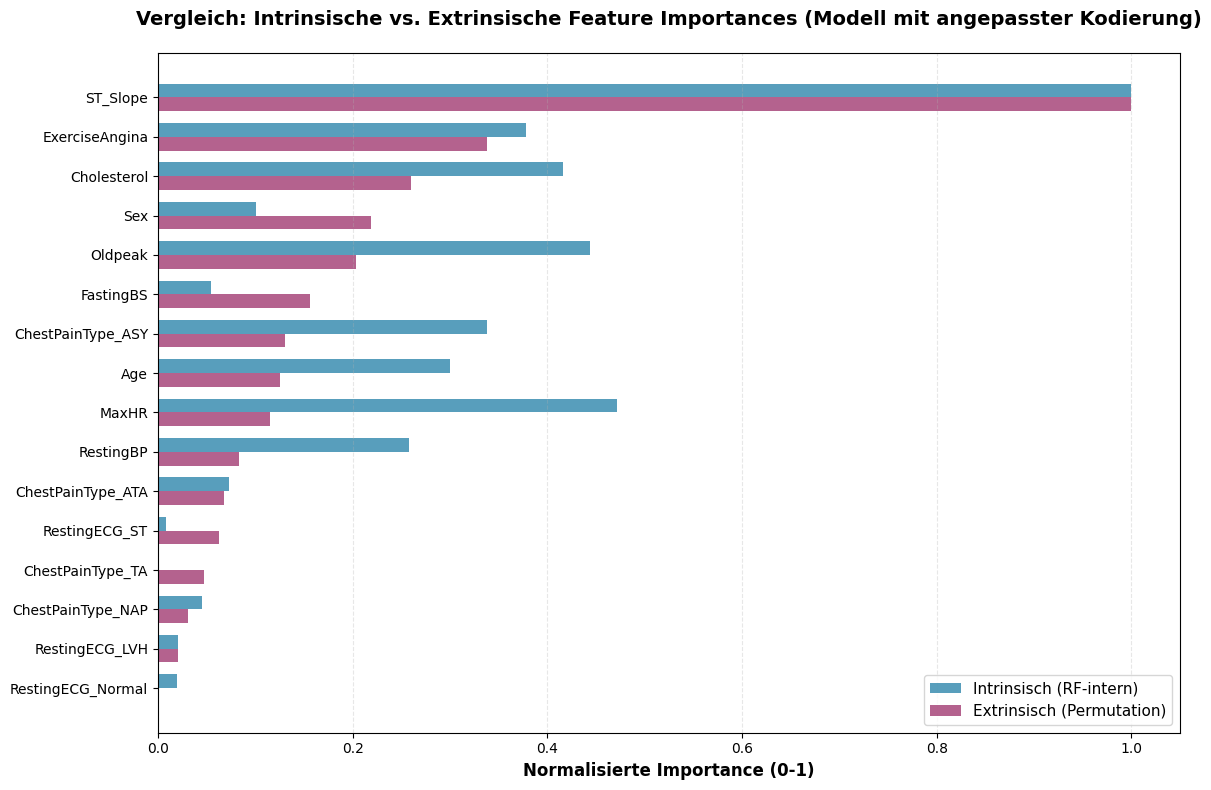

In [140]:
# --- Intrinsische Feature Importances ---
intrinsic_importances = rf_model.feature_importances_
intrinsic_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': intrinsic_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# --- Extrinsische Feature Importances (Permutation) ---
perm_result = permutation_importance(
    rf_model,
    X_test_processed,
    y_test,
    n_repeats=10,
    random_state=40,
    n_jobs=-1,
    scoring='accuracy'
)

extrinsic_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

# --- Vergleich Intrinsisch vs. Extrinsisch ---
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Intrinsisch': intrinsic_importances,
    'Extrinsisch': perm_result.importances_mean
})
comparison_df['Intrinsisch_Norm'] = (comparison_df['Intrinsisch'] - comparison_df['Intrinsisch'].min()) / (comparison_df['Intrinsisch'].max() - comparison_df['Intrinsisch'].min())
comparison_df['Extrinsisch_Norm'] = (comparison_df['Extrinsisch'] - comparison_df['Extrinsisch'].min()) / (comparison_df['Extrinsisch'].max() - comparison_df['Extrinsisch'].min())
comparison_df['Durchschnitt'] = (comparison_df['Intrinsisch_Norm'] + comparison_df['Extrinsisch_Norm']) / 2
comparison_df = comparison_df.sort_values('Extrinsisch', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
x_pos = np.arange(len(comparison_df))
width = 0.35
ax.barh(x_pos - width/2, comparison_df['Intrinsisch_Norm'], width, label='Intrinsisch (RF-intern)', color='#2E86AB', alpha=0.8)
ax.barh(x_pos + width/2, comparison_df['Extrinsisch_Norm'], width, label='Extrinsisch (Permutation)', color='#A23B72', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(comparison_df['Feature'])
ax.set_xlabel('Normalisierte Importance (0-1)', fontsize=12, fontweight='bold')
ax.set_title('Vergleich: Intrinsische vs. Extrinsische Feature Importances (Modell mit angepasster Kodierung)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=11)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


**Bewertung des angepassten Feature-Engineerings**  
Der **F2-Score** und die **Confusion Matrix** des mit der neuen Kodierung trainierten Modells sind **nahezu identisch** zum ersten Modell – durch das Feature-Engineering wurde hier **keine Verbesserung** der Vorhersagegüte erzielt. 

**Vorteil der Anpassung:** Dennoch konnte die **Anzahl der Features** reduziert werden (von 20 auf weniger Spalten durch binäre Kodierung von Sex und ExerciseAngina sowie ordinale Kodierung von ST_Slope). Daraus ergeben sich **Vorteile**: geringerer Speicherbedarf und schnellere Berechnungen, weniger Redundanz in den Merkmalen, und eine **einfachere Interpretation** der Modell- und SHAP-Ergebnisse.

**Weitere mögliche Vereinfachungen (extrinsische Importance):** Die neue **extrinsische Feature Importance** lässt vermuten, dass zusätzlich zu den bereits getroffenen Maßnahmen **RestingECG** nicht one-hot-kodiert werden müsste – **RestingECG_ST** und **RestingECG_LVH** könnten dementsprechend entfallen. 
Außerdem wird im nächsten Schritt getestet, wie es sich auf das Modell auswirkt, wenn **MaxHR** entfernt wird, da die extrinsische Importance dort gegen 0 geht und die lokalen Methoden dies als Faktor für Fehlklassifikation herausgestellt haben. Bei **ChestPainType** sollte geprüft werden, ob alle Spalten außer **ChestPainType_ASY** entfernt werden können, ohne die Modellperformance zu beeinträchtigen. Diese Vereinfachungen sollen im nächsten Schritt getestet werden.

In [141]:
# Vereinfachtes Preprocessing (Schritt 2): RestingECG ordinal, kein MaxHR, nur ChestPainType_ASY
def encode_inputs_v2(X_df):
    X_enc = X_df.copy()
    X_enc["Sex"] = (X_enc["Sex"].str.upper().eq("M")).astype(int)
    X_enc["ExerciseAngina"] = (X_enc["ExerciseAngina"].str.upper().eq("Y")).astype(int)
    X_enc["ST_Slope"] = X_enc["ST_Slope"].replace({"Down": 0, "Flat": 1, "Up": 2})
    X_enc["RestingECG"] = X_enc["RestingECG"].replace({"Normal": 0, "ST": 1, "LVH": 2})
    X_enc["ChestPainType_ASY"] = (X_enc["ChestPainType"] == "ASY").astype(int)
    X_enc = X_enc.drop(columns=["MaxHR", "ChestPainType"])
    return X_enc

features_v2 = ["ST_Slope", "Cholesterol", "ExerciseAngina", "Sex", "Oldpeak", "FastingBS", "ChestPainType_ASY", "Age", "RestingBP", "RestingECG"]

X_train_enc_v2 = encode_inputs_v2(X_train)
X_val_enc_v2   = encode_inputs_v2(X_val)
X_test_enc_v2  = encode_inputs_v2(X_test)

X_train_processed = X_train_enc_v2[features_v2].copy()
X_val_processed   = X_val_enc_v2[features_v2].copy()
X_test_processed = X_test_enc_v2[features_v2].copy()

feature_names = features_v2
print(f"Anzahl Features (vereinfacht): {len(feature_names)}")
print("Features:", feature_names)
display(X_train_processed.head(3))

Anzahl Features (vereinfacht): 10
Features: ['ST_Slope', 'Cholesterol', 'ExerciseAngina', 'Sex', 'Oldpeak', 'FastingBS', 'ChestPainType_ASY', 'Age', 'RestingBP', 'RestingECG']


/var/folders/s7/2wzgmxms5kx_cqgfw1f3zr9h0000gn/T/ipykernel_27973/632225154.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_enc["ST_Slope"] = X_enc["ST_Slope"].replace({"Down": 0, "Flat": 1, "Up": 2})
/var/folders/s7/2wzgmxms5kx_cqgfw1f3zr9h0000gn/T/ipykernel_27973/632225154.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_enc["RestingECG"] = X_enc["RestingECG"].replace({"Normal": 0, "ST": 1, "LVH": 2})
/var/folders/s7/2wzgmxms5kx_cqgfw1f3zr9h0000gn/T/ipykernel_27973/632225154.py:6: FutureWarning: Downcasting behavior in

,ST_Slope,Cholesterol,ExerciseAngina,Sex,Oldpeak,FastingBS,ChestPainType_ASY,Age,RestingBP,RestingECG
43,2,259,0,1,0.0,0,0,52,140,1
760,1,282,1,1,2.0,0,1,53,123,0
255,2,274,0,0,0.0,0,0,53,120,0


F2-Score (Test, pos_label=1): 0.9186


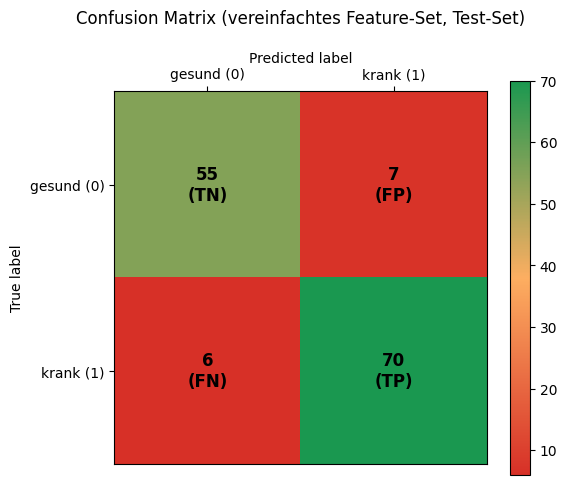

In [144]:
# Modell mit gleichen Parametern auf vereinfachten Features trainieren
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=40, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)

# F2-Score und Confusion Matrix
y_test_pred = rf_model.predict(X_test_processed)
f2_test = fbeta_score(y_test, y_test_pred, beta=2, pos_label=1)
print(f"F2-Score (Test, pos_label=1): {f2_test:.4f}")

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
labels = ["gesund (0)", "krank (1)"]
cmap_traffic = LinearSegmentedColormap.from_list("traffic_light", ["#d73027", "#fdae61", "#1a9850"])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=cmap_traffic)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i == 0 and j == 0: label = "(TN)"
        elif i == 0 and j == 1: label = "(FP)"
        elif i == 1 and j == 0: label = "(FN)"
        else: label = "(TP)"
        ax.text(j, i, f"{cm[i, j]}\n{label}", ha="center", va="center", color="black", fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (vereinfachtes Feature-Set, Test-Set)", pad=20)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


Das vorgenommene **Feature-Engineering** konnte das Modell minimal verbessern und **einen zuvor falsch gelabelten Fall** richtig zuordnen (1 **FP**). Dadurch stieg der **F2-Score** von **0,9162** auf **0,9186**.
RestingBP weist nun keinen extrinischen Wert mehr auf, führt allerdings bei Entfernung zu einem verschlechterten F2-Score und wird deswegen nicht entfernt.

F2-Score (Test, pos_label=1): 0.8724


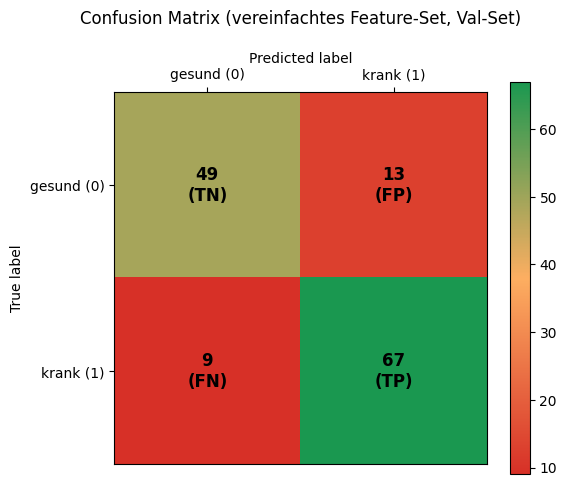

In [143]:
# F2-Score und Confusion Matrix
y_val_pred = rf_model.predict(X_val_processed)
f2_val = fbeta_score(y_val, y_val_pred, beta=2, pos_label=1)
print(f"F2-Score (Test, pos_label=1): {f2_val:.4f}")

cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
labels = ["gesund (0)", "krank (1)"]
cmap_traffic = LinearSegmentedColormap.from_list("traffic_light", ["#d73027", "#fdae61", "#1a9850"])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap=cmap_traffic)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i == 0 and j == 0: label = "(TN)"
        elif i == 0 and j == 1: label = "(FP)"
        elif i == 1 and j == 0: label = "(FN)"
        else: label = "(TP)"
        ax.text(j, i, f"{cm[i, j]}\n{label}", ha="center", va="center", color="black", fontsize=12, fontweight="bold")
ax.set_yticks(np.arange(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix (vereinfachtes Feature-Set, Val-Set)", pad=20)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

**Beobachtung:**
- Die **Performance auf dem Validierungsdatensatz** ist **unverändert** gegenüber dem vorherigen Schritt.
- Das Modell wurde erneut **entschlankt** (reduziertes Feature-Set, angepasstes Encoding), ohne Einbußen bei der Vorhersagequalität.

**Konsequenz:**  
Die XAI-gestützte Modellanpassung war erneut erfolgreich: Bei **konstanter Performance** konnte das Modell weiter vereinfacht werden. Die zuvor identifizierten Redundanzen und wenig informativen Merkmale konnten ohne Verlust an Validierungsperformance entfernt bzw. umkodiert werden.

## Phase 8 – Fazit

### Ausgangslage und Zielsetzung

Ziel dieses Projekts war es, mithilfe von **Explainable AI (XAI)** die Entscheidungen eines Machine-Learning-Modells zur Herzerkrankungs-Vorhersage nicht nur zu verstehen, sondern gezielt zu verbessern. Grundlage bildete ein Datensatz mit **918 Beobachtungen und 12 Merkmalen** (keine fehlenden Werte, binäre Zielvariable `HeartDisease`). Als Modell wurde ein **Random Forest Classifier** (100 Bäume) gewählt, trainiert auf einem stratifizierten 70/15/15-Split.

### Metrikwahl: F2-Score

Als zentrale Bewertungsmetrik wurde der **F2-Score** gewählt, da im medizinischen Kontext **False Negatives** (übersehene Erkrankungen) deutlich kritischer sind als False Positives (Fehlalarme). Der F2-Score gewichtet Recall doppelt so stark wie Precision und spiegelt damit die klinische Priorität wider, möglichst keine kranken Patienten fälschlicherweise als gesund einzustufen.

### Baseline-Modell

Das Baseline-Modell erreichte mit One-Hot-Encoding (20 Features) einen **F2-Score von ~0.9162** auf dem Validierungsdatensatz bei einer Accuracy von ~0.90. Die Konfusionsmatrix zeigte **6 False Negatives** – diese bildeten den Ausgangspunkt für die anschließende XAI-Analyse.

### Erkenntnisse aus dem globalen XAI

- **Intrinsische und extrinsische Feature Importances** identifizierten `ST_Slope`, `Cholesterol`, `ChestPainType_ASY`, `FastingBS`, `Sex` und `Oldpeak` als die wichtigsten Merkmale (Korrelation zwischen beiden Methoden: ~0.44 – komplementäre Perspektiven).
- **SHAP-Analysen** (Beeswarm, Mean |SHAP|, Dependence Plots) bestätigten und vertieften diese Erkenntnisse:
  - `Cholesterol = 0` (wahrscheinlich ein Platzhalter für fehlende Werte) trug positiv zur Vorhersage „krank" bei – ein potenzielles Datenproblem.
  - One-Hot-Encoding erzeugte bei binären Features (z. B. `Sex`, `ExerciseAngina`) **redundante Spiegelfeatures**, die das Modell unnötig komplex machten.

### Erkenntnisse aus dem lokalen XAI

- **kNN-Matching** zeigte, dass die 6 False Negatives **keine Grenzfälle** waren: Ihre mittlere Krankheitswahrscheinlichkeit lag bei nur ~0.21, verglichen mit ~0.83 bei den zugehörigen True Positives. Das Modell hat diese Fälle also systematisch anders bewertet.
- **SHAP Waterfall Plots** und die **aggregierte Meta-Tabelle** (`mean_abs_delta`, `sign_consistency`) identifizierten die zentralen **Kippfaktoren** in folgender Prioritätenreihenfolge:
  1. `ST_Slope_Flat = 0` – fehlende Flat-Kurve drückte die Vorhersage in Richtung „gesund"
  2. `ST_Slope_Up = 1` – aufsteigende ST-Kurve wirkte stark gegen die Diagnose „krank"
  3. `ChestPainType_ASY = 0` – fehlender asymptomatischer Brustschmerz reduzierte die Krankheitswahrscheinlichkeit
  4. `MaxHR` – hohe maximale Herzfrequenz wurde als Gesundheitsindikator interpretiert
  5. `ExerciseAngina` – belastungsinduzierte Angina beeinflusste die Klassifikation
- **LIME** bestätigte exemplarisch und unabhängig die SHAP-basierten Fehlklassifikationsmechanismen als Plausibilitätsprüfung, ohne grundlegend neue Erkenntnisse zu liefern.

### Modellverbesserung durch XAI-gestützte Feature-Anpassung

Auf Basis der XAI-Erkenntnisse wurde das Feature-Engineering in zwei Schritten angepasst:

1. **Redundanzabbau**: Binäre Features (`Sex`, `ExerciseAngina`) direkt binär kodiert, `ST_Slope` ordinal kodiert → Reduktion von 20 auf 16 Features, Performance stabil.
2. **Weitere Vereinfachung**: `RestingECG` ebenfalls ordinal kodiert, `MaxHR` entfernt (geringe Relevanz laut XAI), nur `ChestPainType_ASY` als One-Hot behalten → **Reduktion auf 10 Features**.

**Ergebnis**: Der F2-Score verbesserte sich leicht von **0.9162 auf 0.9186** (ein False Positive wurde korrekt als True Negative reklassifiziert), bei **gleichzeitig halbierter Feature-Anzahl**. `RestingBP` wurde trotz niedriger extrinsischer Importance beibehalten, da sein Entfernen die Performance verschlechterte – ein Beispiel dafür, dass XAI-Erkenntnisse stets empirisch validiert werden müssen.

### Gesamtbewertung

Der XAI-Prozess hat gezeigt, dass Erklärbarkeit nicht im Widerspruch zur Modellperformance steht, sondern diese sogar fördern kann. Die systematische Kombination aus **globaler Analyse** (Feature Importances, SHAP), **lokaler Analyse** (SHAP Waterfall, kNN-Matching, LIME) und **aggregierter Fehleranalyse** (Meta-Tabelle) ermöglichte es, die Ursachen für Fehlklassifikationen präzise zu identifizieren und gezielt gegenzusteuern. Das resultierende Modell ist **einfacher, besser interpretierbar und minimal performanter** als das Baseline-Modell – ein Ergebnis, das ohne den XAI-gestützten Ansatz nicht erreichbar gewesen wäre.